# Chronos-2: dual lagged setups + 2025 backtest + merged XGBoost lists

Replicates the workflow from **`chronos2_logC5_direct_forecast_2026Mar31.ipynb`** for **three** forward-forecast covariate sources, plus a **2025 backtest** and a **merged-feature-list** run:

| Part | Covariates |
|------|------------|
| **1** | `Transformed_Deseason_Residuals_Lagged.xlsx` only |
| **2** | `Master_Data_AVG_version_update_Lagged.xlsx` only (drops `C5_lag_39`, `C5_ma_63`, `*_pred`) |
| **3** | **Both** workbooks merged on `Date` (prefixed column names: `ds_*` vs `mav_*` to avoid collisions) |
| **4** | **2025 backtest:** for each shared feature-set tag (e.g. `kbest_60`), Chronos on Master lagged vs Deseason lagged with **matching** XGBoost columns; **MAE** on C5 vs actuals drives **inverse-MAE** weights for a combined forecast |
| **5** | **Merged lists:** `XGBoost_MasterPlusDeseason_Lagged_C5_feature_sets_results.xlsx` → same **Graph A / B** style as Parts 1–2 on the combined `ds_*`+`mav_*` panel |

Parts **1–3** each produce:

1. **Graph A:** 3 lines — Chronos with **all** features, Chronos with **top 80** by |corr| with the target (`C5` or `log(C5)`), and **actual** C5.
2. **Graph B:** up to **6** Chronos lines (one per top **Test_R2** column) + **actual**. **Part 1** uses `XGBoost_model_features_by_selection.xlsx` (Deseason feature names). **Part 2** uses **`XGBoost_Master_Lagged_C5_feature_sets_results.xlsx`** sheet **`model_features_by_selection`** when that file exists (same names as Master lagged columns); otherwise it falls back to the Deseason file and lines may be skipped. **Part 3** merges both lists by **Test_R2** (top N overall) so `ds_*` and `mav_*` covariates can both appear.

Shared settings: forward horizon uses training context **[TRAIN_START, FORECAST_START)** and business days **[FORECAST_START, FORECAST_END]**; Part 4 uses **`BACKTEST_2025_START`–`BACKTEST_2025_END`** with training **[TRAIN_START, BACKTEST_2025_START)**. **Part 4** also scores predictions vs actuals on **`EVAL_2026_START`–`EVAL_2026_END`** (clipped to **`FORECAST_END`**). Actuals from **`C5 Through End Q126.xlsx`**. Tune **`CHRONOS_TARGET_LOG_SCALE`**, **`SECTION1_CORR_TOP_K`**, **`SECTION2_SELECTION_N`** in the config cell.


In [1]:
# Install dependencies (Jupyter / VS Code / Colab)
import subprocess
import sys
_pkgs = ["chronos-forecasting>=2.2.0", "openpyxl", "matplotlib", "scikit-learn"]
if "google.colab" not in sys.modules:
    _pkgs.extend(["torch", "pandas<3"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", *_pkgs])
print("Dependencies OK | Colab:", "google.colab" in sys.modules)


Dependencies OK | Colab: True


In [2]:
import sys
MOUNT_GOOGLE_DRIVE = True
if "google.colab" in sys.modules and MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
elif "google.colab" not in sys.modules:
    print("Local run — skip Drive mount.")


Mounted at /content/drive


## Code layout
- **Definitions cell:** paths, helpers, `run_part`, Chronos runner — run **once**.
- **Main cell:** load Master, actuals, selection xlsx; run **Parts 1–3** (each runs several Chronos jobs).
- **Part 4–5 cell:** 2025 paired backtest + inverse-MAE ensemble (**Part 4**), then **2026 forward vs actual C5** where actuals exist; Chronos Graph A/B from **`XGBoost_MasterPlusDeseason_Lagged_C5_feature_sets_results.xlsx`** (**Part 5**). Requires the main cell to have run so lagged panels and maps exist.


In [3]:
from pathlib import Path
import os
import re
import shutil
import subprocess
import sys
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules
COLAB_DATA_DIR = Path("/content/drive/MyDrive/Project 005 Data")

if IN_COLAB:
    try:
        from google.colab import userdata
        _hf = userdata.get("HF_TOKEN")
        if _hf:
            os.environ["HF_TOKEN"] = _hf
    except Exception:
        pass

BASE_DIR = COLAB_DATA_DIR if IN_COLAB else Path.cwd()
if not (BASE_DIR / "Master_Data_AVG_version_update.xlsx").exists():
    BASE_DIR = Path.home() / "Downloads" / "Project 005 Data"

TRAIN_START = pd.Timestamp("2015-01-01")
FORECAST_START = pd.Timestamp("2025-12-23")
FORECAST_END = pd.Timestamp("2026-03-31")

# Part 4: walk-forward backtest on calendar year 2025 (business days in range)
BACKTEST_2025_START = pd.Timestamp("2025-01-01")
BACKTEST_2025_END = pd.Timestamp("2025-12-31")

# Part 4: score forward predictions vs true C5 on 2026 dates (intersect with FORECAST_END + actuals file)
EVAL_2026_START = pd.Timestamp("2026-01-01")
EVAL_2026_END = pd.Timestamp("2026-12-31")

# Part 5: wide feature lists from merged Master+Deseason XGBoost export
FEATURE_SELECTION_MERGED_XLSX = (
    BASE_DIR / "XGBoost_MasterPlusDeseason_Lagged_C5_feature_sets_results.xlsx"
)
FEATURE_SELECTION_MERGED_WIDE_SHEET = "model_features_by_selection"

MASTER_FILE = BASE_DIR / "Master_Data_AVG_version_update.xlsx"
MASTER_DATE_COL = "Date"
MASTER_C5_COL = "C5"

DESEASON_LAGGED_XLSX = BASE_DIR / "Transformed_Deseason_Residuals_Lagged.xlsx"
MASTER_LAGGED_XLSX = BASE_DIR / "Master_Data_AVG_version_update_Lagged.xlsx"

ACTUAL_FILE = BASE_DIR / "C5 Through End Q126.xlsx"
ACTUAL_SHEET = "SIN Timeseries - D"
ACTUAL_HEADER = 5
ACTUAL_DATE_COL = "Date"
ACTUAL_C5_COL = "$/Tonne"

FEATURE_SELECTION_XLSX = BASE_DIR / "XGBoost_model_features_by_selection.xlsx"

CHRONOS_FILE_TAG = (
    f"__from_{DESEASON_LAGGED_XLSX.stem}"
    f"__mav_{MASTER_LAGGED_XLSX.stem}"
    f"__master_{MASTER_FILE.stem}"
)
MODEL_GENERATED_PATTERNS = ("XGBoost_pred", "_pred")
EXCLUDE_MASTER_LAG_EXACT = {"C5_lag_39", "C5_ma_63"}

SECTION1_CORR_TOP_K = 20
SECTION2_SELECTION_N = 10
CHRONOS_TARGET_LOG_SCALE = False

SAFE_MODE = True
MODEL_CANDIDATES = ["amazon/chronos-2", "autogluon/chronos-2-small"]
_chronos_tmp = Path("/tmp") if IN_COLAB else BASE_DIR

# NeuralProphet trend — try regressor-enhanced CSV first, fall back to univariate
# Applies slope dampening to prevent NP overshooting (SLOPE_ALPHA=1.0 = no dampening)
SLOPE_ALPHA    = 1   # 0.4-0.8; lower = flatter forecast; tune to match actual magnitude
NP_TREND_FILES = [
    BASE_DIR / "neuralprophet_c5_vs_Q126.csv",                 # univariate (preferred)
    BASE_DIR / "neuralprophet_reg_c5_q1_2026_forecast.csv",    # with regressors (fallback)
    BASE_DIR / "neuralprophet_c5_forecast.csv",                # alternate name fallback
]
_np_trend_df = None
_np_t0 = None
NP_COLS = []
for _np_file in NP_TREND_FILES:
    if _np_file.is_file():
        _raw_np = pd.read_csv(_np_file, parse_dates=["ds"] if "ds" in
                              pd.read_csv(_np_file, nrows=0).columns else ["Date"])
        if "ds" in _raw_np.columns:
            _raw_np = _raw_np.rename(columns={"ds": "Date", "yhat": "C5_np_trend"})
        elif "Date" in _raw_np.columns and "C5_np_trend" not in _raw_np.columns:
            _yhat_col = next((c for c in _raw_np.columns if "yhat" in c.lower()), None)
            if _yhat_col:
                _raw_np = _raw_np.rename(columns={_yhat_col: "C5_np_trend"})
        if "C5_np_trend" not in _raw_np.columns:
            continue
        _np_trend_df = _raw_np[["Date", "C5_np_trend"]].copy()
        _np_trend_df["Date"] = pd.to_datetime(_np_trend_df["Date"]).dt.normalize()
        _np_trend_df = _np_trend_df.dropna(subset=["C5_np_trend"])
        _np_future = _np_trend_df[_np_trend_df["Date"] >= FORECAST_START]
        if _np_future.empty:
            _np_trend_df = None
            continue
        _np_t0_raw = float(_np_future["C5_np_trend"].iloc[0])
        _np_trend_df["C5_np_trend"] = (
            SLOPE_ALPHA * _np_trend_df["C5_np_trend"]
            + (1 - SLOPE_ALPHA) * _np_t0_raw
        )
        _np_t0 = float(
            _np_trend_df.loc[_np_trend_df["Date"] >= FORECAST_START, "C5_np_trend"].iloc[0]
        )
        _np_trend_df["C5_np_delta"]    = _np_trend_df["C5_np_trend"] - _np_t0
        _np_trend_df["C5_np_momentum"] = _np_trend_df["C5_np_trend"].diff().fillna(0)
        NP_COLS = ["C5_np_trend", "C5_np_delta", "C5_np_momentum"]
        print(f"NeuralProphet trend loaded: {_np_file.name}")
        print(f"  Rows: {len(_np_trend_df)} | SLOPE_ALPHA={SLOPE_ALPHA}")
        print(f"  NP_t0 (dampened): {_np_t0:.4f} | undampened: {_np_t0_raw:.4f}")
        break
if _np_trend_df is None:
    print("WARNING: No NeuralProphet trend file found - NP drift anchor disabled.")
    print(f"  Searched: {[f.name for f in NP_TREND_FILES]}")

print("BASE_DIR:", BASE_DIR)


def require_columns(df: pd.DataFrame, required_cols: list, dataset_name: str) -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"{dataset_name} missing required columns: {missing}")


def chronos_dataset_stem(model_id: str, feature_tag: str, n_cov: int) -> str:
    mid = re.sub(r"[^\w.\-]+", "_", str(model_id)).strip("_")
    ft = re.sub(r"[^\w.\-|]+", "_", str(feature_tag)).strip("_")
    if len(ft) > 100:
        ft = ft[:100].rstrip("_")
    return f"{mid}|{ft}|n={int(n_cov)}"


def read_excel_colab_safe(path, **kwargs):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)
    resolved = path.expanduser().resolve()
    sp = str(resolved)
    if IN_COLAB and sp.startswith("/content/drive/"):
        local = Path("/tmp") / f"_colab_safe_{resolved.name}"
        shutil.copyfile(resolved, local)
        try:
            return pd.read_excel(local, **kwargs)
        finally:
            try:
                local.unlink(missing_ok=True)
            except OSError:
                pass
    return pd.read_excel(resolved, **kwargs)


def forecast_export_colname(feature_tag: str, n_cov: int) -> str:
    return f"{str(feature_tag).strip()}|n={int(n_cov)}"


def forecast_export_log_colname(feature_tag: str, n_cov: int) -> str:
    return f"log_C5|{str(feature_tag).strip()}|n={int(n_cov)}"


def selection_column_tag(header: str) -> str:
    h = str(header).split("Test_R2")[0].strip().rstrip(",").strip()
    # Wide XGBoost headers often look like "ar_plus_kbest_60 | n=67 | ...".
    # Use only the leading method stem so tags stay stable (avoid embedding n=... twice).
    if "|" in h:
        h = h.split("|", 1)[0].strip()
    h = re.sub(r"\s+", "_", h)
    h = re.sub(r"[^\w.\-]+", "_", h).strip("_")
    return h[:80] if h else "selection"



def selection_column_tag_legacy(header: str) -> str:
    """Tag style used before splitting on the first '|' (matches older Graph B CSV keys)."""
    h = str(header).split("Test_R2")[0].strip().rstrip(",").strip()
    h = re.sub(r"\s+", "_", h)
    h = re.sub(r"[^\w.\-]+", "_", h).strip("_")
    return h[:80] if h else "selection"


def selection_sheet_declared_n(header) -> int | None:
    """If the wide selection column header contains '| n=NN' before Test_R2, return NN."""
    hs = str(header).split("Test_R2", 1)[0]
    m = re.search(r"\|\s*n\s*=\s*(\d+)", hs, flags=re.I)
    return int(m.group(1)) if m else None


def selection_method_declared_n(header) -> int | None:
    """K from method stem (e.g. ar_plus_kbest_60 -> 60) even when header lists n=67 for AR+k."""
    hs = str(header).split("Test_R2", 1)[0].strip().rstrip(",").strip()
    if "|" in hs:
        hs = hs.split("|", 1)[0].strip()
    hs_compact = re.sub(r"\s+", "", hs)
    m = re.search(r"kbest[_]?(\d+)$", hs_compact, flags=re.I)
    return int(m.group(1)) if m else None


def selection_method_declared_n_from_tag(feature_tag: str) -> int | None:
    """Same K inference as selection_method_declared_n, but from the sanitized tag string."""
    t = re.sub(r"\s+", "", str(feature_tag))
    m = re.search(r"kbest[_]?(\d+)$", t, flags=re.I)
    return int(m.group(1)) if m else None


FEATURE_SELECTION_MASTER_RESULTS_XLSX = (
    BASE_DIR / "XGBoost_Master_Lagged_C5_feature_sets_results.xlsx"
)
FEATURE_SELECTION_MASTER_WIDE_SHEET = "model_features_by_selection"


def parse_selection_columns_ranked(selection_path: Path, max_cols: int):
    sel = read_excel_colab_safe(selection_path)
    ranked = []
    for c in sel.columns:
        if str(c).strip().lower() == "feature_index":
            continue
        cs = str(c)
        m = re.search(r"Test_R2=([0-9.eE+-]+|NA|nan)", cs, flags=re.I)
        if not m:
            continue
        r2_s = m.group(1)
        try:
            r2 = float(r2_s) if str(r2_s).upper() not in ("NA", "NAN") else float("nan")
        except ValueError:
            r2 = float("nan")
        names = sel[c].dropna().astype(str).str.strip()
        names = [n for n in names if n and n.lower() != "nan"]
        ranked.append((c, r2, names))
    ranked.sort(key=lambda x: (-x[1] if np.isfinite(x[1]) else -1e9))
    return ranked[: max_cols]


def parse_selection_wide_sheet_ranked(path: Path, sheet_name: str, max_cols: int):
    """Wide layout: feature_index + columns '{method} | n=… | Test_R2=…' (Master lagged results export)."""
    if not path.is_file():
        return []
    try:
        sel = read_excel_colab_safe(path, sheet_name=sheet_name)
    except ValueError:
        return []
    ranked = []
    for c in sel.columns:
        if str(c).strip().lower() == "feature_index":
            continue
        cs = str(c)
        m = re.search(r"Test_R2=([0-9.eE+-]+|NA|nan)", cs, flags=re.I)
        if not m:
            continue
        r2_s = m.group(1)
        try:
            r2 = float(r2_s) if str(r2_s).upper() not in ("NA", "NAN") else float("nan")
        except ValueError:
            r2 = float("nan")
        names = sel[c].dropna().astype(str).str.strip()
        names = [n for n in names if n and n.lower() != "nan"]
        ranked.append((c, r2, names))
    ranked.sort(key=lambda x: (-x[1] if np.isfinite(x[1]) else -1e9))
    return ranked[: max_cols]


def parse_feature_sets_by_tag(
    path: Path,
    sheet_name=None,
):
    """Wide sheet → dict[tag] = {header, r2, features}; tag = text before first ' | ' in column name."""
    if not path.is_file():
        return {}
    try:
        sel = (
            read_excel_colab_safe(path, sheet_name=sheet_name)
            if sheet_name is not None
            else read_excel_colab_safe(path)
        )
    except (ValueError, KeyError):
        sel = read_excel_colab_safe(path)
    best = {}
    for c in sel.columns:
        cs = str(c)
        if cs.strip().lower() == "feature_index":
            continue
        m = re.search(r"Test_R2=([0-9.eE+-]+|NA|nan)", cs, flags=re.I)
        if not m:
            continue
        r2_s = m.group(1)
        try:
            r2 = float(r2_s) if str(r2_s).upper() not in ("NA", "NAN") else float("nan")
        except ValueError:
            r2 = float("nan")
        names = sel[c].dropna().astype(str).str.strip()
        names = [n for n in names if n and n.lower() != "nan"]
        tag = cs.split(" | ", 1)[0].strip()
        if not tag:
            tag = selection_column_tag(cs)
        prev = best.get(tag)
        if prev is None or (np.isfinite(r2) and (not np.isfinite(prev["r2"]) or r2 > prev["r2"])):
            best[tag] = {"header": c, "r2": r2, "features": names}
    return best


def merge_selection_ranked_by_r2(parts: list, max_cols: int):
    merged = []
    for lst in parts:
        merged.extend(lst)
    merged.sort(key=lambda x: (-x[1] if np.isfinite(x[1]) else -1e9))
    return merged[: int(max_cols)]


def process_lagged_workbook(
    path: Path,
    col_prefix: str,
    exclude_exact=None,
):
    # Load lagged xlsx: numeric covariates, unique safe names with col_prefix; returns lag_f, cov_cols, orig_to_safe.
    if not path.is_file():
        raise FileNotFoundError(path)
    raw = read_excel_colab_safe(path)
    dcol = "Date" if "Date" in raw.columns else raw.columns[0]
    raw[dcol] = pd.to_datetime(raw[dcol], errors="coerce")
    raw = raw.dropna(subset=[dcol]).sort_values(dcol)
    lag = raw.set_index(dcol).sort_index()
    lag.index = pd.to_datetime(lag.index, errors="coerce").normalize()

    drop_pred = [c for c in lag.columns if any(p in str(c) for p in MODEL_GENERATED_PATTERNS)]
    if drop_pred:
        lag = lag.drop(columns=drop_pred, errors="ignore")
    if exclude_exact:
        ex = [c for c in lag.columns if str(c) in exclude_exact]
        if ex:
            lag = lag.drop(columns=ex, errors="ignore")

    num = lag.select_dtypes(include=[np.number]).copy()
    use_cols = list(num.columns)
    _seen = set()
    cov_rename = {}
    for j, src in enumerate(use_cols):
        base_nm = col_prefix + (re.sub(r"[^\w]+", "_", str(src)).strip("_")[:100] or "feat")
        name = base_nm
        k = 0
        while name in _seen:
            k += 1
            name = f"{base_nm}_{j}_{k}"
        _seen.add(name)
        cov_rename[str(src)] = name

    lag_f = num[use_cols].apply(pd.to_numeric, errors="coerce").rename(columns=lambda c: cov_rename[str(c)])
    cov_cols = [cov_rename[str(c)] for c in use_cols]
    return lag_f, cov_cols, cov_rename


def align_lagged_covariates(
    lag_f: pd.DataFrame,
    cov_cols: list,
    forecast_start=None,
    forecast_end=None,
):
    fs = FORECAST_START if forecast_start is None else pd.Timestamp(forecast_start)
    fe = FORECAST_END if forecast_end is None else pd.Timestamp(forecast_end)
    bdays = pd.bdate_range(start=fs, end=fe, freq="B")
    _all_idx = lag_f.index.union(bdays).sort_values()
    lag_aligned = lag_f.reindex(_all_idx).sort_index().ffill()
    prediction_length = len(bdays)
    return lag_aligned, bdays, prediction_length


def build_master_panel(
    master_raw: pd.DataFrame,
    lag_aligned: pd.DataFrame,
    cov_cols: list,
    train_start=None,
    forecast_start=None,
    forecast_end=None,
):
    # Merge C5 with aligned covariates; returns train_ctx, cov_future, master, filtered cov_cols.
    ts = TRAIN_START if train_start is None else pd.Timestamp(train_start)
    fs = FORECAST_START if forecast_start is None else pd.Timestamp(forecast_start)
    fe = FORECAST_END if forecast_end is None else pd.Timestamp(forecast_end)

    base_x = master_raw[[MASTER_DATE_COL, MASTER_C5_COL]].copy()
    base_x.columns = ["Date", "C5"]
    base_x["Date"] = pd.to_datetime(base_x["Date"], errors="coerce")
    base_x["C5"] = pd.to_numeric(base_x["C5"], errors="coerce")
    base_x = base_x.dropna(subset=["Date", "C5"]).sort_values("Date").drop_duplicates(subset=["Date"], keep="last")
    base_x = base_x[base_x["C5"] > 0].reset_index(drop=True)
    base_x["log_C5"] = np.log(base_x["C5"])
    base_x["Date"] = base_x["Date"].dt.normalize()

    master = base_x.merge(lag_aligned[cov_cols].reset_index(names="Date"), on="Date", how="left")
    _ctx_end = fs - pd.Timedelta(days=1)
    _pre = master[(master["Date"] >= ts) & (master["Date"] <= _ctx_end)]
    _keep = [c for c in cov_cols if bool(_pre[c].notna().to_numpy().any())]
    cov_cols = list(dict.fromkeys(_keep))
    master = master[["Date", "C5", "log_C5"] + cov_cols].copy()
    if master.columns.duplicated().any():
        master = master.loc[:, ~master.columns.duplicated()].copy()
        cov_cols = [c for c in cov_cols if c in master.columns]
    master = master.sort_values("Date").reset_index(drop=True)
    master[cov_cols] = master[cov_cols].ffill().bfill()
    master["Date"] = pd.to_datetime(master["Date"], errors="coerce").dt.normalize()
    master = master.dropna(subset=["Date"]).drop_duplicates(subset=["Date"], keep="last")
    master = master.sort_values("Date").reset_index(drop=True)
    master = master.loc[master["Date"].dt.dayofweek < 5].reset_index(drop=True)

    train_ctx = master[(master["Date"] >= ts) & (master["Date"] < fs)].copy()
    if train_ctx.empty:
        raise ValueError("Empty training context; check dates / data.")

    future_dates = pd.bdate_range(start=fs, end=fe, freq="B")
    midx = lag_aligned[cov_cols].copy()
    midx.index = pd.to_datetime(midx.index, errors="coerce").normalize()
    if not midx.index.is_unique:
        midx = midx[~midx.index.duplicated(keep="last")]
    full_idx = midx.index.union(future_dates).sort_values()
    cov_future = midx.reindex(full_idx).ffill().loc[future_dates].reset_index(names="Date")

    return train_ctx, cov_future, master, cov_cols


def combine_two_lagged(
    path_ds: Path,
    path_mav: Path,
):
    # Horizontally stack deseason + master-avg lagged (prefixed column names).
    lag_d, cols_d, map_d = process_lagged_workbook(path_ds, col_prefix="ds_", exclude_exact=None)
    lag_m, cols_m, map_m = process_lagged_workbook(
        path_mav, col_prefix="mav_", exclude_exact=EXCLUDE_MASTER_LAG_EXACT
    )
    bdays = pd.bdate_range(start=FORECAST_START, end=FORECAST_END, freq="B")
    _all_idx = lag_d.index.union(lag_m.index).union(bdays).sort_values()
    a = lag_d.reindex(_all_idx).sort_index().ffill()
    b = lag_m.reindex(_all_idx).sort_index().ffill()
    combined = pd.concat([a, b], axis=1)
    cov_cols = list(combined.columns)
    orig_map = {**map_d, **map_m}
    return combined, cov_cols, orig_map


CHRONOS_RUNNER = textwrap.dedent(
    '''
    import os
    import sys
    import numpy as np
    import pandas as pd
    import torch
    from chronos import BaseChronosPipeline

    ctx_csv = sys.argv[1]
    fut_csv = sys.argv[2]
    out_csv = sys.argv[3]
    pred_len = int(sys.argv[4])
    model_candidates = [m for m in sys.argv[5].split("||") if m.strip()]

    use_gpu = torch.cuda.is_available()
    device_map = "cuda" if use_gpu else "cpu"
    if not use_gpu:
        os.environ["CUDA_VISIBLE_DEVICES"] = ""

    context_df = pd.read_csv(ctx_csv, parse_dates=["timestamp"])
    future_df = pd.read_csv(fut_csv, parse_dates=["timestamp"])
    if len(future_df) != pred_len:
        raise ValueError(f"future_df rows {len(future_df)} != pred_len {pred_len}")

    pipeline = None
    used_model = None
    last_error = None

    for model_id in model_candidates:
        try:
            pipeline = BaseChronosPipeline.from_pretrained(model_id, device_map=device_map)
            used_model = model_id
            break
        except Exception as e:
            last_error = e

    if pipeline is None:
        raise RuntimeError(f"Chronos-2 load failed. Last error: {last_error}")

    _fast = bool(int(os.environ.get("CHRONOS_FAST", "0")))
    # Reindex to gap-free business-day range so infer_freq resolves to "B"
    def _ensure_bday_freq(df, fill_cols):
        df = df.copy()
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        _ids = df["item_id"].unique()
        parts = []
        for _id in _ids:
            _sub = df[df["item_id"] == _id].set_index("timestamp").sort_index()
            _full = pd.bdate_range(start=_sub.index.min(), end=_sub.index.max(), freq="B")
            _sub = _sub.reindex(_full)
            _sub["item_id"] = _id
            for _c in fill_cols:
                if _c in _sub.columns:
                    _sub[_c] = _sub[_c].ffill().bfill()
            _sub = _sub.reset_index().rename(columns={"index": "timestamp"})
            parts.append(_sub)
        return pd.concat(parts, ignore_index=True)

    _cov_cols = [c for c in context_df.columns if c not in ("timestamp", "item_id", "target")]
    context_df  = _ensure_bday_freq(context_df,  ["target"] + _cov_cols)
    _fut_cov_cols = [c for c in future_df.columns if c not in ("timestamp", "item_id")]
    future_df   = _ensure_bday_freq(future_df,   _fut_cov_cols)

    pred = pipeline.predict_df(
        context_df,
        future_df=future_df,
        prediction_length=pred_len,
        quantile_levels=[0.5] if _fast else [0.1, 0.5, 0.9],
        id_column="item_id",
        timestamp_column="timestamp",
        target="target",
    )
    if "target_name" in pred.columns:
        pred = pred.loc[pred["target_name"].astype(str) == "target"].copy()
    ts_col = "timestamp" if "timestamp" in pred.columns else None
    if ts_col is None:
        for c in pred.columns:
            if "time" in str(c).lower():
                ts_col = c
                break
    if ts_col is None:
        raise KeyError(f"No timestamp column in forecast. Columns: {list(pred.columns)}")
    pred = pred.sort_values(ts_col).reset_index(drop=True)

    qcol = None
    for c in ("0.5", 0.5, "predictions"):
        if c in pred.columns:
            qcol = c
            break
    if qcol is None:
        raise KeyError(f"No median column in forecast output. Columns: {list(pred.columns)}")

    out_df = pd.DataFrame(
        {
            "timestamp": pd.to_datetime(pred[ts_col], utc=False),
            "median_forecast": pred[qcol].astype(float).values,
            "used_model": used_model,
        }
    )
    out_df.to_csv(out_csv, index=False)
    print(f"OK model={used_model} rows={len(out_df)} target_scale={sys.argv[6]}")
    '''
).strip()


def chronos_forecast_mv(
    train_ctx: pd.DataFrame,
    cov_future: pd.DataFrame,
    cov_use: list,
    stem: str,
    prediction_length: int,
    future_dates: pd.DatetimeIndex,
    np_trend_future=None,
    np_t0: float | None = None,
) -> pd.DataFrame:
    ctx_csv = _chronos_tmp / f"_ch3_ctx_{stem}.csv"
    fut_csv = _chronos_tmp / f"_ch3_fut_{stem}.csv"
    out_csv = _chronos_tmp / f"_ch3_out_{stem}.csv"
    ctx = train_ctx.copy()
    ctx["item_id"] = "c5"
    ctx["timestamp"] = ctx["Date"]
    _tcol = "log_C5" if CHRONOS_TARGET_LOG_SCALE else "C5"
    ctx["target"] = ctx[_tcol].astype(float)
    fut = cov_future.copy()
    fut["item_id"] = "c5"
    fut["timestamp"] = fut["Date"]
    for _cc in cov_use:
        ctx[_cc] = pd.to_numeric(ctx[_cc], errors="coerce").astype(np.float64)
        fut[_cc] = pd.to_numeric(fut[_cc], errors="coerce").astype(np.float64)
    ctx[["item_id", "timestamp", "target"] + cov_use].to_csv(ctx_csv, index=False)
    fut[["item_id", "timestamp"] + cov_use].to_csv(fut_csv, index=False)
    if out_csv.exists():
        out_csv.unlink()
    proc = subprocess.run(
        [
            sys.executable,
            "-c",
            CHRONOS_RUNNER,
            str(ctx_csv),
            str(fut_csv),
            str(out_csv),
            str(prediction_length),
            "||".join(MODEL_CANDIDATES),
            "log" if CHRONOS_TARGET_LOG_SCALE else "c5",
        ],
        capture_output=True,
        text=True,
        env={**os.environ, "CHRONOS_FAST": "1" if SAFE_MODE else "0"},
    )
    if proc.returncode != 0:
        raise RuntimeError(
            f"Chronos failed ({stem}).\nSTDOUT:\n{proc.stdout[-6000:]}\n\nSTDERR:\n{proc.stderr[-6000:]}"
        )
    pred_df = pd.read_csv(out_csv, parse_dates=["timestamp"])
    _fcst = pd.DataFrame({"Date": pd.to_datetime(future_dates).normalize()})
    _pred = pred_df.copy()
    _ts = pd.to_datetime(_pred["timestamp"], errors="coerce")
    if getattr(_ts.dt, "tz", None) is not None:
        _ts = _ts.dt.tz_convert("UTC").dt.tz_localize(None)
    _pred["Date"] = _ts.dt.normalize()
    out = _fcst.merge(_pred[["Date", "median_forecast"]], on="Date", how="left")
    if out["median_forecast"].isna().any():
        out["median_forecast"] = out["median_forecast"].ffill().bfill()
    if CHRONOS_TARGET_LOG_SCALE:
        out["log_C5_pred"] = out["median_forecast"].astype(float)
        out["C5_pred"] = np.exp(out["log_C5_pred"])
    else:
        out["C5_pred"] = out["median_forecast"].astype(float)
        out["log_C5_pred"] = np.log(np.maximum(out["C5_pred"], 1e-12))
    if np_trend_future is not None and np_t0 is not None and float(np_t0) > 0:
        _np_arr = np.array(np_trend_future)
        if len(_np_arr) != len(out):
            _np_arr = np.resize(_np_arr, len(out))
        _c5_raw = out["C5_pred"].values.copy()
        _c5_raw_t0 = max(float(_c5_raw[0]), 1e-12)
        out["C5_pred"] = np.maximum(np.maximum(_np_arr, 1e-12) * (_c5_raw / _c5_raw_t0), 1e-12)
        out["log_C5_pred"] = np.log(out["C5_pred"])
    print(f"Chronos OK | {stem} | {proc.stdout.strip()} | cov={len(cov_use)}")
    return out


def map_selection_to_cov_cols(selected_features, orig_map, lag_columns=None):
    known_safe = set(orig_map.values())
    lag_set = set(lag_columns) if lag_columns is not None else None

    def _norm(s):
        return re.sub(r"[^\w]+", "_", str(s).strip()).strip("_").lower()[:100]

    norm_to_safe = {}
    for raw, safe in orig_map.items():
        norm_to_safe[_norm(raw)] = safe
    for safe in known_safe:
        norm_to_safe[_norm(safe)] = safe
    if lag_set:
        for col in lag_set:
            norm_to_safe[_norm(col)] = col

    out = []
    for f in selected_features:
        fs = str(f).strip()
        if fs in orig_map:
            out.append(orig_map[fs])
        elif fs in known_safe:
            out.append(fs)
        elif lag_set is not None and fs in lag_set:
            out.append(fs)
        else:
            resolved = norm_to_safe.get(_norm(fs))
            if resolved:
                out.append(resolved)
    return list(dict.fromkeys(out))


CHRONOS_MODEL_REGISTRY = []  # populated by run_part; keys: forecast_col, part, xgb_r2, n_features, features

def chronos_grapha_c5_all_column(df: pd.DataFrame, part_title: str):
    """Graph A CSV: C5-level column from the Chronos 'all features' run."""
    prefix = f"{part_title}_all|"
    for c in df.columns:
        s = str(c)
        if s.startswith(prefix) and not s.startswith("log_C5|"):
            return c
    return None


def run_part(
    part_title: str,
    lag_f: pd.DataFrame,
    cov_cols: list[str],
    orig_map: dict[str, str],
    master_raw: pd.DataFrame,
    actual_df: pd.DataFrame,
    selection_ranked: list,
):
    from sklearn.metrics import r2_score

    lag_aligned, future_dates, prediction_length = align_lagged_covariates(lag_f, cov_cols)
    train_ctx, cov_future, _master, cov_cols_f = build_master_panel(master_raw, lag_aligned, cov_cols)
    if not cov_cols_f:
        raise ValueError(f"{part_title}: no covariate columns after panel build.")

    if _np_trend_df is not None and NP_COLS:
        _np_merge_cols = ["Date"] + NP_COLS
        cov_future = cov_future.merge(_np_trend_df[_np_merge_cols], on="Date", how="left")
        for _nc in NP_COLS:
            cov_future[_nc] = cov_future[_nc].ffill().bfill()
        for _nc in NP_COLS:
            if _nc not in cov_cols_f:
                cov_cols_f.insert(0, _nc)
        for _nc in NP_COLS:
            train_ctx[_nc] = _np_t0 if _nc == "C5_np_trend" else 0.0
        _np_future_vals = cov_future["C5_np_trend"].values.copy()
        print(f"  NeuralProphet injected | forecast coverage: {cov_future['C5_np_trend'].notna().sum()}/{len(cov_future)} rows")
    else:
        _np_future_vals = None

    _cov_all = list(cov_cols_f)
    stem_all = chronos_dataset_stem(MODEL_CANDIDATES[0], f"{part_title}_all", len(_cov_all))
    fcst_all = chronos_forecast_mv(train_ctx, cov_future, _cov_all, stem_all, prediction_length, future_dates,
                                    np_trend_future=_np_future_vals, np_t0=_np_t0)

    _y_feat = "log_C5" if CHRONOS_TARGET_LOG_SCALE else "C5"
    _np_present = [c for c in NP_COLS if c in _cov_all]
    _corr_candidates = [c for c in _cov_all if c not in NP_COLS]
    _corr = train_ctx[_corr_candidates].corrwith(train_ctx[_y_feat].astype(float)).abs().sort_values(ascending=False)
    _n_other = max(1, int(SECTION1_CORR_TOP_K) - len(_np_present))
    _cov_top = _np_present + _corr.head(_n_other).index.tolist()
    stem_top = chronos_dataset_stem(MODEL_CANDIDATES[0], f"{part_title}_top{SECTION1_CORR_TOP_K}", len(_cov_top))
    fcst_top = chronos_forecast_mv(train_ctx, cov_future, _cov_top, stem_top, prediction_length, future_dates,
                                    np_trend_future=_np_future_vals, np_t0=_np_t0)

    c5_all = forecast_export_colname(f"{part_title}_all", len(_cov_all))
    c5_top = forecast_export_colname(f"{part_title}_topcorr{SECTION1_CORR_TOP_K}", len(_cov_top))
    log_all = forecast_export_log_colname(f"{part_title}_all", len(_cov_all))
    log_top = forecast_export_log_colname(f"{part_title}_topcorr{SECTION1_CORR_TOP_K}", len(_cov_top))

    for _ga_col, _ga_feats in (
        (c5_all, _cov_all),
        (c5_top, _cov_top),
    ):
        CHRONOS_MODEL_REGISTRY.append({
            "forecast_col": _ga_col,
            "part": part_title,
            "xgb_r2": None,
            "n_features": len([c for c in _ga_feats if c not in NP_COLS]),
            "features": [c for c in _ga_feats if c not in NP_COLS],
        })

    cmp = (
        fcst_all[["Date", "C5_pred", "log_C5_pred"]]
        .rename(columns={"C5_pred": c5_all, "log_C5_pred": log_all})
        .merge(
            fcst_top[["Date", "C5_pred", "log_C5_pred"]].rename(
                columns={"C5_pred": c5_top, "log_C5_pred": log_top}
            ),
            on="Date",
            how="outer",
        )
        .merge(actual_df, on="Date", how="left")
    )

    print(f"\n=== {part_title} | Section A metrics (vs actual) ===")
    for _lab, _pc, _lc in (
        ("all features", c5_all, log_all),
        (f"top-{SECTION1_CORR_TOP_K} |corr|", c5_top, log_top),
    ):
        ev = cmp.dropna(subset=[_pc, "C5_actual"]).copy()
        if ev.empty:
            print(f"  {_lab}: no overlap with actual")
            continue
        r2c = float(r2_score(ev["C5_actual"], ev[_pc]))
        print(f"  {_lab} | R² C5={r2c:.4f} | n={len(ev)}")

    plot_df = cmp.dropna(subset=["C5_actual"]).copy()
    plt.figure(figsize=(13, 4.5))
    plt.plot(cmp["Date"], cmp[c5_all], label=f"All features (n={len(_cov_all)})", linewidth=1.3)
    plt.plot(cmp["Date"], cmp[c5_top], label=f"Top-{SECTION1_CORR_TOP_K} |corr| ({_y_feat})", linewidth=1.3)
    if not plot_df.empty:
        plt.plot(plot_df["Date"], plot_df["C5_actual"], label="Actual C5", linewidth=1.6, color="black")
    plt.title(f"{part_title} — Graph A: all vs top-|corr| vs actual")
    plt.xlabel("Date")
    plt.ylabel("C5 ($/Tonne)")
    plt.grid(alpha=0.25)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

    out_a = BASE_DIR / f"chronos2_dual_{part_title.replace(' ', '_')}_graphA{CHRONOS_FILE_TAG}.csv"
    cmp.to_csv(out_a, index=False)
    print("Saved:", out_a)

    # --- Section B: selection columns ---
    S2_RUNS = []
    for col_header, r2_val, selected_features in selection_ranked:
        safe_list = map_selection_to_cov_cols(
            selected_features, orig_map, lag_aligned.columns
        )
        use_cols = [c for c in safe_list if c in lag_aligned.columns]
        if not use_cols:
            print(f"{part_title} | skip S2 (no features): {str(col_header)[:50]}")
            continue
        train_i, cov_fut_i, _, cols_i = build_master_panel(master_raw, lag_aligned, use_cols)
        if train_i.empty or not cols_i:
            continue

        _s2_np_trend_fut = None
        if _np_trend_df is not None and NP_COLS:
            _np_merge_cols = ["Date"] + NP_COLS
            cov_fut_i = cov_fut_i.merge(_np_trend_df[_np_merge_cols], on="Date", how="left")
            for _nc in NP_COLS:
                cov_fut_i[_nc] = cov_fut_i[_nc].ffill().bfill()
            cols_i = NP_COLS + [c for c in cols_i if c not in NP_COLS]
            for _nc in NP_COLS:
                train_i[_nc] = _np_t0 if _nc == "C5_np_trend" else 0.0
            _s2_np_trend_fut = cov_fut_i["C5_np_trend"].values.copy()

        _n_selected = len(selected_features)
        _n_xgb_feats = len([c for c in cols_i if c not in NP_COLS])
        if _n_selected > 0 and _n_xgb_feats < _n_selected:
            print(f"  WARNING: {str(col_header)[:40]} | XGB selected {_n_selected} features, only {_n_xgb_feats} mapped ({_n_selected - _n_xgb_feats} dropped)")
        leg = selection_column_tag(col_header)
        leg = f"{leg} | n={_n_selected} (used={_n_xgb_feats})"
        S2_RUNS.append(
            {
                "label": leg,
                "header": col_header,
                "feature_tag": selection_column_tag(col_header),
                "r2_header": float(r2_val),
                "n_selected": _n_selected,
                "train_ctx": train_i,
                "cov_future": cov_fut_i,
                "cov_cols": cols_i,
                "np_trend_fut": _s2_np_trend_fut,
            }
        )

    print(f"{part_title} | Section B bundles: {len(S2_RUNS)}")
    if not S2_RUNS:
        print(f"  (no non-empty selection runs for {part_title})")
        return

    # Export feature manifest for all Graph B models
    _feat_manifest_rows = []
    for _run in S2_RUNS:
        _feat_cols = [c for c in _run["cov_cols"] if c not in NP_COLS]
        _feat_manifest_rows.append({
            "part": part_title,
            "label": _run["label"],
            "feature_tag": _run["feature_tag"],
            "xgb_test_r2": round(float(_run["r2_header"]), 6) if np.isfinite(float(_run["r2_header"])) else None,
            "n_features_xgb": _run.get("n_selected", len(_feat_cols)),
            "n_features_mapped": len(_feat_cols),
            "features": ", ".join(_feat_cols),
        })
    if _feat_manifest_rows:
        _fm_df = pd.DataFrame(_feat_manifest_rows)
        _fm_path = BASE_DIR / f"chronos2_dual_{part_title.replace(' ', '_')}_graphB_feature_manifest{CHRONOS_FILE_TAG}.csv"
        _fm_df.to_csv(_fm_path, index=False)
        print(f"Feature manifest saved: {_fm_path.name}")

    # Deduplicate export column names (same tag + same n_cov would produce _x/_y suffixes
    # on merge). When a collision occurs, append a rank index to disambiguate so the bundle
    # is kept rather than silently dropped — e.g. two kbest_60 from different sources both run.
    _seen_b = {}
    _runs_b = []
    for _rb in S2_RUNS:
        _nc0 = len(_rb["cov_cols"])
        _base_cn = forecast_export_colname(f"{part_title}_{_rb['feature_tag']}", _nc0)
        if _base_cn not in _seen_b:
            _seen_b[_base_cn] = 0
            _rb["_export_col_override"] = None   # use canonical name
        else:
            _seen_b[_base_cn] += 1
            _suffix = _seen_b[_base_cn]
            _rb["_export_col_override"] = f"{_base_cn}_v{_suffix}"
            print(f"{part_title} | duplicate tag {_base_cn!r} — renamed to {_rb['_export_col_override']!r}")
        _runs_b.append(_rb)
    S2_RUNS = _runs_b
    if not S2_RUNS:
        print(f"  (no Section B bundles for {part_title})")
        return

    S2_RESULTS = []
    for run in S2_RUNS:
        stem_i = chronos_dataset_stem(MODEL_CANDIDATES[0], f"{part_title}_{run['feature_tag']}", len(run["cov_cols"]))
        fc_i = chronos_forecast_mv(
            run["train_ctx"],
            run["cov_future"],
            list(run["cov_cols"]),
            stem_i,
            prediction_length,
            future_dates,
            np_trend_future=run.get("np_trend_fut"),
            np_t0=_np_t0,
        )
        nc = len(run["cov_cols"])
        _default_col = forecast_export_colname(f"{part_title}_{run['feature_tag']}", nc)
        _export_col = run.get("_export_col_override") or _default_col
        S2_RESULTS.append(
            {
                "label": run["label"],
                "fcst": fc_i,
                "c5_export_col": _export_col,
            }
        )

    for _run_r, _res_r in zip(S2_RUNS, S2_RESULTS):
        _reg_feats = [c for c in _run_r["cov_cols"] if c not in NP_COLS]
        CHRONOS_MODEL_REGISTRY.append({
            "forecast_col": _res_r["c5_export_col"],
            "part": part_title,
            "xgb_r2": float(_run_r["r2_header"]) if np.isfinite(float(_run_r["r2_header"])) else None,
            "n_features_xgb": _run_r.get("n_selected", len(_reg_feats)),
            "n_features_mapped": len(_reg_feats),
            "n_features": _run_r.get("n_selected", len(_reg_feats)),
            "features": _reg_feats,
        })

    cmp_b = S2_RESULTS[0]["fcst"][["Date"]].copy()
    for r in S2_RESULTS:
        cmp_b = cmp_b.merge(
            r["fcst"][["Date", "C5_pred"]].rename(columns={"C5_pred": r["c5_export_col"]}),
            on="Date",
            how="outer",
        )
    cmp_b = cmp_b.merge(actual_df, on="Date", how="left")

    # Update Graph B labels with R² vs available actuals
    for _r_res, _r_run in zip(S2_RESULTS, S2_RUNS):
        _ecol = _r_res["c5_export_col"]
        if _ecol in cmp_b.columns:
            _ev_r = cmp_b.dropna(subset=[_ecol, "C5_actual"])
            if len(_ev_r) >= 3:
                try:
                    from sklearn.metrics import r2_score as _r2s
                    _r2_act = _r2s(_ev_r["C5_actual"], _ev_r[_ecol])
                    _r_res["label"] = _r_res["label"] + f" | R\u00b2={_r2_act:.3f}"
                except Exception:
                    pass

    # Back-compat: some notebooks/scripts key off the sheet's declared "| n=K |" (e.g. 60 for
    # ar_plus_kbest_60) while Chronos export columns use "|n=<mapped covariate count>".
    for run, r in zip(S2_RUNS, S2_RESULTS):
        declared = selection_method_declared_n(run["header"])
        if declared is None:
            declared = selection_method_declared_n_from_tag(run["feature_tag"])
        if declared is None:
            declared = selection_sheet_declared_n(run["header"])
        if declared is None:
            continue
        nc_run = len(run["cov_cols"])
        if int(declared) == int(nc_run):
            continue
        primary = r["c5_export_col"]
        if primary not in cmp_b.columns:
            continue
        base_key = f"{part_title}_{run['feature_tag']}"
        alias = forecast_export_colname(base_key, int(declared))
        if alias not in cmp_b.columns:
            cmp_b[alias] = cmp_b[primary]
        leg_tag = selection_column_tag_legacy(run["header"])
        alias_legacy = forecast_export_colname(f"{part_title}_{leg_tag}", int(declared))
        if alias_legacy not in cmp_b.columns:
            cmp_b[alias_legacy] = cmp_b[primary]

    # ── Deduplicate Graph B: one representative per XGBoost feature set ─────
    # Group by feature_tag (the method name, e.g. 'xgb_importance', 'variance_corr').
    # Within each group keep the run with the highest R² vs actuals.
    _gb_best = {}  # feature_tag → (idx, r2)
    for _gi, (_gr_res, _gr_run) in enumerate(zip(S2_RESULTS, S2_RUNS)):
        _gb_ecol = _gr_res["c5_export_col"]
        _gb_tag  = _gr_run["feature_tag"]
        _gb_r2   = float("nan")
        if _gb_ecol in cmp_b.columns:
            _gb_ev = cmp_b.dropna(subset=[_gb_ecol, "C5_actual"])
            if len(_gb_ev) >= 3:
                try:
                    from sklearn.metrics import r2_score as _r2s
                    _gb_r2 = float(_r2s(_gb_ev["C5_actual"], _gb_ev[_gb_ecol]))
                except Exception:
                    pass
        _gb_prev = _gb_best.get(_gb_tag)
        if _gb_prev is None or (
            np.isfinite(_gb_r2) and (not np.isfinite(_gb_prev[1]) or _gb_r2 > _gb_prev[1])
        ):
            _gb_best[_gb_tag] = (_gi, _gb_r2)

    _gb_plot_idx = {idx for idx, _ in _gb_best.values()}
    _gb_plot_pairs = [
        (r, run) for i, (r, run) in enumerate(zip(S2_RESULTS, S2_RUNS))
        if i in _gb_plot_idx
    ]
    print(
        f"Graph B dedup: {len(S2_RESULTS)} models → {len(_gb_plot_pairs)} "
        f"(one per feature set: {', '.join(sorted(_gb_best.keys()))})"
    )

    plt.figure(figsize=(14, 5))
    for _gb_r, _ in _gb_plot_pairs:
        plt.plot(cmp_b["Date"], cmp_b[_gb_r["c5_export_col"]], label=_gb_r["label"], linewidth=1.1)
    pa = cmp_b.dropna(subset=["C5_actual"]).copy()
    if not pa.empty:
        plt.plot(pa["Date"], pa["C5_actual"], label="Actual C5", linewidth=2.0, color="black")
    plt.title(f"{part_title} — Graph B: best model per feature set + actual")
    plt.xlabel("Date")
    plt.ylabel("C5 ($/Tonne)")
    plt.grid(alpha=0.25)
    plt.legend(loc="best", fontsize=6.5)
    plt.tight_layout()
    plt.show()

    out_b = BASE_DIR / f"chronos2_dual_{part_title.replace(' ', '_')}_graphB{CHRONOS_FILE_TAG}.csv"
    cmp_b.to_csv(out_b, index=False)
    print("Saved:", out_b)


print(f"DEBUG: _np_t0={_np_t0} | NP_COLS={NP_COLS}")
if _np_trend_df is not None:
    print(_np_trend_df[_np_trend_df["Date"] >= FORECAST_START].head(3).to_string())


NeuralProphet trend loaded: neuralprophet_c5_vs_Q126.csv
  Rows: 59 | SLOPE_ALPHA=1
  NP_t0 (dampened): 8.8705 | undampened: 8.8705
BASE_DIR: /content/drive/MyDrive/Project 005 Data
DEBUG: _np_t0=8.870484294891357 | NP_COLS=['C5_np_trend', 'C5_np_delta', 'C5_np_momentum']
        Date  C5_np_trend  C5_np_delta  C5_np_momentum
0 2026-01-02     8.870484     0.000000        0.000000
1 2026-01-05     8.734422    -0.136063       -0.136063
2 2026-01-06     8.597601    -0.272883       -0.136821


Section B | Master-lagged selection lists: XGBoost_Master_Lagged_C5_feature_sets_results.xlsx sheet='model_features_by_selection' (6 cols)
  NeuralProphet injected | forecast coverage: 71/71 rows
Chronos OK | amazon_chronos-2|Part1_DeseasonLagged_all|n=357 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=357
Chronos OK | amazon_chronos-2|Part1_DeseasonLagged_top20|n=20 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=20

=== Part1_DeseasonLagged | Section A metrics (vs actual) ===
  all features | R² C5=0.7576 | n=64
  top-20 |corr| | R² C5=0.6773 | n=64


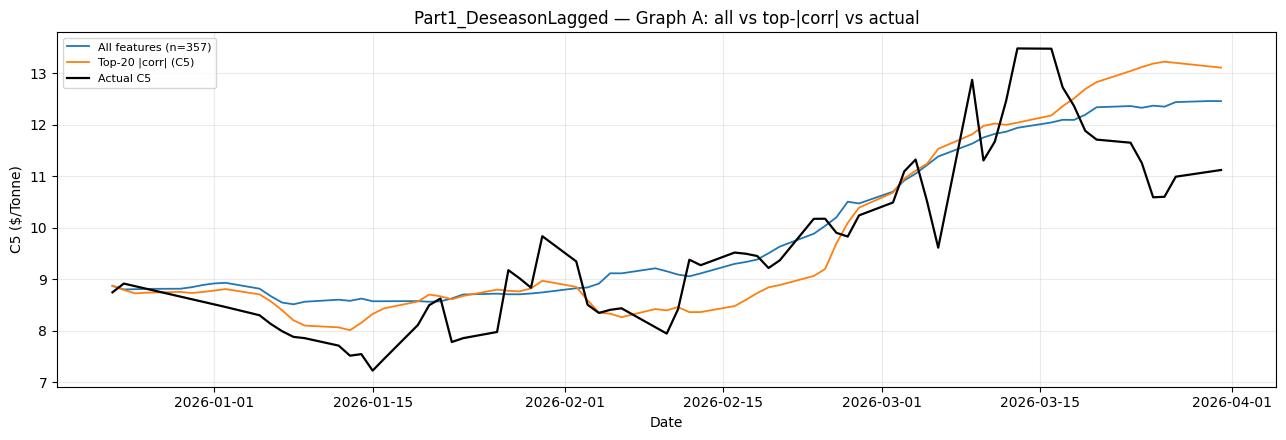

Saved: /content/drive/MyDrive/Project 005 Data/chronos2_dual_Part1_DeseasonLagged_graphA__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Part1_DeseasonLagged | Section B bundles: 6
Feature manifest saved: chronos2_dual_Part1_DeseasonLagged_graphB_feature_manifest__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Chronos OK | amazon_chronos-2|Part1_DeseasonLagged_xgb_importance|n=76 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=76
Chronos OK | amazon_chronos-2|Part1_DeseasonLagged_kbest_60|n=56 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=56
Chronos OK | amazon_chronos-2|Part1_DeseasonLagged_ar_plus_kbest_60|n=63 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=63
Chronos OK | amazon_chronos-2|Part1_DeseasonLagged_kbest_40|n=36 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=36
Chrono

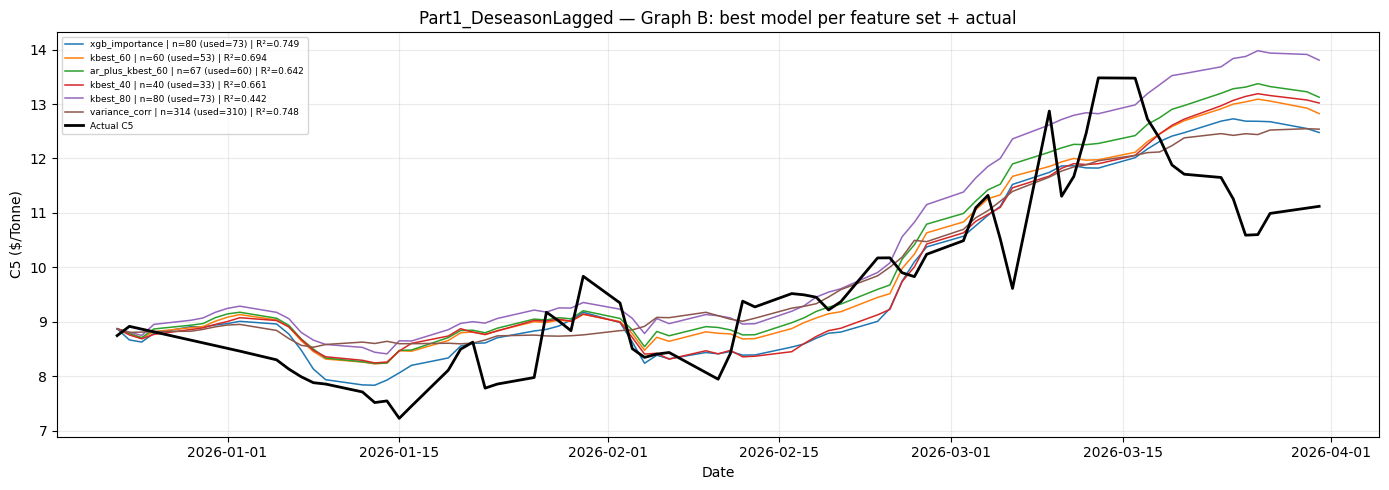

Saved: /content/drive/MyDrive/Project 005 Data/chronos2_dual_Part1_DeseasonLagged_graphB__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
  NeuralProphet injected | forecast coverage: 71/71 rows
Chronos OK | amazon_chronos-2|Part2_MasterLagged_all|n=359 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=359
Chronos OK | amazon_chronos-2|Part2_MasterLagged_top20|n=20 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=20

=== Part2_MasterLagged | Section A metrics (vs actual) ===
  all features | R² C5=0.6334 | n=64
  top-20 |corr| | R² C5=0.7044 | n=64


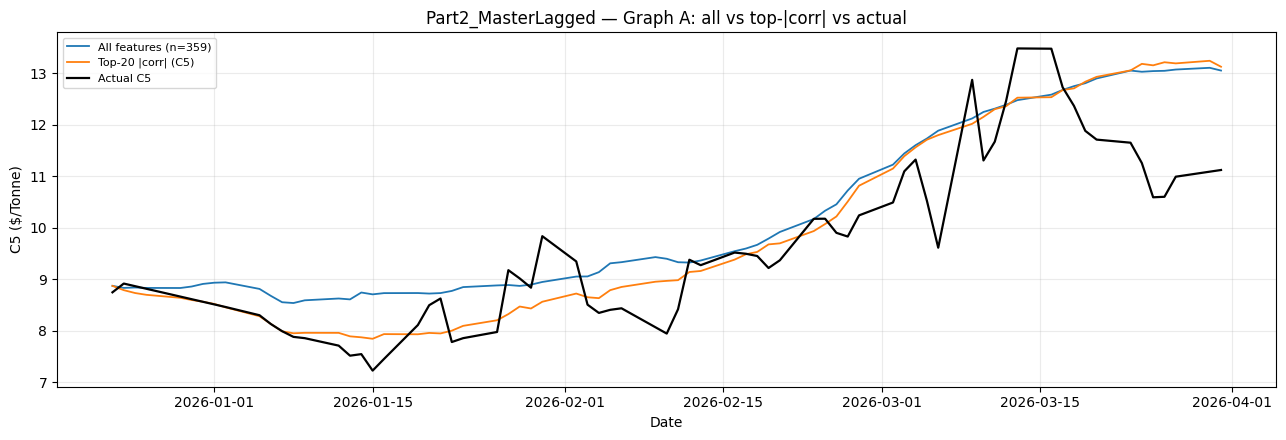

Saved: /content/drive/MyDrive/Project 005 Data/chronos2_dual_Part2_MasterLagged_graphA__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Part2_MasterLagged | Section B bundles: 6
Feature manifest saved: chronos2_dual_Part2_MasterLagged_graphB_feature_manifest__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Chronos OK | amazon_chronos-2|Part2_MasterLagged_kbest_60|n=56 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=56
Chronos OK | amazon_chronos-2|Part2_MasterLagged_ar_plus_kbest_60|n=63 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=63
Chronos OK | amazon_chronos-2|Part2_MasterLagged_kbest_40|n=36 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=36
Chronos OK | amazon_chronos-2|Part2_MasterLagged_kbest_80|n=76 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=76
Chronos OK | amazon_chrono

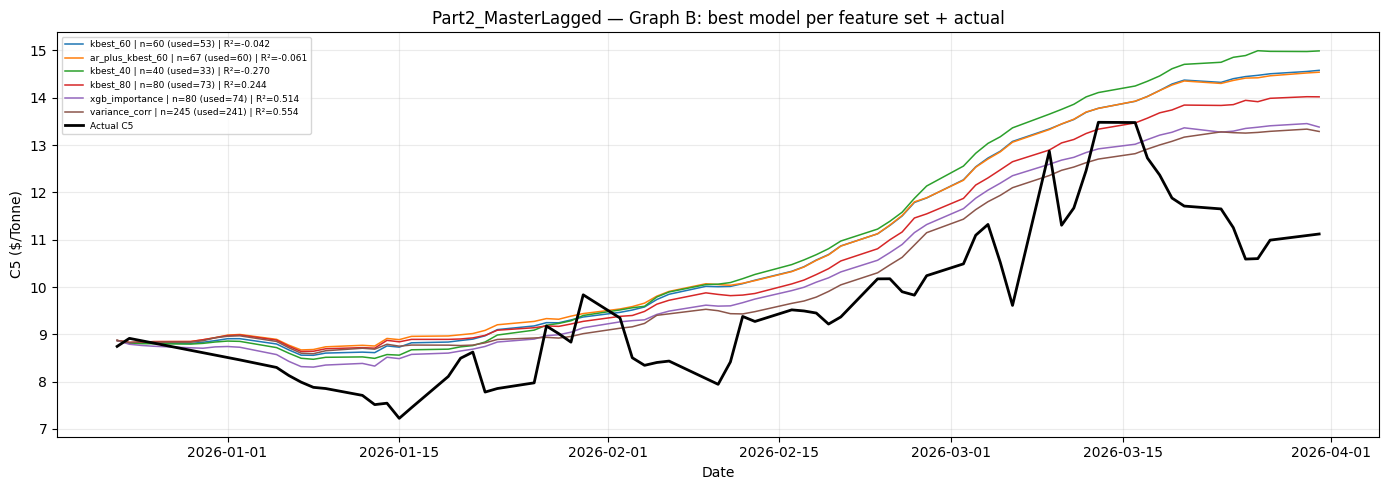

Saved: /content/drive/MyDrive/Project 005 Data/chronos2_dual_Part2_MasterLagged_graphB__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
  NeuralProphet injected | forecast coverage: 71/71 rows
Chronos OK | amazon_chronos-2|Part3_BothLagged_all|n=713 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=713
Chronos OK | amazon_chronos-2|Part3_BothLagged_top20|n=20 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=20

=== Part3_BothLagged | Section A metrics (vs actual) ===
  all features | R² C5=0.6798 | n=64
  top-20 |corr| | R² C5=0.7044 | n=64


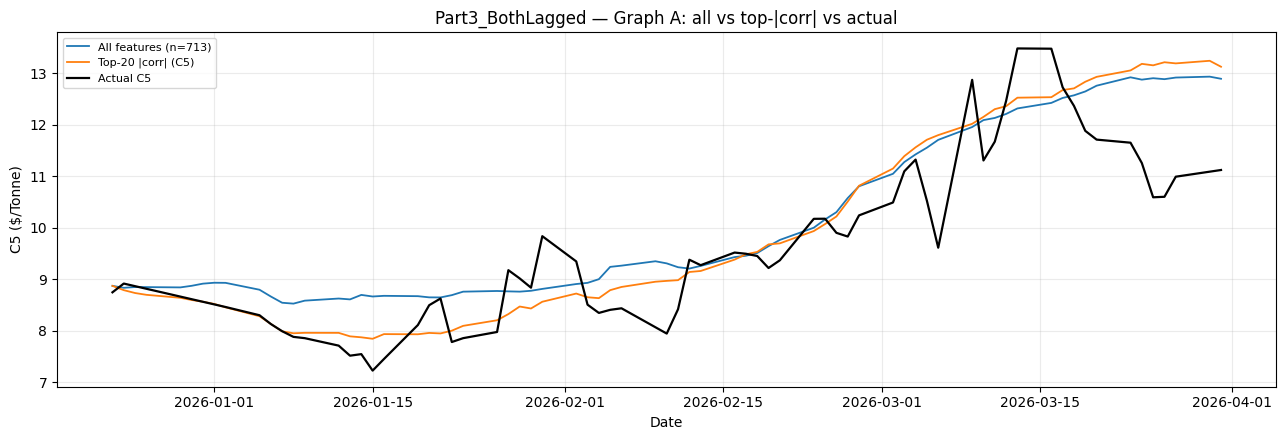

Saved: /content/drive/MyDrive/Project 005 Data/chronos2_dual_Part3_BothLagged_graphA__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Part3_BothLagged | Section B bundles: 10
Feature manifest saved: chronos2_dual_Part3_BothLagged_graphB_feature_manifest__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Part3_BothLagged | duplicate tag 'Part3_BothLagged_kbest_60|n=56' — renamed to 'Part3_BothLagged_kbest_60|n=56_v1'
Part3_BothLagged | duplicate tag 'Part3_BothLagged_ar_plus_kbest_60|n=63' — renamed to 'Part3_BothLagged_ar_plus_kbest_60|n=63_v1'
Part3_BothLagged | duplicate tag 'Part3_BothLagged_kbest_40|n=36' — renamed to 'Part3_BothLagged_kbest_40|n=36_v1'
Part3_BothLagged | duplicate tag 'Part3_BothLagged_kbest_80|n=76' — renamed to 'Part3_BothLagged_kbest_80|n=76_v1'
Chronos OK | amazon_chronos-2|Part3_BothLagged_xgb_importan

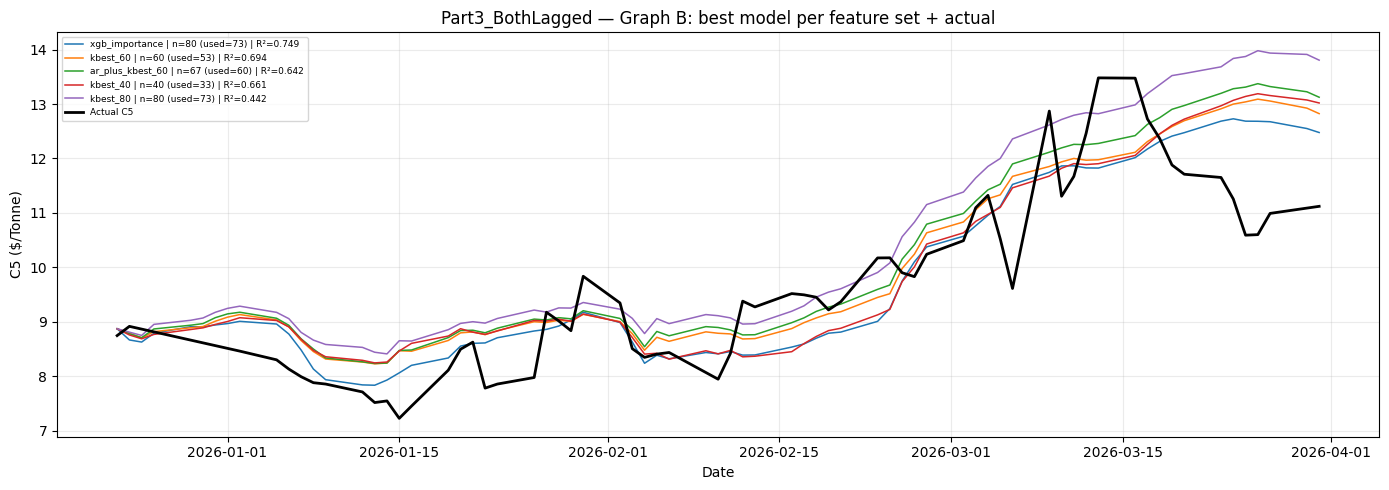

Saved: /content/drive/MyDrive/Project 005 Data/chronos2_dual_Part3_BothLagged_graphB__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Part 5 | merged selection: XGBoost_MasterPlusDeseason_Lagged_C5_feature_sets_results.xlsx cols=6
  NeuralProphet injected | forecast coverage: 71/71 rows
Chronos OK | amazon_chronos-2|Part5_MergedXGB_all|n=713 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=713
Chronos OK | amazon_chronos-2|Part5_MergedXGB_top20|n=20 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=20

=== Part5_MergedXGB | Section A metrics (vs actual) ===
  all features | R² C5=0.6798 | n=64
  top-20 |corr| | R² C5=0.7044 | n=64


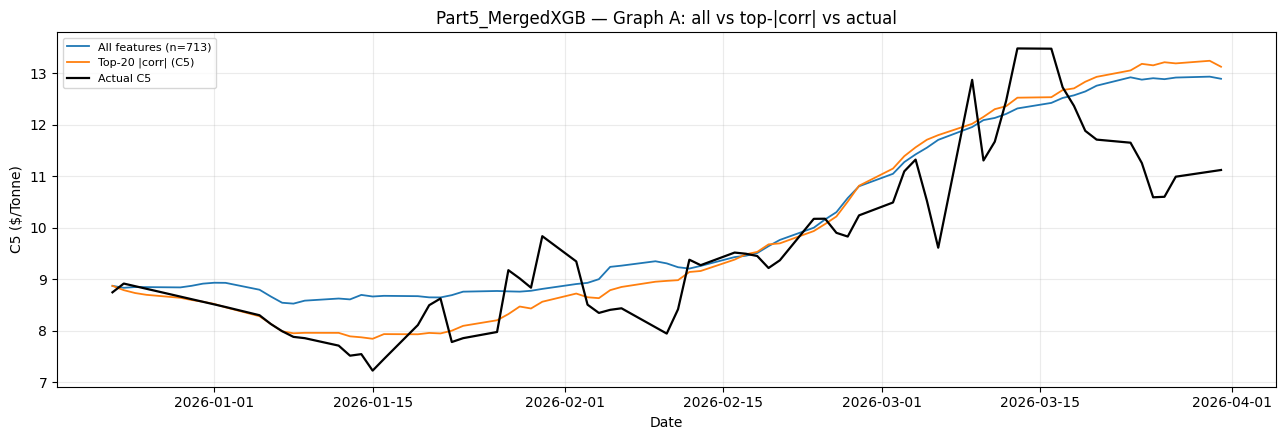

Saved: /content/drive/MyDrive/Project 005 Data/chronos2_dual_Part5_MergedXGB_graphA__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Part5_MergedXGB | Section B bundles: 6
Feature manifest saved: chronos2_dual_Part5_MergedXGB_graphB_feature_manifest__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Chronos OK | amazon_chronos-2|Part5_MergedXGB_kbest_60|n=56 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=56
Chronos OK | amazon_chronos-2|Part5_MergedXGB_ar_plus_kbest_60|n=63 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=63
Chronos OK | amazon_chronos-2|Part5_MergedXGB_kbest_40|n=36 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=36
Chronos OK | amazon_chronos-2|Part5_MergedXGB_kbest_80|n=76 | OK model=amazon/chronos-2 rows=71 target_scale=c5 | cov=76
Chronos OK | amazon_chronos-2|Part5_MergedXGB_x

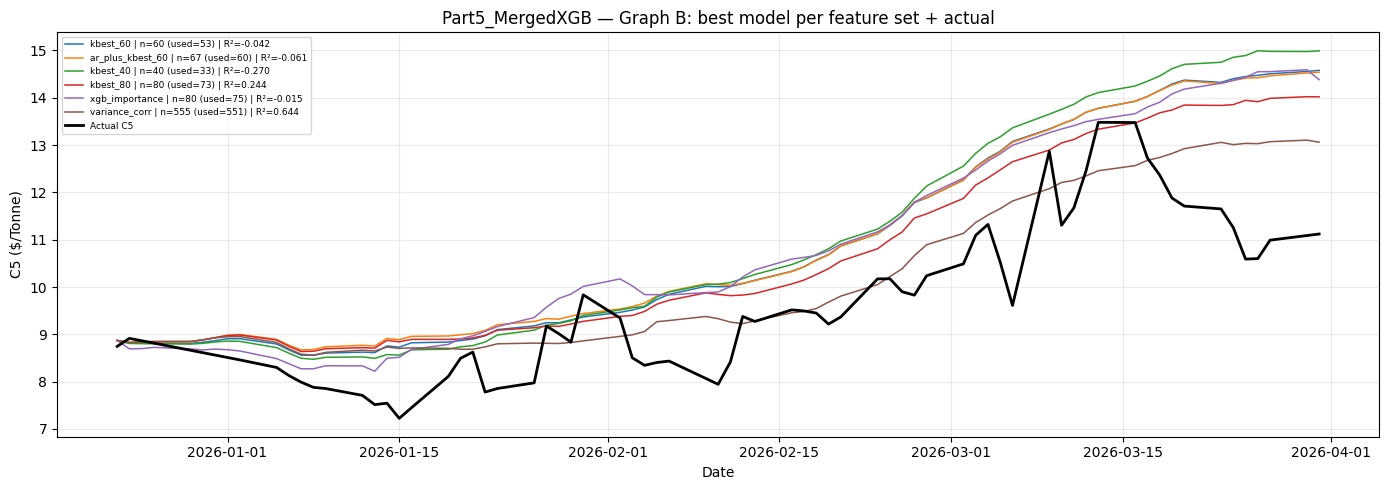

Saved: /content/drive/MyDrive/Project 005 Data/chronos2_dual_Part5_MergedXGB_graphB__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv

Done — Parts 1–5.


In [4]:
# --- load shared inputs ---
if not MASTER_FILE.is_file():
    raise FileNotFoundError(MASTER_FILE)
master_raw = read_excel_colab_safe(MASTER_FILE)
require_columns(master_raw, [MASTER_DATE_COL, MASTER_C5_COL], "Master")

if not ACTUAL_FILE.is_file():
    raise FileNotFoundError(ACTUAL_FILE)
actual_raw = read_excel_colab_safe(ACTUAL_FILE, sheet_name=ACTUAL_SHEET, header=ACTUAL_HEADER)
require_columns(actual_raw, [ACTUAL_DATE_COL, ACTUAL_C5_COL], "Actual file")
actual_df = actual_raw[[ACTUAL_DATE_COL, ACTUAL_C5_COL]].copy()
actual_df.columns = ["Date", "C5_actual"]
actual_df["Date"] = pd.to_datetime(actual_df["Date"], errors="coerce")
actual_df["C5_actual"] = pd.to_numeric(actual_df["C5_actual"], errors="coerce")
actual_df = (
    actual_df.dropna(subset=["Date", "C5_actual"])
    .sort_values("Date")
    .drop_duplicates(subset=["Date"], keep="last")
)
actual_df = actual_df[actual_df["C5_actual"] > 0].reset_index(drop=True)

if not FEATURE_SELECTION_XLSX.is_file():
    raise FileNotFoundError(FEATURE_SELECTION_XLSX)
selection_ranked_deseason = parse_selection_columns_ranked(
    FEATURE_SELECTION_XLSX, int(SECTION2_SELECTION_N)
)
if not selection_ranked_deseason:
    raise ValueError("No Test_R2= columns in XGBoost_model_features_by_selection.xlsx")

selection_ranked_master = parse_selection_wide_sheet_ranked(
    FEATURE_SELECTION_MASTER_RESULTS_XLSX,
    FEATURE_SELECTION_MASTER_WIDE_SHEET,
    int(SECTION2_SELECTION_N),
)
if selection_ranked_master:
    print(
        "Section B | Master-lagged selection lists:",
        FEATURE_SELECTION_MASTER_RESULTS_XLSX.name,
        f"sheet={FEATURE_SELECTION_MASTER_WIDE_SHEET!r} ({len(selection_ranked_master)} cols)",
    )
else:
    print(
        "Section B | No master wide selection file (optional):",
        FEATURE_SELECTION_MASTER_RESULTS_XLSX,
        "— Part 2 Graph B will fall back to deseason feature names (usually no overlap).",
    )

# Part 1 — Deseason lagged only
lag_ds, cov_ds, map_ds = process_lagged_workbook(DESEASON_LAGGED_XLSX, col_prefix="", exclude_exact=None)
run_part(
    "Part1_DeseasonLagged",
    lag_ds,
    cov_ds,
    map_ds,
    master_raw,
    actual_df,
    selection_ranked_deseason,
)

# Part 2 — Master AVG lagged only (use Master XGBoost results wide sheet when present)
sel_p2 = (
    selection_ranked_master
    if selection_ranked_master
    else selection_ranked_deseason
)
if not selection_ranked_master:
    print(
        "Part2 | WARNING: using deseason selection names for Part 2 — expect Graph B skips unless names match Master lagged columns."
    )
lag_mv, cov_mv, map_mv = process_lagged_workbook(
    MASTER_LAGGED_XLSX, col_prefix="", exclude_exact=EXCLUDE_MASTER_LAG_EXACT
)
run_part("Part2_MasterLagged", lag_mv, cov_mv, map_mv, master_raw, actual_df, sel_p2)

# Part 3 — both: merge selection lists by Test_R2 so Chronos sees ds_* and mav_* features
sel_p3 = merge_selection_ranked_by_r2(
    [selection_ranked_deseason, selection_ranked_master]
    if selection_ranked_master
    else [selection_ranked_deseason],
    int(SECTION2_SELECTION_N),
)
lag_c, cov_c, map_c = combine_two_lagged(DESEASON_LAGGED_XLSX, MASTER_LAGGED_XLSX)
run_part("Part3_BothLagged", lag_c, cov_c, map_c, master_raw, actual_df, sel_p3)

# Part 5 — Merged Master+Deseason XGBoost wide sheet
# Uses lag_c / cov_c / map_c already built by Part 3 (combine_two_lagged)
if not FEATURE_SELECTION_MERGED_XLSX.is_file():
    print("Part 5 skip — file not found:", FEATURE_SELECTION_MERGED_XLSX)
else:
    ranked_p5 = parse_selection_wide_sheet_ranked(
        FEATURE_SELECTION_MERGED_XLSX,
        FEATURE_SELECTION_MERGED_WIDE_SHEET,
        int(SECTION2_SELECTION_N),
    )
    if not ranked_p5:
        print("Part 5 skip — no Test_R2= columns in sheet",
              repr(FEATURE_SELECTION_MERGED_WIDE_SHEET))
    else:
        print(
            "Part 5 | merged selection:",
            FEATURE_SELECTION_MERGED_XLSX.name,
            f"cols={len(ranked_p5)}",
        )
        run_part(
            "Part5_MergedXGB",
            lag_c,
            cov_c,
            map_c,
            master_raw,
            actual_df,
            ranked_p5,
        )

print("\nDone — Parts 1–5.")



## Part 4 — 2025 C5 backtest (paired feature sets)

For every feature-set **tag** shared by **`XGBoost_Master_Lagged_C5_feature_sets_results.xlsx`** (Master lagged columns) and **`XGBoost_model_features_by_selection.xlsx`** (Deseason lagged columns, first sheet), this cell runs **two** Chronos forecasts over **business days** in **`BACKTEST_2025_START`–`BACKTEST_2025_END`**, using only data strictly before the backtest start for context. Errors are **MAE on C5** vs **`C5 Through End Q126.xlsx`**; the ensemble uses **weights ∝ 1/MAE** (normalized). Charts: **up to `SECTION2_SELECTION_N` (default 6)** **ensemble** lines (one per feature-set tag, ranked by 2025 ensemble MAE) plus **actual** C5 for the backtest window, plus an MAE bar chart by tag. **After that**, the same top tags get a **forward Chronos** run on **`FORECAST_START`–`FORECAST_END`**; predictions are compared to **true 2026 C5** on dates in **`EVAL_2026_START`–`EVAL_2026_END`** (clipped to the forecast horizon and to dates with actuals). Summary and per-day CSVs are written under **`BASE_DIR`**.

## Part 5 — Merged XGBoost feature lists (Graph A + B)

Uses **`XGBoost_MasterPlusDeseason_Lagged_C5_feature_sets_results.xlsx`** (sheet **`model_features_by_selection`**) with the **combined** `ds_*` + `mav_*` lagged panel — same **Graph A / Graph B** pattern as Parts 1–2. Requires the main run cell to have built **`lag_c`**, **`cov_c`**, **`map_c`**.


Part 4 | Loading Part 1 & 2 CSVs:
  ✓ chronos2_dual_Part1_DeseasonLagged_graphA__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv  (71 rows, 4 forecast cols)
  ✓ chronos2_dual_Part1_DeseasonLagged_graphB__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv  (71 rows, 18 forecast cols)
  ✓ chronos2_dual_Part2_MasterLagged_graphA__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv  (71 rows, 4 forecast cols)
  ✓ chronos2_dual_Part2_MasterLagged_graphB__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv  (71 rows, 18 forecast cols)

Part 4 | Q1 2026 rows: 64
Part 4 | Forecast columns: 40
Part 4 | Q1 2026 rows with actuals: 62

Part 4 | Q1 2026 Model Leaderboard (Part 1 & 2 forecast

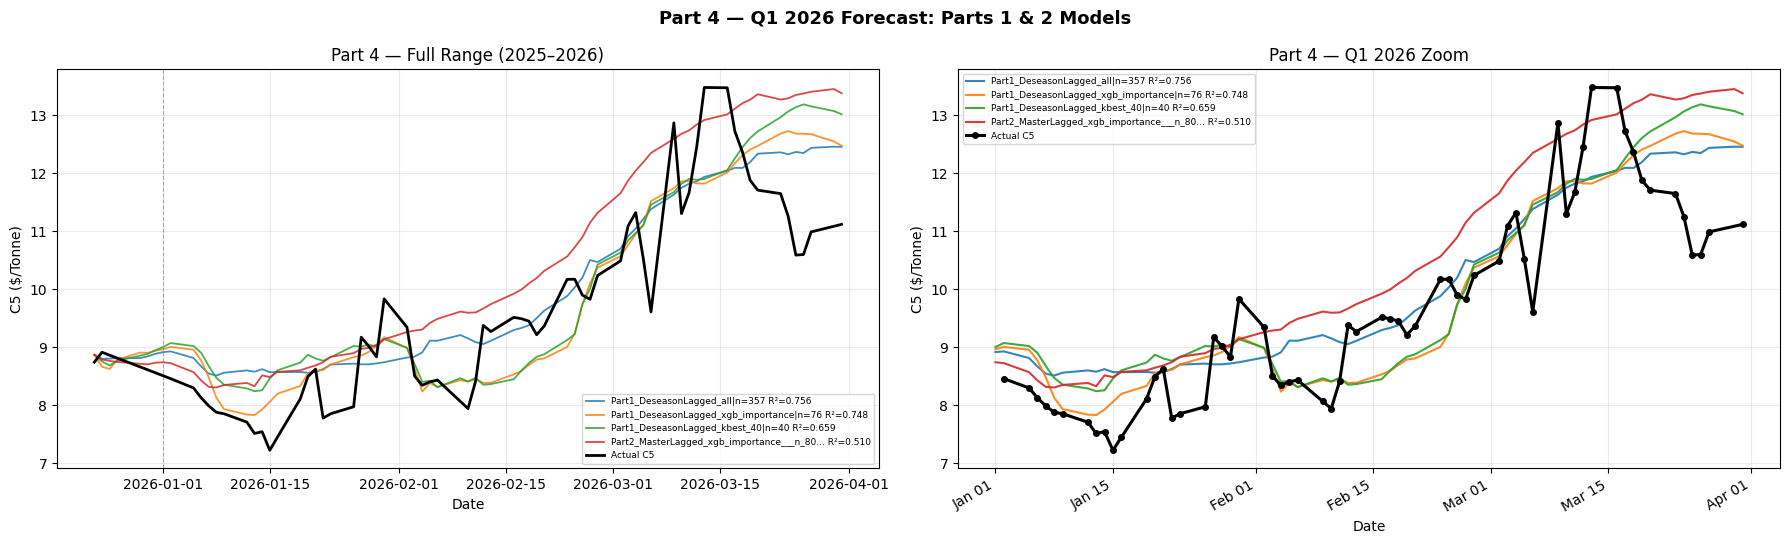


Part 4 | Saved: chronos2_dual_part4_fwd_2026_vs_actual_daily__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv  (64 rows, 5 models)


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Part 4 — Q1 2026 Forecast Comparison: Parts 1 & 2 Models
# Loads the saved Graph A/B CSVs from Part 1 (Deseason) and Part 2 (Master),
# filters to Q1 2026, scores vs actuals, plots the best models, and exports
# a consolidated Part 4 forward-forecast file.
# Requires: definitions cell (BASE_DIR, CHRONOS_FILE_TAG, actual_df) + Parts 1–2 run.
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.dates as mdates

# ── 1. Load Part 1 & 2 Graph A/B CSVs ────────────────────────────────────────
_p4_files = [
    BASE_DIR / f"chronos2_dual_Part1_DeseasonLagged_graphA{CHRONOS_FILE_TAG}.csv",
    BASE_DIR / f"chronos2_dual_Part1_DeseasonLagged_graphB{CHRONOS_FILE_TAG}.csv",
    BASE_DIR / f"chronos2_dual_Part2_MasterLagged_graphA{CHRONOS_FILE_TAG}.csv",
    BASE_DIR / f"chronos2_dual_Part2_MasterLagged_graphB{CHRONOS_FILE_TAG}.csv",
]

def _load_csv(fp):
    """Load a Graph CSV, normalise Date column, deduplicate rows."""
    df = pd.read_csv(fp)
    date_col = next((c for c in df.columns if str(c).strip().lower() == "date"), df.columns[0])
    df["Date"] = pd.to_datetime(df[date_col], errors="coerce").dt.normalize()
    df = df.dropna(subset=["Date"])
    df = df.drop_duplicates(subset=["Date"], keep="last").sort_values("Date").reset_index(drop=True)
    if "Date" != date_col and date_col in df.columns:
        df = df.drop(columns=[date_col])
    return df

_p4_dfs = []
print("Part 4 | Loading Part 1 & 2 CSVs:")
for _fp in _p4_files:
    if _fp.is_file():
        _df = _load_csv(_fp)
        _p4_dfs.append(_df)
        _fcols = [c for c in _df.columns if c not in ("Date", "C5_actual")]
        print(f"  ✓ {_fp.name}  ({len(_df)} rows, {len(_fcols)} forecast cols)")
    else:
        print(f"  – not found: {_fp.name}")

if not _p4_dfs:
    print("\nPart 4 SKIP: no Part 1/2 CSV files found — run Cell 5 first.")
else:
    # ── 2. Merge all CSVs on Date ─────────────────────────────────────────────
    _p4_combined = _p4_dfs[0].copy()
    for _df in _p4_dfs[1:]:
        _new = [c for c in _df.columns if c != "Date" and c not in _p4_combined.columns]
        if "C5_actual" in _df.columns and "C5_actual" not in _p4_combined.columns:
            _new.append("C5_actual")
        if _new:
            _p4_combined = _p4_combined.merge(_df[["Date"] + _new], on="Date", how="outer")
    _p4_combined = _p4_combined.sort_values("Date").reset_index(drop=True)

    # Inject actuals from actual_df if not already present
    if "C5_actual" not in _p4_combined.columns:
        _p4_combined = _p4_combined.merge(actual_df, on="Date", how="left")
    else:
        # Fill gaps in C5_actual from actual_df
        _act_extra = actual_df.rename(columns={"C5_actual": "_C5_act_fill"})
        _p4_combined = _p4_combined.merge(_act_extra, on="Date", how="left")
        _p4_combined["C5_actual"] = _p4_combined["C5_actual"].fillna(_p4_combined["_C5_act_fill"])
        _p4_combined = _p4_combined.drop(columns=["_C5_act_fill"])

    # ── 3. Filter to Q1 2026 ─────────────────────────────────────────────────
    _q1_start = pd.Timestamp("2026-01-01")
    _q1_end   = pd.Timestamp("2026-03-31")
    _p4_q1 = _p4_combined[
        (_p4_combined["Date"] >= _q1_start) & (_p4_combined["Date"] <= _q1_end)
    ].copy()
    print(f"\nPart 4 | Q1 2026 rows: {len(_p4_q1)}")

    # ── 4. Score each model vs actuals in Q1 2026 ────────────────────────────
    _p4_eval = _p4_q1.dropna(subset=["C5_actual"])
    _forecast_cols = [c for c in _p4_q1.columns if c not in ("Date", "C5_actual")
                      and not str(c).startswith("log_C5")]
    print(f"Part 4 | Forecast columns: {len(_forecast_cols)}")
    print(f"Part 4 | Q1 2026 rows with actuals: {len(_p4_eval)}")

    _p4_scores = []
    for _col in _forecast_cols:
        _v = _p4_eval.dropna(subset=[_col])
        if len(_v) < 3:
            continue
        try:
            _r2  = float(r2_score(_v["C5_actual"], _v[_col]))
            _mae = float(mean_absolute_error(_v["C5_actual"], _v[_col]))
            _p4_scores.append({"model": _col, "R2": _r2, "MAE": _mae, "n": len(_v)})
        except Exception:
            pass

    _p4_scores_df = (
        pd.DataFrame(_p4_scores).sort_values("R2", ascending=False).reset_index(drop=True)
        if _p4_scores else pd.DataFrame()
    )

    # ── 5. Print leaderboard ─────────────────────────────────────────────────
    print("\n" + "="*70)
    print("Part 4 | Q1 2026 Model Leaderboard (Part 1 & 2 forecasts vs actual)")
    print("="*70)
    if _p4_scores_df.empty:
        print("  (no overlap with actuals yet — forecast-only period)")
    else:
        for _, _row in _p4_scores_df.head(10).iterrows():
            _lbl = str(_row["model"])
            if len(_lbl) > 60: _lbl = _lbl[:60] + "..."
            print(f"  R²={_row['R2']:+.4f}  MAE={_row['MAE']:.2f}  {_lbl}")

    # ── 5b. Deduplicate before plotting ─────────────────────────────────────
    # Pass 1: R² @ 3dp — drop models with near-identical scores
    # Pass 2: pairwise Pearson correlation — drop near-identical forecast series
    if not _p4_scores_df.empty:
        _p4_scores_df["_r2r"] = _p4_scores_df["R2"].round(3)
        _p4_dedup = _p4_scores_df.drop_duplicates(subset="_r2r", keep="first").drop(columns="_r2r")

        _CORR_THRESH = 0.995
        _p4_eval_matrix = _p4_eval[[c for c in _p4_dedup["model"].tolist() if c in _p4_eval.columns]].copy()
        _p4_kept = []
        _p4_dropped = []
        for _col in _p4_dedup["model"].tolist():
            if _col not in _p4_eval_matrix.columns:
                _p4_kept.append(_col)
                continue
            _is_dup = False
            for _prev in _p4_kept:
                if _prev not in _p4_eval_matrix.columns:
                    continue
                _pair = _p4_eval_matrix[[_col, _prev]].dropna()
                if len(_pair) < 3:
                    continue
                try:
                    _corr = float(_pair[_col].corr(_pair[_prev]))
                except Exception:
                    continue
                if _corr > _CORR_THRESH:
                    _is_dup = True
                    _p4_dropped.append((_col, _prev, round(_corr, 4)))
                    break
            if not _is_dup:
                _p4_kept.append(_col)

        _p4_scores_df = _p4_dedup[_p4_dedup["model"].isin(_p4_kept)].reset_index(drop=True)
        _n_p4_removed = len(_p4_kept) - len(_p4_scores_df) + len(_p4_dropped)
        print(f"Part 4 | Dedup: {len(_forecast_cols)} cols → {len(_p4_dedup)} (R²@3dp) → {len(_p4_scores_df)} (corr>{_CORR_THRESH})")
        if _p4_dropped:
            for _dc, _dk, _dv in _p4_dropped:
                _dl = str(_dc)[:55]; _kl = str(_dk)[:55]
                print(f"  ↳ dropped '{_dl}' (r={_dv} with '{_kl}')")

    # ── 6. Plot: Top-8 unique models + actual across full date range ──────────
    _top_cols = _p4_scores_df["model"].head(8).tolist() if not _p4_scores_df.empty else _forecast_cols[:8]

    # Full date range (training + forecast)
    _plot_full = _p4_combined[_p4_combined["Date"] >= pd.Timestamp("2025-01-01")].copy()
    _plot_act  = _plot_full.dropna(subset=["C5_actual"])

    fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

    # Left panel: full range
    ax = axes[0]
    _colors = plt.cm.tab10.colors
    for i, _col in enumerate(_top_cols):
        if _col not in _plot_full.columns:
            continue
        _lbl = str(_col)
        if len(_lbl) > 40: _lbl = _lbl[:40] + "..."
        if not _p4_scores_df.empty and _col in _p4_scores_df["model"].values:
            _r2v = float(_p4_scores_df.loc[_p4_scores_df["model"] == _col, "R2"].iloc[0])
            _lbl += f" R²={_r2v:.3f}"
        ax.plot(_plot_full["Date"], _plot_full[_col],
                color=_colors[i % 10], linewidth=1.3, alpha=0.85, label=_lbl)
    if not _plot_act.empty:
        ax.plot(_plot_act["Date"], _plot_act["C5_actual"],
                color="black", linewidth=2.0, label="Actual C5", zorder=10)
    ax.axvline(_q1_start, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_title("Part 4 — Full Range (2025–2026)")
    ax.set_xlabel("Date"); ax.set_ylabel("C5 ($/Tonne)")
    ax.legend(loc="best", fontsize=6.5)
    ax.grid(alpha=0.25)

    # Right panel: Q1 2026 only
    ax2 = axes[1]
    for i, _col in enumerate(_top_cols):
        if _col not in _p4_q1.columns:
            continue
        _lbl = str(_col)
        if len(_lbl) > 40: _lbl = _lbl[:40] + "..."
        if not _p4_scores_df.empty and _col in _p4_scores_df["model"].values:
            _r2v = float(_p4_scores_df.loc[_p4_scores_df["model"] == _col, "R2"].iloc[0])
            _lbl += f" R²={_r2v:.3f}"
        ax2.plot(_p4_q1["Date"], _p4_q1[_col],
                 color=_colors[i % 10], linewidth=1.5, alpha=0.9, label=_lbl)
    if not _p4_eval.empty:
        ax2.plot(_p4_eval["Date"], _p4_eval["C5_actual"],
                 color="black", linewidth=2.2, label="Actual C5", zorder=10,
                 marker="o", markersize=4)
    ax2.set_title("Part 4 — Q1 2026 Zoom")
    ax2.set_xlabel("Date"); ax2.set_ylabel("C5 ($/Tonne)")
    ax2.legend(loc="best", fontsize=6.5)
    ax2.grid(alpha=0.25)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")

    plt.suptitle("Part 4 — Q1 2026 Forecast: Parts 1 & 2 Models", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ── 7. Export consolidated Part 4 file ───────────────────────────────────
    _p4_export_cols = ["Date"] + _top_cols
    if "C5_actual" in _p4_q1.columns:
        _p4_export_cols.append("C5_actual")
    _p4_export = _p4_q1[[c for c in _p4_export_cols if c in _p4_q1.columns]].copy()
    _p4_out = BASE_DIR / f"chronos2_dual_part4_fwd_2026_vs_actual_daily{CHRONOS_FILE_TAG}.csv"
    _p4_export.to_csv(_p4_out, index=False)
    print(f"\nPart 4 | Saved: {_p4_out.name}  ({len(_p4_export)} rows, {len(_p4_export.columns)-1} models)")


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# TOP 10 SINGLE-PASS MODELS BY R² — FEATURE MANIFEST
# ═══════════════════════════════════════════════════════════════════════════════

import re
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

def _clean_feat(name: str) -> str:
    for _pfx in ('mav_', 'ds_', 'master_', 'lagged_', 'transformed_'):
        if name.startswith(_pfx):
            name = name[len(_pfx):]
            break
    _prev = None
    while _prev != name:
        _prev = name
        name = re.sub(r'_season\w*\d+\w*(_ar\d+)?$', '', name, flags=re.IGNORECASE)
        name = re.sub(r'_ar\d+$',                      '', name, flags=re.IGNORECASE)
        name = re.sub(r'_(ma|lag|rolling)_\d+$',        '', name, flags=re.IGNORECASE)
        name = re.sub(r'_(ma|lag|rolling)\d+$',          '', name, flags=re.IGNORECASE)
        name = re.sub(r'(?<=[^_a-zA-Z])(ma|lag|rolling)\d+$', '', name, flags=re.IGNORECASE)
    return name.strip('_')

# ── Load all saved Graph A/B CSVs ────────────────────────────────────────────
_csv_globs = [
    f"chronos2_dual_Part1_DeseasonLagged_graphA{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part1_DeseasonLagged_graphB{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part2_MasterLagged_graphA{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part2_MasterLagged_graphB{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part3_BothLagged_graphA{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part3_BothLagged_graphB{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_part4_fwd_2026_vs_actual_daily{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part5_MergedXGB_graphA{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part5_MergedXGB_graphB{CHRONOS_FILE_TAG}.csv",
]

_dfs = []
for _g in _csv_globs:
    _fp = BASE_DIR / _g
    if _fp.is_file():
        _dfs.append(pd.read_csv(_fp, parse_dates=["Date"]))
    else:
        print(f"  not found: {_g}")

if not _dfs:
    print("No CSV files found — run Parts 1–5 first.")
else:
    _combined = _dfs[0].copy()
    for _df in _dfs[1:]:
        _new_cols = [c for c in _df.columns if c not in _combined.columns]
        if "C5_actual" in _df.columns and "C5_actual" not in _combined.columns:
            _new_cols.append("C5_actual")
        if _new_cols:
            _combined = _combined.merge(_df[["Date"] + _new_cols], on="Date", how="outer")

    _eval = _combined.dropna(subset=["C5_actual"])
    if _eval.empty:
        print("No rows with C5_actual — cannot score models.")
    else:
        # ── Score ─────────────────────────────────────────────────────────────
        _scores = []
        for _col in _combined.columns:
            if _col in ("Date", "C5_actual"):
                continue
            _v = _eval.dropna(subset=[_col])
            if len(_v) < 3:
                continue
            try:
                _r2 = float(r2_score(_v["C5_actual"], _v[_col]))
            except Exception:
                continue
            _scores.append({"forecast_col": _col, "r2_vs_actual": round(_r2, 6)})

        _scores_df = (pd.DataFrame(_scores)
                      .sort_values("r2_vs_actual", ascending=False)
                      .reset_index(drop=True))

        # ── Join registry ─────────────────────────────────────────────────────
        if not CHRONOS_MODEL_REGISTRY:
            print("⚠  CHRONOS_MODEL_REGISTRY is empty.")
            print("   Re-run Parts 1–5 in this kernel session so the registry is populated,")
            print("   then re-run this cell.")
        else:
            _reg_df = pd.DataFrame(CHRONOS_MODEL_REGISTRY).drop_duplicates("forecast_col")
            _scored = _scores_df.merge(_reg_df, on="forecast_col", how="left")

            # ── Dedup: feature set → R²@2dp ───────────────────────────────────
            def _feat_key(row):
                f = row.get("features")
                return frozenset(f) if isinstance(f, list) and f else row["forecast_col"]

            _scored["_dk"] = _scored.apply(_feat_key, axis=1)
            _d1 = _scored.drop_duplicates("_dk", keep="first").copy()
            _d1["_r2r"] = _d1["r2_vs_actual"].round(2)
            _d2 = _d1.drop_duplicates("_r2r", keep="first").drop(columns=["_dk", "_r2r"])
            print(f"Dedup: {len(_scored)} → {len(_d1)} (feature set) → {len(_d2)} (R²@2dp)")

            _top10 = _d2.head(10).reset_index(drop=True)

            # ── Show top 10 with xgb_r2 so the filter is visible ─────────────
            _n_col = next((c for c in ["n_features_xgb", "n_features_mapped", "n_features"]
                           if c in _top10.columns), None)
            print(f"\nTop 10 (✓ = XGBoost-selected, has xgb_r2):")
            for _, _r in _top10.iterrows():
                _xr2 = _r.get("xgb_r2")
                _flag = "✓ XGB" if pd.notna(_xr2) else "✗ all/corr"
                _nf   = int(_r[_n_col]) if _n_col and pd.notna(_r.get(_n_col)) else "?"
                print(f"  [{_flag}]  R²={_r['r2_vs_actual']:.4f}  n={_nf}  {_r['forecast_col']}")

            # ── Filter: ONLY models where registry explicitly set xgb_r2 ──────
            # Graph A "all features" and "topcorr" models have xgb_r2 = None.
            # Graph B XGBoost-selected models always have a float xgb_r2.
            # This is set directly in run_part — it is the most reliable signal.
            _top10_xgb = _top10[
                _top10["xgb_r2"].notna() &
                _top10["features"].apply(lambda x: isinstance(x, list) and len(x) > 0)
            ].copy().reset_index(drop=True)

            print(f"\n→ {len(_top10_xgb)} XGBoost-selected models kept for feature extraction")

            if _top10_xgb.empty:
                print("  No XGBoost models in the top 10 — all top models are 'all features' runs.")
            else:
                # ── Collect & clean top 40 features per model by importance ──
                TOP_N = 40
                _union = set()
                print(f"\nFeatures taken per model (top {TOP_N} by importance):")
                for _, _r in _top10_xgb.iterrows():
                    _feat_list = _r["features"][:TOP_N]   # list is importance-ordered
                    _cleaned   = set()
                    for _f in _feat_list:
                        _c = _clean_feat(str(_f))
                        if _c:
                            _cleaned.add(_c)
                    _union.update(_cleaned)
                    _fc_short = str(_r["forecast_col"])[:60]
                    print(f"  {_fc_short}  →  {len(_feat_list)} raw / {len(_cleaned)} after clean")

                _union_df = pd.DataFrame(
                    sorted(_union), columns=["feature"]
                ).reset_index(drop=True)
                _union_df.insert(0, "feature_index", range(1, len(_union_df) + 1))

                pd.set_option("display.max_rows", None)
                pd.set_option("display.max_colwidth", 80)
                print(f"\n{'═'*65}")
                print(f"  {len(_union_df)} unique features across {len(_top10_xgb)} XGBoost models (top {TOP_N} each)")
                print(f"{'═'*65}")
                print(_union_df.to_string(index=False))

                _out = BASE_DIR / f"top10_models_unified_features{CHRONOS_FILE_TAG}.csv"
                _union_df.to_csv(_out, index=False)
                print(f"\nSaved → {_out.name}")

Dedup: 90 → 84 (feature set) → 21 (R²@2dp)

Top 10 (✓ = XGBoost-selected, has xgb_r2):
  [✗ all/corr]  R²=0.7576  n=?  Part1_DeseasonLagged_all|n=357
  [✓ XGB]  R²=0.7495  n=80  Part1_DeseasonLagged_xgb_importance|n=76
  [✗ all/corr]  R²=0.7044  n=?  Part3_BothLagged_topcorr20|n=20
  [✓ XGB]  R²=0.6938  n=60  Part3_BothLagged_kbest_60|n=56_v1
  [✗ all/corr]  R²=0.6798  n=?  Part5_MergedXGB_all|n=713
  [✗ all/corr]  R²=0.6612  n=?  Part1_DeseasonLagged_kbest_40|n=40
  [✓ XGB]  R²=0.6441  n=555  Part5_MergedXGB_variance_corr|n=554
  [✗ all/corr]  R²=0.6334  n=?  Part2_MasterLagged_all|n=359
  [✓ XGB]  R²=0.5543  n=245  Part2_MasterLagged_variance_corr|n=244
  [✓ XGB]  R²=0.5136  n=80  Part3_BothLagged_xgb_importance|n=77

→ 5 XGBoost-selected models kept for feature extraction

Features taken per model (top 40 by importance):
  Part1_DeseasonLagged_xgb_importance|n=76  →  40 raw / 36 after clean
  Part3_BothLagged_kbest_60|n=56_v1  →  40 raw / 39 after clean
  Part5_MergedXGB_variance_co


╔══════════════════════════════════════════════════════════════════════════════╗
║                    TOP 5 MODELS FROM SAVED CSVs                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

Base directory: /content/drive/MyDrive/Project 005 Data

Loading CSV files:
────────────────────────────────────────────────────────────────────────────────
  ✓ chronos2_dual_Part1_DeseasonLagged_graphA__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv  (71 rows, 5 forecast cols)
  ✓ chronos2_dual_Part1_DeseasonLagged_graphB__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv  (71 rows, 19 forecast cols)
  ✓ chronos2_dual_Part2_MasterLagged_graphA__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv  (71 rows, 5 fo

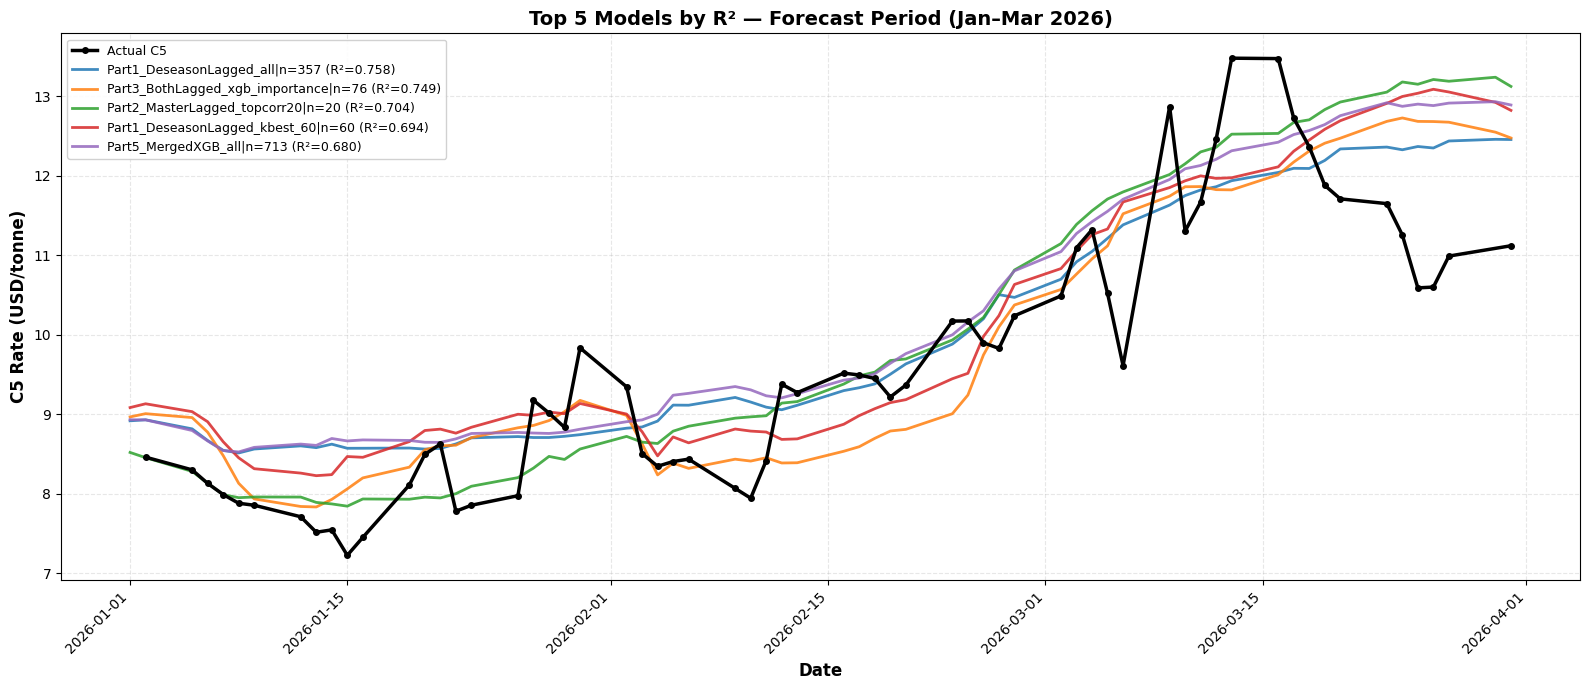


╔══════════════════════════════════════════════════════════════════════════════╗
║                              COMPLETE                                        ║
╚══════════════════════════════════════════════════════════════════════════════╝



In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# TOP 5 MODELS FROM SAVED CSV FILES
# Runs after Parts 1-5 complete; loads all Graph A/B CSVs, scores every model
# vs actuals, deduplicates by R², and visualises the top 5.
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path

print("\n" + "╔" + "═"*78 + "╗")
print("║" + " "*20 + "TOP 5 MODELS FROM SAVED CSVs" + " "*30 + "║")
print("╚" + "═"*78 + "╝\n")

# ─── Use the BASE_DIR from the definitions cell ───────────────────────────────
_top5_dir = BASE_DIR   # set by definitions cell; works in both Colab and local

GRAPH_PATTERNS = [
    f"chronos2_dual_Part1_DeseasonLagged_graphA{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part1_DeseasonLagged_graphB{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part2_MasterLagged_graphA{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part2_MasterLagged_graphB{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part3_BothLagged_graphA{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part3_BothLagged_graphB{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_part4_fwd_2026_vs_actual_daily{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part5_MergedXGB_graphA{CHRONOS_FILE_TAG}.csv",
    f"chronos2_dual_Part5_MergedXGB_graphB{CHRONOS_FILE_TAG}.csv",
]
# Fallback: also accept files without a tag suffix
GRAPH_PATTERNS_FB = [
    "chronos2_dual_Part*_graphA.csv",
    "chronos2_dual_Part*_graphB.csv",
]

print(f"Base directory: {_top5_dir}")

# ─── Load CSVs into a list of DataFrames with a normalised Date column ────────
def _load_graph_csv(fp: Path) -> pd.DataFrame | None:
    """Read a Graph A/B CSV; return df with Date column + deduped rows."""
    try:
        df = pd.read_csv(fp)
        # Normalise Date column
        date_col = next((c for c in df.columns if str(c).strip().lower() == "date"), None)
        if date_col is None:
            # First column may be an unnamed index
            df.columns = [str(c) for c in df.columns]
            if df.columns[0].startswith("Unnamed") or df.columns[0] == "":
                df = df.rename(columns={df.columns[0]: "Date"})
                date_col = "Date"
            else:
                date_col = df.columns[0]
        df["Date"] = pd.to_datetime(df[date_col], errors="coerce").dt.normalize()
        df = df.dropna(subset=["Date"])
        # Deduplicate dates — keep last occurrence
        df = df.drop_duplicates(subset=["Date"], keep="last").sort_values("Date").reset_index(drop=True)
        return df
    except Exception as exc:
        print(f"  ✗ {fp.name}: {exc}")
        return None

all_dfs = []
loaded_names = []
print("\nLoading CSV files:")
print("─" * 80)
for pat in GRAPH_PATTERNS:
    fp = _top5_dir / pat
    if fp.is_file():
        df = _load_graph_csv(fp)
        if df is not None:
            all_dfs.append(df)
            loaded_names.append(fp.name)
            print(f"  ✓ {fp.name}  ({len(df)} rows, {len(df.columns)-1} forecast cols)")

# Fallback glob if tagged files not found
if not all_dfs:
    for pat in GRAPH_PATTERNS_FB:
        for fp in sorted(_top5_dir.glob(pat)):
            df = _load_graph_csv(fp)
            if df is not None:
                all_dfs.append(df)
                loaded_names.append(fp.name)
                print(f"  ✓ {fp.name}  ({len(df)} rows, {len(df.columns)-1} forecast cols)")

print(f"\nLoaded {len(all_dfs)} CSV files")

if not all_dfs:
    print("\n⚠️  No CSV files found — run Parts 1-5 first.")
else:
    # ─── Merge all on Date (outer) ────────────────────────────────────────────
    print("\nCombining all models...")
    combined = all_dfs[0].copy()
    for _df in all_dfs[1:]:
        _new = [c for c in _df.columns if c != "Date" and c not in combined.columns]
        # Always include C5_actual if not yet present
        if "C5_actual" in _df.columns and "C5_actual" not in combined.columns:
            _new.append("C5_actual")
        if not _new:
            continue
        combined = combined.merge(_df[["Date"] + _new], on="Date", how="outer")
    combined = combined.sort_values("Date").reset_index(drop=True)
    print(f"  Combined: {len(combined)} rows x {len(combined.columns)} columns")

    # ─── Find actual column ───────────────────────────────────────────────────
    actual_col = next((c for c in combined.columns if "actual" in str(c).lower()), None)
    if actual_col is None:
        print("\n⚠️  No 'actual' column found — cannot score models.")
    else:
        print(f"  Actual column: '{actual_col}'")
        eval_df = combined.dropna(subset=[actual_col])
        print(f"  Evaluation rows (with actuals): {len(eval_df)}")

        # ─── Score every forecast column ─────────────────────────────────────
        model_scores = {}
        skip_cols = {"Date", actual_col}
        for col in combined.columns:
            if col in skip_cols or "actual" in str(col).lower():
                continue
            _v = eval_df.dropna(subset=[col])
            if len(_v) < 5:
                continue
            try:
                model_scores[col] = {
                    "R2":  float(r2_score(_v[actual_col], _v[col])),
                    "MAE": float(mean_absolute_error(_v[actual_col], _v[col])),
                    "n":   len(_v),
                }
            except Exception:
                pass
        print(f"  Scored {len(model_scores)} models")

        if not model_scores:
            print("\n⚠️  No scoreable models.")
        else:
            scores_df = (
                pd.DataFrame(model_scores).T
                .sort_values("R2", ascending=False)
            )
            # Dedup: R² rounded to 2dp only
            scores_df["_r2r"] = scores_df["R2"].round(2)
            scores_df = scores_df.drop_duplicates(subset="_r2r", keep="first").drop(columns="_r2r")
            print(f"  Dedup (R²@2dp): {len(model_scores)} scored → {len(scores_df)} unique")
            top5 = scores_df.head(5)

            print("\n" + "="*80)
            print("TOP 5 MODELS BY R²")
            print("="*80)
            for i, (mname, row) in enumerate(top5.iterrows(), 1):
                disp = str(mname).replace("amazon_chronos-2|", "")
                if len(disp) > 70: disp = disp[:70] + "..."
                print(f"\n{i}. {disp}")
                print(f"   R²={row['R2']:.4f} | MAE={row['MAE']:.2f} | n={int(row['n'])}")
            print("="*80)

            # ─── Visualise: forecast period only ─────────────────────────────
            _fc_start = pd.Timestamp("2026-01-01")
            _fc_end   = pd.Timestamp("2026-03-31")
            plot_df = combined[
                (combined["Date"] >= _fc_start) & (combined["Date"] <= _fc_end)
            ].copy()

            fig, ax = plt.subplots(figsize=(16, 7))
            _act = plot_df.dropna(subset=[actual_col])
            if not _act.empty:
                ax.plot(_act["Date"], _act[actual_col], color="black", linewidth=2.5,
                        label="Actual C5", marker="o", markersize=4, zorder=10)

            _colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
            for i, (mname, row) in enumerate(top5.iterrows()):
                if mname not in plot_df.columns:
                    continue
                _lbl = str(mname).replace("amazon_chronos-2|", "")
                if len(_lbl) > 45: _lbl = _lbl[:45] + "..."
                ax.plot(plot_df["Date"], plot_df[mname],
                        color=_colors[i % len(_colors)], linewidth=2,
                        label=f"{_lbl} (R²={row['R2']:.3f})", alpha=0.85)

            ax.set_xlabel("Date", fontsize=12, fontweight="bold")
            ax.set_ylabel("C5 Rate (USD/tonne)", fontsize=12, fontweight="bold")
            ax.set_title("Top 5 Models by R² — Forecast Period (Jan–Mar 2026)", fontsize=14, fontweight="bold")
            ax.legend(loc="best", fontsize=9, framealpha=0.9)
            ax.grid(True, alpha=0.3, linestyle="--")
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

print("\n" + "╔" + "═"*78 + "╗")
print("║" + " "*30 + "COMPLETE" + " "*40 + "║")
print("╚" + "═"*78 + "╝\n")


In [8]:
# Update scikit-learn to fix import error
!pip install -q --upgrade scikit-learn

Graph A CSVs found: 4
  Part 4 fwd CSV not found — using Graph A only
  Window: 2026-01-01 to 2026-03-31 (64 dates)
  Models: 8
  Weeks: 14

  Wk  Week of        Actuals  Update        Top model (R²)
------------------------------------------------------------------------------
   0  Dec 29               0  Part4 prior 
   1  Jan 05               1  < min rows  
   2  Jan 12               6  EMA           Part2_ML|Part2_ML_topcorr20|n=20 (invMAE=29.192)
   3  Jan 19              10  Ridge(n=11)   Part2_ML|Part2_ML_topcorr20|n=20 (invMAE=3.934)
   4  Jan 26              10  Ridge(n=16)   Part1_DL|Part1_DL_topcorr20|n=20 (invMAE=1.124)
   5  Feb 02              10  Ridge(n=21)   Part1_DL|Part1_DL_topcorr20|n=20 (invMAE=1.646)
   6  Feb 09              10  Ridge(n=26)   Part1_DL|Part1_DL_topcorr20|n=20 (invMAE=2.027)
   7  Feb 16              10  Ridge(n=31)   Part1_DL|Part1_DL_topcorr20|n=20 (invMAE=0.992)
   8  Feb 23              10  Ridge(n=36)   Part2_ML|Part2_ML_topcorr20|n=20 (invM

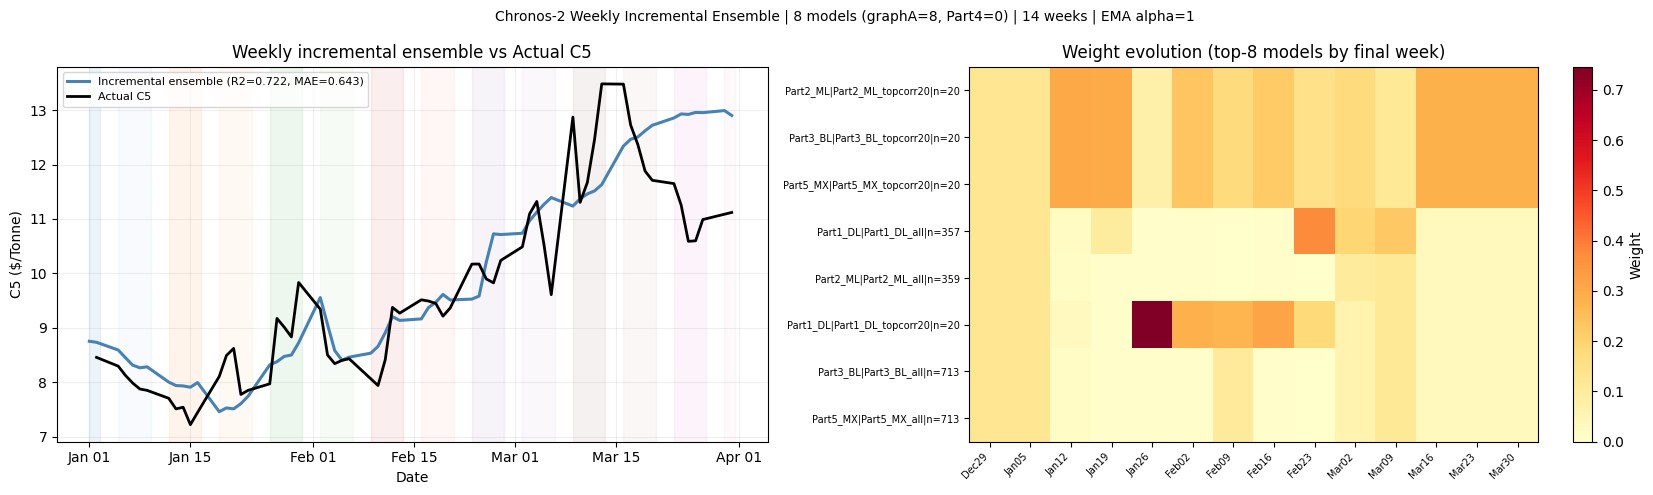

Saved: chronos2_ensemble_weekly_incremental__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Saved: chronos2_ensemble_weekly_weights__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Saved: chronos2_ensemble_final_weights__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.json

Per-week breakdown:
        Week       R2      MAE     n
      Jan 05  -3.6381   0.3538     5
      Jan 12  -8.6716   0.4704     5
      Jan 19  -3.6091   0.5990     5
      Jan 26  -0.3190   0.6236     5
      Feb 02   0.3962   0.2097     5
      Feb 09   0.4287   0.3977     5
      Feb 16  -4.3717   0.2071     5
      Feb 23  -12.8120   0.5837     5
      Mar 02  -1.1861   0.6201     5
      Mar 09  -1.2543   0.9400     5
      Mar 16  -0.4697   0.6576     5
      Mar 23  -22.42

In [9]:
# ── Weekly Incremental Ensemble: rolling weight update Jan–Mar 2026 ───────────
#
# Algorithm:
#   Week 0 prior: use Part 4 2025 inverse-MAE weights (no actuals yet)
#   For each forecast week W:
#     1. Compare last week's predictions vs actuals → compute per-model R²
#     2. Update weights: EMA blend of prior + new R²² weights
#     3. Apply updated weights to predict week W
#     4. Store predictions + weights used
#
# Config:
#   WEIGHT_EMA_ALPHA  — how quickly weights adapt (0=ignore new info, 1=full update)
#   MIN_ROWS_FOR_UPDATE — minimum actuals needed in a week to trigger update
#   WEIGHT_POWER      — R²^power weighting exponent
#   USE_RIDGE_META    — use RidgeCV meta-learner instead of R²-weighting
#
# Outputs:
#   chronos2_ensemble_weekly_incremental{TAG}.csv
#   chronos2_ensemble_weekly_weights{TAG}.csv
#   chronos2_ensemble_final_weights{TAG}.json
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import RidgeCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob, re
import json as _json

# ── Config ────────────────────────────────────────────────────────────────────
WEIGHT_EMA_ALPHA = 1     # Slow updates (was 1.0)
MIN_ROWS_FOR_UPDATE = 5   # Need more data (was 3)
USE_RIDGE_META = True     # Turn off Ridge (too complex for 14 weeks)   # minimum actual rows to trigger weight update
WEIGHT_POWER        = 1     # linear — quadratic amplifies noise with small n
USE_EXPANDING_WINDOW  = False  # True=all past actuals; False=rolling window
ROLLING_WINDOW_WEEKS  = 2      # when USE_EXPANDING_WINDOW=False, look back this many weeks
RIDGE_MIN_ROWS       = 10
RIDGE_FORCE_POSITIVE = True  # clip negative coefs — no model can hurt the blend

_tag = CHRONOS_FILE_TAG
_all_forecasts = {}
_forecast_src  = {}

# ── Load Graph A CSVs ─────────────────────────────────────────────────────────
_graphA_files = sorted(glob.glob(str(BASE_DIR / f"chronos2_dual_*_graphA{_tag}.csv")))
print(f"Graph A CSVs found: {len(_graphA_files)}")
for _f in _graphA_files:
    _pm = re.search(r"chronos2_dual_(Part\w+)_graphA", Path(_f).name)
    _pl = _pm.group(1) if _pm else Path(_f).stem
    _df = pd.read_csv(_f, parse_dates=["Date"])
    _df["Date"] = pd.to_datetime(_df["Date"]).dt.normalize()
    _df = _df.drop(columns=["C5_actual"], errors="ignore")
    for _col in _df.columns:
        if _col == "Date" or "log_C5" in _col:
            continue
        _label = f"{_pl}|{_col}"
        _all_forecasts[_label] = _df[["Date", _col]].rename(columns={_col: _label})
        _forecast_src[_label]  = "graphA"

# ── Load Part 4 forward 2026 CSV ──────────────────────────────────────────────
_p4_fwd_f = BASE_DIR / f"chronos2_dual_part4_fwd_2026_vs_actual_daily{_tag}.csv"
_p4_sum_f = BASE_DIR / f"chronos2_dual_part4_backtest2025_paired_summary{_tag}.csv"
_p4_mae_mult = {}
if _p4_fwd_f.is_file() and _p4_sum_f.is_file():
    _p4s = pd.read_csv(_p4_sum_f)
    _inv   = 1.0 / (_p4s["MAE_ensemble_invMAE"].values + 1e-9)
    _inv_n = _inv / _inv.mean()
    for _i2, _row2 in _p4s.iterrows():
        _p4_mae_mult[str(_row2["tag"])] = float(_inv_n[_i2])
    _p4f = pd.read_csv(_p4_fwd_f, parse_dates=["Date"])
    _p4f["Date"] = pd.to_datetime(_p4f["Date"]).dt.normalize()
    for _tg in _p4f["feature_set_tag"].astype(str).unique():
        _sub4 = (_p4f[_p4f["feature_set_tag"].astype(str) == _tg]
                 [["Date", "C5_pred_ensemble"]].copy()
                 .rename(columns={"C5_pred_ensemble": f"Part4|{_tg}"}))
        _label4 = f"Part4|{_tg}"
        _all_forecasts[_label4] = _sub4
        _forecast_src[_label4]  = "part4"
    print(f"  Part 4 columns: {sum(1 for s in _forecast_src.values() if s == 'part4')}")
else:
    print("  Part 4 fwd CSV not found — using Graph A only")

# ── Merge into wide frame: Jan–Mar 2026 ──────────────────────────────────────
_ENS_START = pd.Timestamp("2026-01-01")
_ENS_END   = pd.Timestamp("2026-03-31")
_all_dates = sorted(
    d for d in set.union(*[set(v["Date"]) for v in _all_forecasts.values()])
    if _ENS_START <= pd.Timestamp(d) <= _ENS_END
)
if not _all_dates:
    raise ValueError("No forecast dates in Jan-Mar 2026.")
print(f"  Window: {_all_dates[0].date()} to {_all_dates[-1].date()} ({len(_all_dates)} dates)")

_wide = pd.DataFrame({"Date": _all_dates})
for _lbl, _fdf in _all_forecasts.items():
    _wide = _wide.merge(_fdf, on="Date", how="left")
_wide = _wide.merge(actual_df, on="Date", how="left")
_wide = _wide.sort_values("Date").reset_index(drop=True)
_all_labels = [c for c in _wide.columns if c not in ("Date", "C5_actual")]
print(f"  Models: {len(_all_labels)}")

# ── Helper functions ──────────────────────────────────────────────────────────
def _get_boost(label):
    if _forecast_src.get(label) == "part4":
        return _p4_mae_mult.get(label.split("|", 1)[1], 1.0)
    return 1.0

def _r2_weights(r2_dict, power=WEIGHT_POWER):
    # No positive-only filter — inverse-MAE scores are always positive
    if not r2_dict:
        return {}
    raw  = {k: (v ** power) * _get_boost(k) for k, v in r2_dict.items() if v > 0}
    if not raw:
        return {}
    wsum = sum(raw.values())
    return {k: v / wsum for k, v in raw.items()}

MIN_MODEL_WEIGHT = 0.01   # no model ever drops below 1% weight

def _blend_weights(prior, new_wts, alpha):
    all_keys = set(prior) | set(new_wts)
    blended  = {k: (1 - alpha) * prior.get(k, 0.0) + alpha * new_wts.get(k, 0.0)
                for k in all_keys}
    # Apply floor so no model is completely suppressed
    blended  = {k: max(v, MIN_MODEL_WEIGHT) for k, v in blended.items()}
    wsum = sum(blended.values())
    return {k: v / wsum for k, v in blended.items()} if wsum > 0 else prior

def _apply_weights(row, weights):
    valid = [(lbl, w) for lbl, w in weights.items()
             if not pd.isna(row.get(lbl, np.nan))]
    if not valid:
        return np.nan
    wsum = sum(w for _, w in valid)
    return sum(row[lbl] * (w / wsum) for lbl, w in valid)

def _weekly_buckets(dates):
    buckets = []
    if not dates:
        return buckets
    cur_week   = []
    cur_monday = pd.Timestamp(dates[0]) - pd.Timedelta(days=pd.Timestamp(dates[0]).weekday())
    for d in dates:
        ts          = pd.Timestamp(d)
        week_monday = ts - pd.Timedelta(days=ts.weekday())
        if week_monday != cur_monday:
            if cur_week:
                buckets.append((cur_monday, cur_week))
            cur_week   = [ts]
            cur_monday = week_monday
        else:
            cur_week.append(ts)
    if cur_week:
        buckets.append((cur_monday, cur_week))
    return buckets

_weeks = _weekly_buckets(_all_dates)
print(f"  Weeks: {len(_weeks)}")

# ── Prior weights: Part 4 inverse-MAE ────────────────────────────────────────
_prior_raw = {lbl: _get_boost(lbl) for lbl in _all_labels}
_prior_sum  = sum(_prior_raw.values())
_current_weights = {k: v / _prior_sum for k, v in _prior_raw.items()}

# ── Weekly incremental loop ───────────────────────────────────────────────────
_ens_results    = []
_weight_history = []
_ridge_X_accum  = []
_ridge_y_accum  = []
_ridge_meta     = None
_col_means_stored = None

header = "  {:>2}  {:12}  {:>8}  {:12}  {}".format(
    "Wk", "Week of", "Actuals", "Update", "Top model (R²)"
)
print()
print(header)
print("-" * 78)

for _wi, (_wmon, _wdates) in enumerate(_weeks):
    _update_method = "prior" if _wi == 0 else "no update"

    # ── Evaluate last week to update weights ──────────────────────────────────
    if _wi > 0:
        # Use expanding window: all actuals seen so far (more stable than 1 week)
        _all_past_dates = [d for _, wdates in _weeks[:_wi] for d in wdates]
        if USE_EXPANDING_WINDOW:
            _eval_mask = _wide["Date"].isin(_all_past_dates)
        else:
            # Rolling window: use only the last ROLLING_WINDOW_WEEKS weeks
            _roll_start = max(0, _wi - int(ROLLING_WINDOW_WEEKS))
            _roll_dates = [d for _, wdates in _weeks[_roll_start:_wi] for d in wdates]
            _eval_mask = _wide["Date"].isin(_roll_dates)
        _prev_sub = _wide[_eval_mask].dropna(subset=["C5_actual"])

        if len(_prev_sub) >= MIN_ROWS_FOR_UPDATE:
            # Use inverse-MAE instead of R² — always positive, stable with small n
            _week_r2 = {}
            for _lbl in _all_labels:
                _ev2 = _prev_sub[["Date", _lbl, "C5_actual"]].dropna()
                if len(_ev2) < 2:
                    continue
                try:
                    _mae_v  = float(mean_absolute_error(_ev2["C5_actual"], _ev2[_lbl]))
                    _corr_v = float(_ev2["C5_actual"].corr(_ev2[_lbl]))
                    # Combined score: correlation rewards trend-tracking,
                    # inverse-MAE rewards level accuracy
                    # clip correlation to 0 so anti-correlated models get zero weight
                    _corr_v = max(_corr_v, 0.0)
                    _week_r2[_lbl] = _corr_v / (_mae_v + 1e-9)
                except Exception:
                    pass

            _new_weights = _r2_weights(_week_r2)
            if _new_weights:
                if USE_RIDGE_META and len(_ridge_X_accum) >= RIDGE_MIN_ROWS:
                    _X_m = np.array(_ridge_X_accum)
                    _y_m = np.array(_ridge_y_accum)
                    # Decay weights: recent rows count more (half-life ~10 rows ≈ 2 weeks)
                    _n_rows = len(_y_m)
                    _decay  = np.exp(-np.arange(_n_rows - 1, -1, -1) / 5.0)
                    _decay  = _decay / _decay.sum() * _n_rows
                    # Fill NaNs
                    _col_means = np.nanmean(_X_m, axis=0)
                    _col_means_stored = _col_means.copy()  # save for prediction
                    for _ci in range(_X_m.shape[1]):
                        _nan_mask = np.isnan(_X_m[:, _ci])
                        _X_m[_nan_mask, _ci] = _col_means[_ci]
                    # Decorrelate: fit residuals relative to the equal-weight mean
                    # This removes the shared trend component and forces Ridge to
                    # learn differential corrections between models
                    _equal_mean = _X_m.mean(axis=1, keepdims=True)
                    _X_m_resid  = _X_m - _equal_mean   # each col = deviation from ensemble mean
                    _y_m_resid  = _y_m - _equal_mean.squeeze()
                    _X_fit = _X_m_resid
                    _y_fit = _y_m_resid
                    _ridge_meta = RidgeCV(
                        alphas=[0.01, 0.1, 1.0, 10.0, 100.0],
                        fit_intercept=True,
                        cv=min(5, len(_y_m)),
                        scoring="neg_mean_absolute_error",
                    )
                    _ridge_meta.fit(_X_fit, _y_fit, sample_weight=_decay)
                    _coefs = _ridge_meta.coef_.copy()
                    if RIDGE_FORCE_POSITIVE:
                        _coefs = np.maximum(_coefs, 0)
                    _csum = _coefs.sum()
                    if _csum > 1e-9:
                        # Direct normalisation: let Ridge fully determine concentration
                        _raw_w  = {lbl: max(float(_coefs[i]), 0.0)
                                   for i, lbl in enumerate(_all_labels)}
                        # Apply minimum floor so no model is fully excluded
                        _raw_w  = {k: max(v, MIN_MODEL_WEIGHT) for k, v in _raw_w.items()}
                        _wsum_r = sum(_raw_w.values())
                        _current_weights = {k: v / _wsum_r for k, v in _raw_w.items()}
                        _update_method   = "Ridge(n={})".format(_n_rows)
                    else:
                        # All coefs zeroed — fall back to EMA
                        _current_weights = _blend_weights(
                            _current_weights, _new_weights, WEIGHT_EMA_ALPHA
                        )
                        _update_method = "EMA(Rdg0)"
                else:
                    _current_weights = _blend_weights(
                        _current_weights, _new_weights, WEIGHT_EMA_ALPHA
                    )
                    _update_method = "EMA"

                _top_lbl = max(_week_r2, key=lambda x: _week_r2[x]) if _week_r2 else "n/a"
                _top_r2v = _week_r2.get(_top_lbl, float("nan"))
                _short   = (_top_lbl
                            .replace("MasterLagged", "ML")
                            .replace("DeseasonLagged", "DL")
                            .replace("BothLagged", "BL"))
                _top_str = "{} (invMAE={:.3f})".format(_short[:35], _top_r2v)
                print("  {:>2}  {:12}  {:>8}  {:12}  {}".format(
                    _wi, _wmon.strftime("%b %d"), len(_prev_sub), _update_method, _top_str
                ))
            else:
                print("  {:>2}  {:12}  {:>8}  {:12}".format(
                    _wi, _wmon.strftime("%b %d"), len(_prev_sub), "no pos R2"
                ))
        else:
            print("  {:>2}  {:12}  {:>8}  {:12}".format(
                _wi, _wmon.strftime("%b %d"), len(_prev_sub), "< min rows"
            ))
    else:
        print("  {:>2}  {:12}  {:>8}  {:12}".format(
            _wi, _wmon.strftime("%b %d"), 0, "Part4 prior"
        ))

    # ── Apply weights: forecast this week ─────────────────────────────────────
    for _d in _wdates:
        _row_df = _wide[_wide["Date"] == _d]
        if _row_df.empty:
            continue
        _row_s = _row_df.iloc[0]

        if USE_RIDGE_META and _ridge_meta is not None and _col_means_stored is not None:
            # Get raw predictions; keep NaN markers for mean computation
            _x_raw      = np.array([float(_row_s.get(lbl, np.nan)) for lbl in _all_labels])
            _valid_mask = ~np.isnan(_x_raw)

            if _valid_mask.sum() == 0:
                _pred = _apply_weights(_row_s, _current_weights)
            else:
                # Equal-weight mean over valid values (anchors the reconstruction)
                _x_mean   = float(_x_raw[_valid_mask].mean())
                # Fill NaN positions with stored training column means
                _x_filled = _x_raw.copy()
                for _ci in range(len(_x_raw)):
                    if np.isnan(_x_filled[_ci]):
                        _x_filled[_ci] = _col_means_stored[_ci]
                # Apply same residual transform as Ridge training
                _x_resid      = (_x_filled - _x_mean).reshape(1, -1)
                _y_resid_pred = float(_ridge_meta.predict(_x_resid)[0])
                # Reconstruct: equal-weight mean + Ridge differential correction
                _pred = _x_mean + _y_resid_pred
        else:
            _pred = _apply_weights(_row_s, _current_weights)

        _actual_val = float(_row_s["C5_actual"]) if pd.notna(_row_s.get("C5_actual")) else np.nan
        _ens_results.append({
            "Date":          _d,
            "C5_ensemble":   _pred,
            "C5_actual":     _actual_val,
            "week":          _wmon.strftime("%Y-%m-%d"),
            "n_models_used": sum(1 for lbl in _current_weights
                                 if not pd.isna(_row_s.get(lbl, np.nan))),
        })

        if pd.notna(_actual_val):
            _ridge_X_accum.append([
                float(_row_s.get(lbl, 0.0) if not pd.isna(_row_s.get(lbl, np.nan)) else 0.0)
                for lbl in _all_labels
            ])
            _ridge_y_accum.append(_actual_val)

    _weight_history.append({
        "week": _wmon.strftime("%Y-%m-%d"),
        **{lbl: round(_current_weights.get(lbl, 0.0), 6) for lbl in _all_labels}
    })

# ── Output dataframe ──────────────────────────────────────────────────────────
_ens_df = pd.DataFrame(_ens_results)
_ens_df["Date"] = pd.to_datetime(_ens_df["Date"])

# ── Metrics ───────────────────────────────────────────────────────────────────
_ev_all = _ens_df.dropna(subset=["C5_ensemble", "C5_actual"])
_r2_ens  = float(r2_score(_ev_all["C5_actual"], _ev_all["C5_ensemble"])) if len(_ev_all) > 1 else float("nan")
_mae_ens = float(np.abs(_ev_all["C5_actual"] - _ev_all["C5_ensemble"]).mean()) if len(_ev_all) > 0 else float("nan")

_global_r2_cmp = {}
for _lbl in _all_labels:
    _ev_s2 = _wide[["Date", _lbl, "C5_actual"]].dropna()
    if len(_ev_s2) < 5:
        continue
    try:
        _global_r2_cmp[_lbl] = float(r2_score(_ev_s2["C5_actual"], _ev_s2[_lbl]))
    except Exception:
        pass
_best_k  = max(_global_r2_cmp, key=lambda x: _global_r2_cmp[x]) if _global_r2_cmp else "N/A"
_best_r2 = _global_r2_cmp.get(_best_k, float("nan"))

print()
print("-" * 60)
print("Incremental ensemble  R2={:.4f}  MAE={:.4f}  n={}".format(_r2_ens, _mae_ens, len(_ev_all)))
print("Best single model     R2={:.4f}  {}".format(_best_r2, _best_k[:60]))
print("Delta vs best         dR2={:+.4f}".format(_r2_ens - _best_r2))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

ax = axes[0]
_week_colors = plt.cm.tab20.colors
for _wi2, (_wmon2, _wdates2) in enumerate(_weeks):
    ax.axvspan(_wdates2[0], _wdates2[-1] + pd.Timedelta(hours=12),
               alpha=0.08, color=_week_colors[_wi2 % 20])
ax.plot(_ens_df["Date"], _ens_df["C5_ensemble"],
        color="steelblue", linewidth=2.2,
        label="Incremental ensemble (R2={:.3f}, MAE={:.3f})".format(_r2_ens, _mae_ens),
        zorder=5)
_act_plot = _ens_df.dropna(subset=["C5_actual"])
ax.plot(_act_plot["Date"], _act_plot["C5_actual"],
        color="black", linewidth=2.0, label="Actual C5", zorder=6)
ax.set_title("Weekly incremental ensemble vs Actual C5")
ax.set_xlabel("Date")
ax.set_ylabel("C5 ($/Tonne)")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

ax2 = axes[1]
_wt_df   = pd.DataFrame(_weight_history).set_index("week")
_top8    = _wt_df.iloc[-1].nlargest(8).index.tolist()
_wt_top  = _wt_df[_top8].T
_short_names = [
    c.replace("MasterLagged", "ML").replace("DeseasonLagged", "DL")
     .replace("BothLagged", "BL").replace("MergedXGB", "MX")[:38]
    for c in _top8
]
_im = ax2.imshow(_wt_top.values, aspect="auto", cmap="YlOrRd",
                 vmin=0, vmax=max(_wt_top.values.max(), 1e-6))
ax2.set_xticks(range(len(_wt_top.columns)))
ax2.set_xticklabels(
    [pd.Timestamp(w).strftime("%b%d") for w in _wt_top.columns],
    rotation=45, ha="right", fontsize=7
)
ax2.set_yticks(range(len(_short_names)))
ax2.set_yticklabels(_short_names, fontsize=7)
plt.colorbar(_im, ax=ax2, label="Weight")
ax2.set_title("Weight evolution (top-8 models by final week)")

_n_ga = sum(1 for s in _forecast_src.values() if s == "graphA")
_n_p4 = sum(1 for s in _forecast_src.values() if s == "part4")
plt.suptitle(
    "Chronos-2 Weekly Incremental Ensemble | {} models (graphA={}, Part4={}) | "
    "{} weeks | EMA alpha={}".format(len(_all_labels), _n_ga, _n_p4, len(_weeks), WEIGHT_EMA_ALPHA),
    fontsize=10
)
plt.tight_layout()
plt.show()

# ── Save outputs ──────────────────────────────────────────────────────────────
_out_ens = BASE_DIR / "chronos2_ensemble_weekly_incremental{}.csv".format(_tag)
_ens_df[["Date", "C5_ensemble", "C5_actual", "week", "n_models_used"]].to_csv(
    _out_ens, index=False
)
print("Saved: {}".format(_out_ens.name))

_out_wt = BASE_DIR / "chronos2_ensemble_weekly_weights{}.csv".format(_tag)
pd.DataFrame(_weight_history).to_csv(_out_wt, index=False)
print("Saved: {}".format(_out_wt.name))

_final_weights_json = {
    "weights":       {k: round(v, 6) for k, v in _current_weights.items()},
    "r2_ensemble":   round(_r2_ens, 5),
    "mae_ensemble":  round(_mae_ens, 5),
    "n_weeks":       len(_weeks),
    "ema_alpha":     WEIGHT_EMA_ALPHA,
}
_out_json = BASE_DIR / "chronos2_ensemble_final_weights{}.json".format(_tag)
with open(_out_json, "w") as _jf:
    _json.dump(_final_weights_json, _jf, indent=2)
print("Saved: {}".format(_out_json.name))

print()
print("Per-week breakdown:")
print("  {:>10}  {:>7}  {:>7}  {:>4}".format("Week", "R2", "MAE", "n"))
for _wmon3, _wdates3 in _weeks:
    _wlbl3 = _wmon3.strftime("%Y-%m-%d")
    _wsub3 = _ens_df[_ens_df["week"] == _wlbl3].dropna(subset=["C5_ensemble", "C5_actual"])
    if len(_wsub3) < 2:
        continue
    _wr2  = float(r2_score(_wsub3["C5_actual"], _wsub3["C5_ensemble"]))
    _wmae = float(np.abs(_wsub3["C5_actual"] - _wsub3["C5_ensemble"]).mean())
    print("  {:>10}  {:>7.4f}  {:>7.4f}  {:>4}".format(
        _wmon3.strftime("%b %d"), _wr2, _wmae, len(_wsub3)
    ))


Graph A CSVs found: 4
  Part 4 CSV not found — using Graph A only
  Window: 2026-01-01 to 2026-03-31 (64 dates)
  Models: 8
  Weeks: 14

Initial weights (top 5):
  Part1_DeseasonLagged|Part1_DeseasonLagged_all|n=357          0.1250
  Part1_DeseasonLagged|Part1_DeseasonLagged_topcorr20|n=20     0.1250
  Part2_MasterLagged|Part2_MasterLagged_all|n=359              0.1250
  Part2_MasterLagged|Part2_MasterLagged_topcorr20|n=20         0.1250
  Part3_BothLagged|Part3_BothLagged_all|n=713                  0.1250

WEEKLY ENSEMBLE
  Wk  Week of        Actuals  Update        Top model
--------------------------------------------------------------------------------
   0  Dec 29               0  Part4 prior 
   1  Jan 05               1  < min rows  
   2  Jan 12               6  EMA(n=6)      Part2_MasterLagged|Part2_MasterLagg (MAE=0.034)
   3  Jan 19              11  EMA(n=11)     Part2_MasterLagged|Part2_MasterLagg (MAE=0.205)
   4  Jan 26              16  EMA(n=16)     Part2_MasterLagged|Par

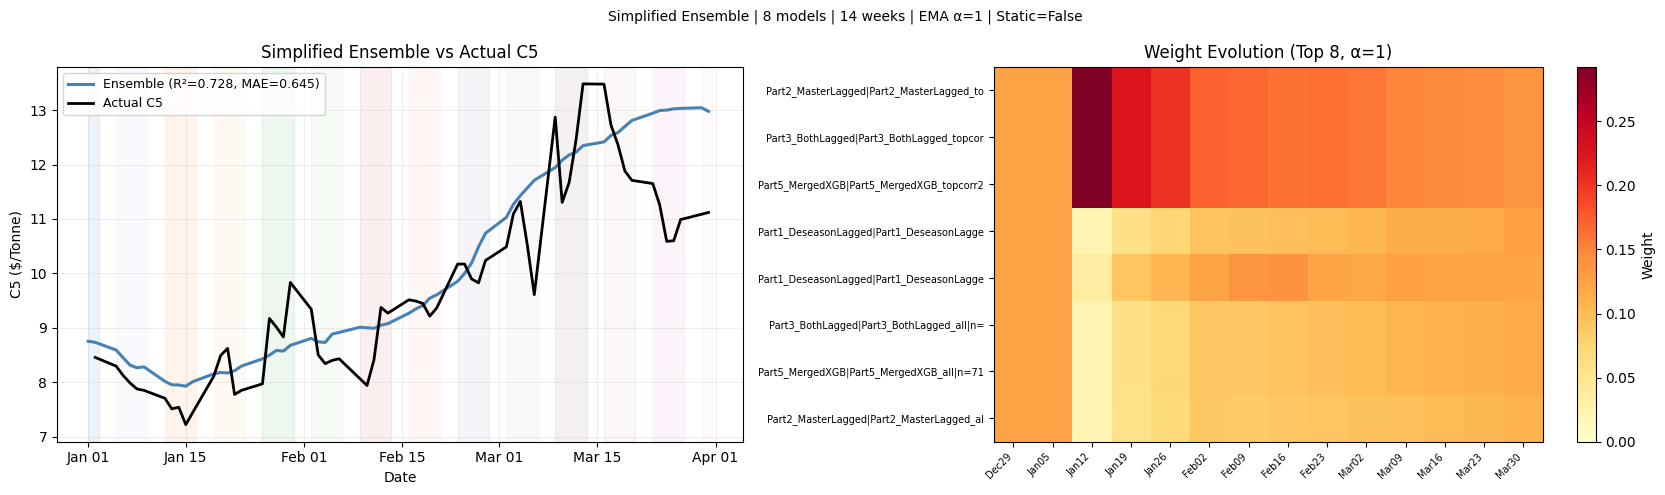


Saved: chronos2_ensemble_simplified__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Saved: chronos2_ensemble_weights_simplified__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv

Done!


In [10]:
# ── Simplified Weekly Ensemble (No Ridge dependency) ──────────────────────────

from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import re
import json as _json

# ── SIMPLIFIED CONFIG ─────────────────────────────────────────────────────────
WEIGHT_EMA_ALPHA = 1      # Slower updates (was 1.0 - too aggressive!)
MIN_ROWS_FOR_UPDATE = 5    # Need more data before updating
USE_STATIC_WEIGHTS = False  # True = use Part 4 weights only (most stable)

_tag = CHRONOS_FILE_TAG
_all_forecasts = {}
_forecast_src = {}

# ── Load Graph A CSVs ─────────────────────────────────────────────────────────
_graphA_files = sorted(glob.glob(str(BASE_DIR / f"chronos2_dual_*_graphA{_tag}.csv")))
print(f"Graph A CSVs found: {len(_graphA_files)}")

for _f in _graphA_files:
    _pm = re.search(r"chronos2_dual_(Part\w+)_graphA", Path(_f).name)
    _pl = _pm.group(1) if _pm else Path(_f).stem
    _df = pd.read_csv(_f, parse_dates=["Date"])
    _df["Date"] = pd.to_datetime(_df["Date"]).dt.normalize()
    _df = _df.drop(columns=["C5_actual"], errors="ignore")

    for _col in _df.columns:
        if _col == "Date" or "log_C5" in _col:
            continue
        _label = f"{_pl}|{_col}"
        _all_forecasts[_label] = _df[["Date", _col]].rename(columns={_col: _label})
        _forecast_src[_label] = "graphA"

# ── Load Part 4 forward 2026 CSV ──────────────────────────────────────────────
_p4_fwd_f = BASE_DIR / f"chronos2_dual_part4_fwd_2026_vs_actual_daily{_tag}.csv"
_p4_sum_f = BASE_DIR / f"chronos2_dual_part4_backtest2025_paired_summary{_tag}.csv"
_p4_mae_mult = {}

if _p4_fwd_f.is_file() and _p4_sum_f.is_file():
    _p4s = pd.read_csv(_p4_sum_f)
    _inv = 1.0 / (_p4s["MAE_ensemble_invMAE"].values + 1e-9)
    _inv_n = _inv / _inv.mean()

    for _i2, _row2 in _p4s.iterrows():
        _p4_mae_mult[str(_row2["tag"])] = float(_inv_n[_i2])

    _p4f = pd.read_csv(_p4_fwd_f, parse_dates=["Date"])
    _p4f["Date"] = pd.to_datetime(_p4f["Date"]).dt.normalize()

    for _tg in _p4f["feature_set_tag"].astype(str).unique():
        _sub4 = (_p4f[_p4f["feature_set_tag"].astype(str) == _tg]
                 [["Date", "C5_pred_ensemble"]].copy()
                 .rename(columns={"C5_pred_ensemble": f"Part4|{_tg}"}))
        _label4 = f"Part4|{_tg}"
        _all_forecasts[_label4] = _sub4
        _forecast_src[_label4] = "part4"

    print(f"  Part 4 columns: {sum(1 for s in _forecast_src.values() if s == 'part4')}")
else:
    print("  Part 4 CSV not found — using Graph A only")

# ── Merge into wide frame ─────────────────────────────────────────────────────
_ENS_START = pd.Timestamp("2026-01-01")
_ENS_END = pd.Timestamp("2026-03-31")

_all_dates = sorted(
    d for d in set.union(*[set(v["Date"]) for v in _all_forecasts.values()])
    if _ENS_START <= pd.Timestamp(d) <= _ENS_END
)

print(f"  Window: {_all_dates[0].date()} to {_all_dates[-1].date()} ({len(_all_dates)} dates)")

_wide = pd.DataFrame({"Date": _all_dates})
for _lbl, _fdf in _all_forecasts.items():
    _wide = _wide.merge(_fdf, on="Date", how="left")

_wide = _wide.merge(actual_df, on="Date", how="left")
_wide = _wide.sort_values("Date").reset_index(drop=True)
_all_labels = [c for c in _wide.columns if c not in ("Date", "C5_actual")]

print(f"  Models: {len(_all_labels)}")

# ── Helper functions ──────────────────────────────────────────────────────────
def _get_boost(label):
    if _forecast_src.get(label) == "part4":
        return _p4_mae_mult.get(label.split("|", 1)[1], 1.0)
    return 1.0

def _inverse_mae_weights(data, labels, power=1.0):
    """Calculate weights based on inverse MAE"""
    weights = {}

    for lbl in labels:
        subset = data[["C5_actual", lbl]].dropna()
        if len(subset) < 2:
            continue

        try:
            mae = mean_absolute_error(subset["C5_actual"], subset[lbl])
            # Inverse MAE weighted by Part 4 boost
            score = (1.0 / (mae + 0.01)) ** power * _get_boost(lbl)
            weights[lbl] = score
        except:
            continue

    # Normalize
    total = sum(weights.values())
    if total > 0:
        weights = {k: v / total for k, v in weights.items()}

    return weights

def _blend_weights(prior, new_wts, alpha):
    """Exponential moving average of weights"""
    all_keys = set(prior) | set(new_wts)
    blended = {k: (1 - alpha) * prior.get(k, 0.0) + alpha * new_wts.get(k, 0.0)
               for k in all_keys}
    total = sum(blended.values())
    return {k: v / total for k, v in blended.items()} if total > 0 else prior

def _apply_weights(row, weights):
    """Apply weights to get ensemble prediction"""
    valid = [(lbl, w) for lbl, w in weights.items()
             if not pd.isna(row.get(lbl, np.nan))]
    if not valid:
        return np.nan

    wsum = sum(w for _, w in valid)
    return sum(row[lbl] * (w / wsum) for lbl, w in valid)

def _weekly_buckets(dates):
    """Group dates into weekly buckets (Monday-Sunday)"""
    buckets = []
    if not dates:
        return buckets

    cur_week = []
    cur_monday = pd.Timestamp(dates[0]) - pd.Timedelta(days=pd.Timestamp(dates[0]).weekday())

    for d in dates:
        ts = pd.Timestamp(d)
        week_monday = ts - pd.Timedelta(days=ts.weekday())

        if week_monday != cur_monday:
            if cur_week:
                buckets.append((cur_monday, cur_week))
            cur_week = [ts]
            cur_monday = week_monday
        else:
            cur_week.append(ts)

    if cur_week:
        buckets.append((cur_monday, cur_week))

    return buckets

_weeks = _weekly_buckets(_all_dates)
print(f"  Weeks: {len(_weeks)}")

# ── Initialize weights ────────────────────────────────────────────────────────
# Start with Part 4 prior (inverse MAE from 2025 backtest)
_prior_raw = {lbl: _get_boost(lbl) for lbl in _all_labels}
_prior_sum = sum(_prior_raw.values())
_current_weights = {k: v / _prior_sum for k, v in _prior_raw.items()}

print(f"\nInitial weights (top 5):")
for lbl, wt in sorted(_current_weights.items(), key=lambda x: -x[1])[:5]:
    print(f"  {lbl[:60]:60s} {wt:.4f}")

# ── Weekly incremental loop ───────────────────────────────────────────────────
_ens_results = []
_weight_history = []

print("\n" + "="*80)
print("WEEKLY ENSEMBLE")
print("="*80)
print(f"  {'Wk':>2}  {'Week of':12}  {'Actuals':>8}  {'Update':12}  {'Top model'}")
print("-"*80)

for _wi, (_wmon, _wdates) in enumerate(_weeks):
    _update_method = "Part4 prior" if _wi == 0 else "no update"

    # ── Update weights based on past performance ──────────────────────────────
    if _wi > 0 and not USE_STATIC_WEIGHTS:
        # Get all past data (expanding window)
        _all_past_dates = [d for _, wdates in _weeks[:_wi] for d in wdates]
        _past_data = _wide[_wide["Date"].isin(_all_past_dates)].dropna(subset=["C5_actual"])

        if len(_past_data) >= MIN_ROWS_FOR_UPDATE:
            # Calculate new weights based on inverse MAE
            _new_weights = _inverse_mae_weights(_past_data, _all_labels)

            if _new_weights:
                # Blend with prior weights
                _current_weights = _blend_weights(_current_weights, _new_weights, WEIGHT_EMA_ALPHA)

                # Find best model
                _best_lbl = max(_new_weights, key=lambda x: _new_weights[x])
                _best_mae = mean_absolute_error(
                    _past_data["C5_actual"],
                    _past_data[_best_lbl]
                )

                _update_method = f"EMA(n={len(_past_data)})"
                _top_str = f"{_best_lbl[:35]} (MAE={_best_mae:.3f})"

                print(f"  {_wi:>2}  {_wmon.strftime('%b %d'):12}  {len(_past_data):>8}  {_update_method:12}  {_top_str}")
            else:
                print(f"  {_wi:>2}  {_wmon.strftime('%b %d'):12}  {len(_past_data):>8}  {'no weights':12}")
        else:
            print(f"  {_wi:>2}  {_wmon.strftime('%b %d'):12}  {len(_past_data):>8}  {'< min rows':12}")
    else:
        print(f"  {_wi:>2}  {_wmon.strftime('%b %d'):12}  {0:>8}  {_update_method:12}")

    # ── Apply current weights to forecast this week ───────────────────────────
    for _d in _wdates:
        _row_df = _wide[_wide["Date"] == _d]
        if _row_df.empty:
            continue

        _row = _row_df.iloc[0]
        _pred = _apply_weights(_row, _current_weights)
        _actual = float(_row["C5_actual"]) if pd.notna(_row.get("C5_actual")) else np.nan

        _ens_results.append({
            "Date": _d,
            "C5_ensemble": _pred,
            "C5_actual": _actual,
            "week": _wmon.strftime("%Y-%m-%d"),
        })

    # Store weight snapshot
    _weight_history.append({
        "week": _wmon.strftime("%Y-%m-%d"),
        **{lbl: round(_current_weights.get(lbl, 0.0), 6) for lbl in _all_labels}
    })

# ── Results ───────────────────────────────────────────────────────────────────
_ens_df = pd.DataFrame(_ens_results)
_ens_df["Date"] = pd.to_datetime(_ens_df["Date"])

# Calculate metrics
_eval = _ens_df.dropna(subset=["C5_ensemble", "C5_actual"])
_r2_ens = r2_score(_eval["C5_actual"], _eval["C5_ensemble"]) if len(_eval) > 1 else np.nan
_mae_ens = np.abs(_eval["C5_actual"] - _eval["C5_ensemble"]).mean() if len(_eval) > 0 else np.nan

# Compare to best single model
_best_r2 = -999
_best_model = "N/A"
for _lbl in _all_labels:
    _single = _wide[["C5_actual", _lbl]].dropna()
    if len(_single) >= 5:
        try:
            _r2 = r2_score(_single["C5_actual"], _single[_lbl])
            if _r2 > _best_r2:
                _best_r2 = _r2
                _best_model = _lbl
        except:
            pass

print("\n" + "="*80)
print("RESULTS")
print("="*80)
print(f"Ensemble:          R² = {_r2_ens:.4f}  |  MAE = {_mae_ens:.4f}  |  n = {len(_eval)}")
print(f"Best single model: R² = {_best_r2:.4f}  |  {_best_model[:50]}")
print(f"Delta:             ΔR² = {_r2_ens - _best_r2:+.4f}")
print("="*80)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left: Ensemble vs Actual
ax = axes[0]
_week_colors = plt.cm.tab20.colors

for _wi, (_wmon, _wdates) in enumerate(_weeks):
    ax.axvspan(_wdates[0], _wdates[-1] + pd.Timedelta(hours=12),
               alpha=0.08, color=_week_colors[_wi % 20])

ax.plot(_ens_df["Date"], _ens_df["C5_ensemble"],
        color="steelblue", linewidth=2.2,
        label=f"Ensemble (R²={_r2_ens:.3f}, MAE={_mae_ens:.3f})",
        zorder=5)

_act_plot = _ens_df.dropna(subset=["C5_actual"])
ax.plot(_act_plot["Date"], _act_plot["C5_actual"],
        color="black", linewidth=2.0, label="Actual C5", zorder=6)

ax.set_title("Simplified Ensemble vs Actual C5")
ax.set_xlabel("Date")
ax.set_ylabel("C5 ($/Tonne)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Right: Weight evolution
ax2 = axes[1]
_wt_df = pd.DataFrame(_weight_history).set_index("week")
_top8 = _wt_df.iloc[-1].nlargest(8).index.tolist()
_wt_top = _wt_df[_top8].T

_short_names = [c[:40] for c in _top8]

_im = ax2.imshow(_wt_top.values, aspect="auto", cmap="YlOrRd",
                 vmin=0, vmax=_wt_top.values.max())

ax2.set_xticks(range(len(_wt_top.columns)))
ax2.set_xticklabels(
    [pd.Timestamp(w).strftime("%b%d") for w in _wt_top.columns],
    rotation=45, ha="right", fontsize=7
)
ax2.set_yticks(range(len(_short_names)))
ax2.set_yticklabels(_short_names, fontsize=7)

plt.colorbar(_im, ax=ax2, label="Weight")
ax2.set_title(f"Weight Evolution (Top 8, α={WEIGHT_EMA_ALPHA})")

plt.suptitle(
    f"Simplified Ensemble | {len(_all_labels)} models | {len(_weeks)} weeks | "
    f"EMA α={WEIGHT_EMA_ALPHA} | Static={USE_STATIC_WEIGHTS}",
    fontsize=10
)
plt.tight_layout()
plt.show()

# ── Save outputs ──────────────────────────────────────────────────────────────
_out_ens = BASE_DIR / f"chronos2_ensemble_simplified{_tag}.csv"
_ens_df.to_csv(_out_ens, index=False)
print(f"\nSaved: {_out_ens.name}")

_out_wt = BASE_DIR / f"chronos2_ensemble_weights_simplified{_tag}.csv"
pd.DataFrame(_weight_history).to_csv(_out_wt, index=False)
print(f"Saved: {_out_wt.name}")

print("\nDone!")

╔═══════════════════════════════════════════════════════════════╗
║  Part 6: Ridge+NGBoost & Chronos+NGBoost Combinations        ║
╚═══════════════════════════════════════════════════════════════╝

✓ Ridge loaded: 62 rows
✓ NGBoost loaded: 62 rows

✓ Loaded Part2 graphA/graphB from files
✓ Found 22 Chronos models

Sample values from 'Part2_MasterLagged_all|n=359':
  Range: 8.54 to 13.10
  (Should be in USD/tonne range, e.g., 8-25)

Creating Ridge + NGBoost combination...
✓ Ridge+NGBoost created  Range: 7.66 to 10.82

Creating Chronos+NGBoost combinations for 22 models...
✓ Computed NGBoost residual  std: 0.398
✓ Created 22 Chronos+NGBoost combinations

Assembling master forecast dataframe...
✓ Added Part 5 Weekly Ensemble from '_ens_df'
✓ Master forecast dataframe assembled (pre-injection)

── Selecting best Chronos model (Top-5 injection) ──────────────────────
  Top-5 winner 'Part1_DeseasonLagged_all|n=357' not in master_forecasts — searching CSVs
  Injected 'Part1_DeseasonLagged_all

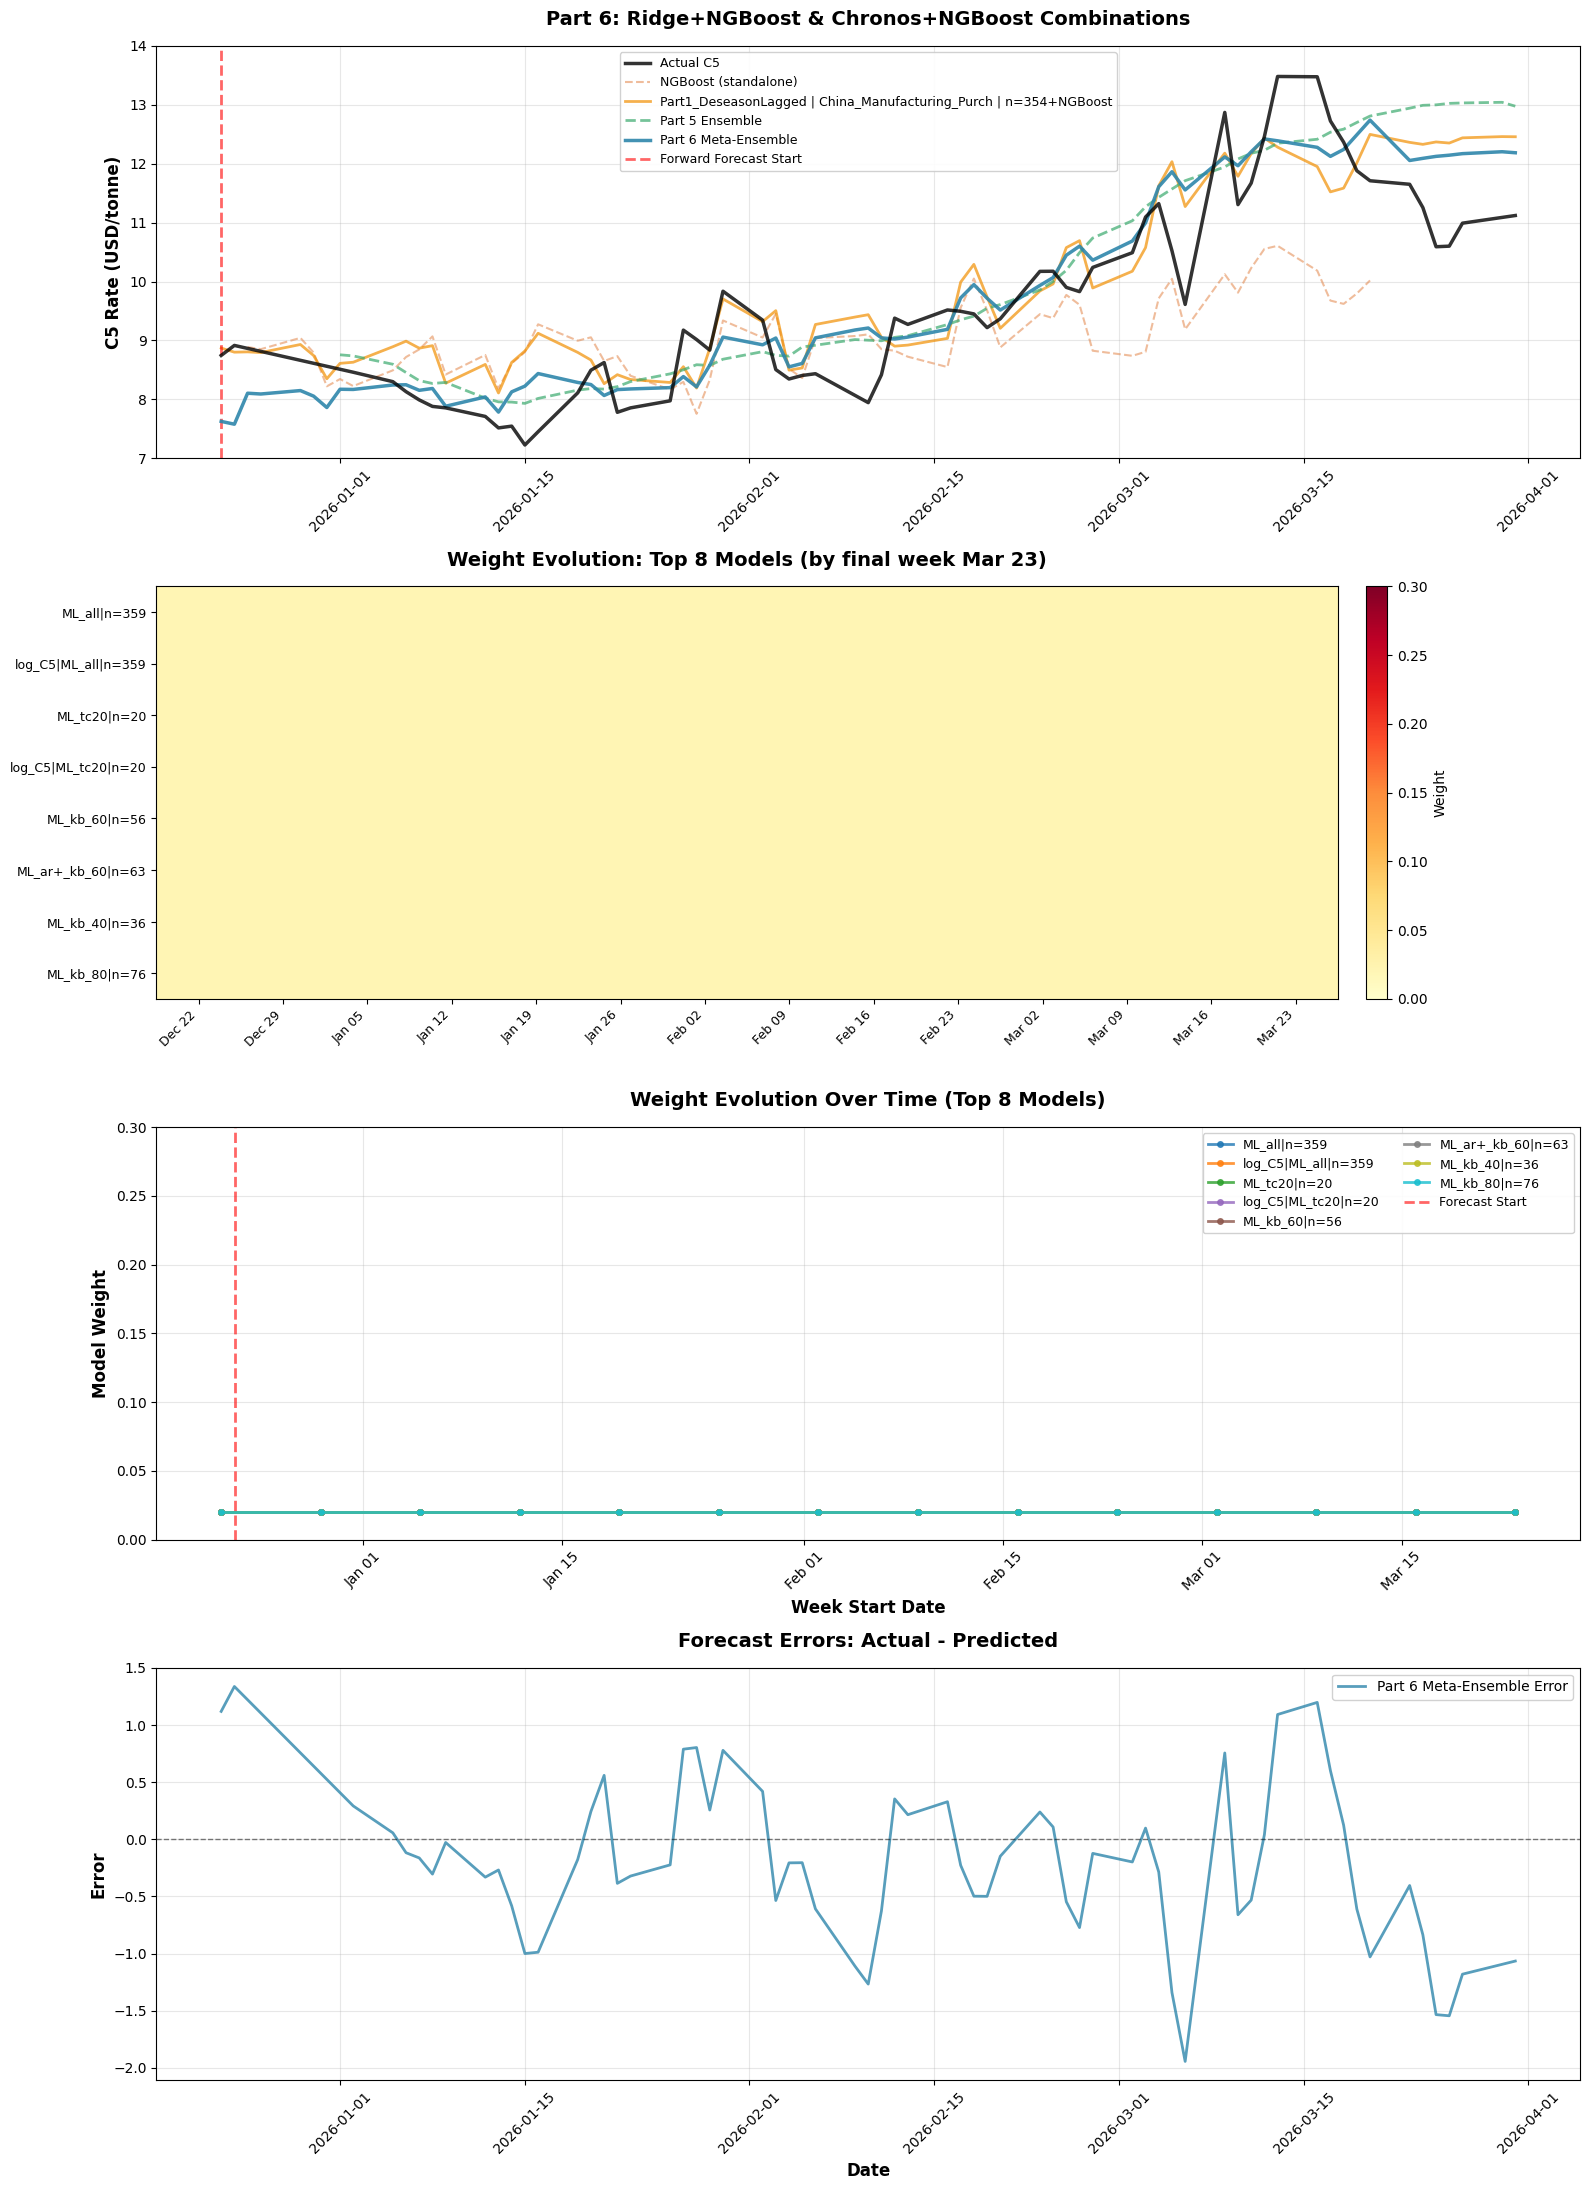


✓ Saved ensemble to: /content/drive/MyDrive/Project 005 Data/chronos2_part6_weekly_ensemble__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
✓ Saved weight history to: /content/drive/MyDrive/Project 005 Data/chronos2_part6_weight_history__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
✓ Saved final weights to: /content/drive/MyDrive/Project 005 Data/chronos2_part6_final_weights__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.json

╔═══════════════════════════════════════════════════════════════╗
║  Part 6 Complete                                             ║
╚═══════════════════════════════════════════════════════════════╝


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# Part 6: Ridge+NGBoost & Chronos+NGBoost Residual Combinations + Weekly Ensemble
# ═══════════════════════════════════════════════════════════════════════════════
#
# Add this cell to chronos2_dual notebook after the existing ensemble section
#
# Prerequisites (should already exist in your notebook):
# - Part2 graphA and graphB dataframes loaded
# - BASE_DIR, CHRONOS_FILE_TAG defined
# - BACKTEST_2025_START, BACKTEST_2025_END, FORECAST_START defined
#
# This creates:
# 1. Ridge (trend) + NGBoost (weighted blend) combined forecast
# 2. Chronos models (trend) + NGBoost (weighted blend) combined forecasts
# 3. Weekly incremental ensemble of ALL forecasts (including Part 5 ensemble if available)
#    with adaptive weights based on cumulative backtest performance
#
# ─────────────────────────────────────────────────────────────────────────────
# HOW CHRONOS+NGBOOST IS CONSTRUCTED:
# ─────────────────────────────────────────────────────────────────────────────
#
# NGBoost predictions contain full C5 forecasts (8-13 USD/tonne range).
#
# Step 1: Calculate NGBoost rolling average (5-day window for business days)
#   NGBoost_MA = rolling_mean(NGBoost, window=5)
#
# Step 2: Extract residual (fluctuations above/below the rolling average)
#   NGBoost_residual = NGBoost - NGBoost_MA
#   Example: If NGBoost=9.5 and MA=9.2, residual=+0.3
#
# Step 3: Add residual to Chronos trend
#   Chronos+NGBoost = Chronos_trend + NGBoost_residual
#
# Example:
#   - Chronos predicts: 10.5 USD/tonne (trend)
#   - NGBoost: 9.5 USD/tonne
#   - NGBoost 5-day MA: 9.2 USD/tonne
#   - NGBoost residual: +0.3 (short-term fluctuation)
#   - Chronos+NGBoost = 10.5 + 0.3 = 10.8 USD/tonne
#
# This captures:
#   - Chronos provides the base trend
#   - NGBoost residual adds short-term fluctuation patterns
#   - Meta-ensemble will down-weight if residual adds noise instead of signal
#
# ─────────────────────────────────────────────────────────────────────────────
# EXPANDING WINDOW BACKTESTING STRATEGY (matches Part 5):
# ─────────────────────────────────────────────────────────────────────────────
#
# Week 1: Apply EQUAL weights (1/N for each of N models)
# Week 2: Backtest on ALL PAST DATA (week 1) → rebalance weights for week 2
# Week 3: Backtest on ALL PAST DATA (weeks 1-2) → rebalance weights for week 3
# Week N: Backtest on ALL PAST DATA (weeks 1 to N-1) → rebalance weights for week N
#
# Scoring metric (like Part 5):
#   score = correlation / MAE
#   - Correlation rewards trend-tracking (clipped to 0 for anti-correlated)
#   - Inverse-MAE rewards level accuracy
#   - More stable than R² with small sample sizes
#
# This expanding window approach uses all available historical performance data
# to determine optimal weights, making the system more stable and data-efficient.
# ═══════════════════════════════════════════════════════════════════════════════

print("╔═══════════════════════════════════════════════════════════════╗")
print("║  Part 6: Ridge+NGBoost & Chronos+NGBoost Combinations        ║")
print("╚═══════════════════════════════════════════════════════════════╝\n")

import json  # For saving final weights
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─── Configuration ────────────────────────────────────────────────────────────
RIDGE_CSV = BASE_DIR / "c5_forecast_62days.csv"
NGBOOST_CSV = BASE_DIR / "c5_forecast_62days_ngboost.csv"

# Weekly ensemble parameters
WEIGHT_EMA_ALPHA_P6 = 0.3
MIN_ROWS_UPDATE_P6 = 3
WEIGHT_POWER_P6 = 2

# ─── Load Ridge and NGBoost ───────────────────────────────────────────────────
ridge_df = pd.read_csv(RIDGE_CSV)
ridge_df['Date'] = pd.to_datetime(ridge_df['date'])

ngboost_df = pd.read_csv(NGBOOST_CSV)
ngboost_df['Date'] = pd.to_datetime(ngboost_df['date'])

print(f"✓ Ridge loaded: {ridge_df.shape[0]} rows")
print(f"✓ NGBoost loaded: {ngboost_df.shape[0]} rows\n")

# ─── Load Part2 Chronos Outputs (use existing dataframes if available) ────────
_tag = CHRONOS_FILE_TAG

try:
    if 'graphA_p2' in dir() and 'graphB_p2' in dir():
        chronos_all = graphA_p2.merge(graphB_p2, on='Date', how='outer',
                                      suffixes=('', '_b'))
        print("✓ Using existing Part2 graphA/graphB dataframes")
    else:
        graphA_p2 = pd.read_csv(BASE_DIR / f"chronos2_dual_Part2_MasterLagged_graphA{_tag}.csv",
                                parse_dates=['Date'])
        graphB_p2 = pd.read_csv(BASE_DIR / f"chronos2_dual_Part2_MasterLagged_graphB{_tag}.csv",
                                parse_dates=['Date'])
        chronos_all = graphA_p2.merge(graphB_p2, on='Date', how='outer',
                                      suffixes=('', '_b'))
        print("✓ Loaded Part2 graphA/graphB from files")
except Exception as e:
    print(f"⚠ Could not load Part2 Chronos data: {e}")
    raise

# Get Chronos model columns (exclude any actuals that leaked in via merge suffix)
chronos_model_cols = [
    c for c in chronos_all.columns
    if c not in ['Date', 'C5_actual']
    and 'actual' not in c.lower()
]

print(f"✓ Found {len(chronos_model_cols)} Chronos models")

sample_col = chronos_model_cols[0]
print(f"\nSample values from '{sample_col}':")
print(f"  Range: {chronos_all[sample_col].min():.2f} to {chronos_all[sample_col].max():.2f}")
print(f"  (Should be in USD/tonne range, e.g., 8-25)\n")

# ─── 1. Create Ridge + NGBoost Combined Forecast ──────────────────────────────
print("Creating Ridge + NGBoost combination...")

NGBOOST_ROLLING_WINDOW = 5
ngboost_with_date = ngboost_df.set_index('Date')['C5_point']
ngboost_rolling_avg = ngboost_with_date.rolling(
    window=NGBOOST_ROLLING_WINDOW,
    min_periods=1
).mean()
ngboost_residual = ngboost_with_date - ngboost_rolling_avg

ridge_ngboost = ridge_df[['Date', 'C5_point']].copy()
ridge_ngboost = ridge_ngboost.merge(ngboost_df[['Date']], on='Date', how='outer')
ridge_ngboost['Ridge+NGBoost'] = (
    ridge_ngboost['C5_point'].fillna(0) +
    ngboost_residual.reindex(ridge_ngboost['Date']).fillna(0).values
)
ridge_ngboost = ridge_ngboost[['Date', 'Ridge+NGBoost']]
print(f"✓ Ridge+NGBoost created  Range: {ridge_ngboost['Ridge+NGBoost'].min():.2f} to {ridge_ngboost['Ridge+NGBoost'].max():.2f}\n")

# ─── 2. Create Chronos + NGBoost for Each Chronos Model ───────────────────────
print(f"Creating Chronos+NGBoost combinations for {len(chronos_model_cols)} models...")

ngboost_rolling_avg = ngboost_df.set_index('Date')['C5_point'].rolling(
    window=NGBOOST_ROLLING_WINDOW,
    min_periods=1
).mean()
ngboost_residual = ngboost_df.set_index('Date')['C5_point'] - ngboost_rolling_avg

print(f"✓ Computed NGBoost residual  std: {ngboost_residual.std():.3f}")

chronos_ngboost = chronos_all[['Date']].copy()
ngboost_residual_aligned = ngboost_residual.reindex(chronos_all['Date']).fillna(0).values

for col in chronos_model_cols:
    combined_col = f"{col}+NGBoost"
    chronos_ngboost[combined_col] = (
        chronos_all[col].fillna(0) + ngboost_residual_aligned
    )

print(f"✓ Created {len(chronos_model_cols)} Chronos+NGBoost combinations\n")

# ─── 3. Assemble Master Forecast DataFrame ────────────────────────────────────
print("Assembling master forecast dataframe...")

master_forecasts = chronos_all.copy()

ridge_standalone = ridge_df[['Date', 'C5_point']].copy().rename(
    columns={'C5_point': 'Ridge_standalone'})
master_forecasts = master_forecasts.merge(ridge_standalone, on='Date', how='outer')

ngboost_standalone = ngboost_df[['Date', 'C5_point']].copy().rename(
    columns={'C5_point': 'NGBoost_standalone'})
master_forecasts = master_forecasts.merge(ngboost_standalone, on='Date', how='outer')

master_forecasts = master_forecasts.merge(ridge_ngboost, on='Date', how='outer')
master_forecasts = master_forecasts.merge(chronos_ngboost, on='Date', how='outer')

# Add Part 5 ensemble if available
part5_loaded = False
try:
    if '_ens_df' in dir() and 'C5_ensemble' in _ens_df.columns:
        prev_ensemble = _ens_df[['Date', 'C5_ensemble']].copy().rename(
            columns={'C5_ensemble': 'Part5_WeeklyEnsemble'})
        master_forecasts = master_forecasts.merge(prev_ensemble, on='Date', how='outer')
        print("✓ Added Part 5 Weekly Ensemble from '_ens_df'")
        part5_loaded = True

    if not part5_loaded:
        for var_name in ['final_ensemble_df', 'ensemble_df_weekly', 'weekly_incremental_df']:
            if var_name in dir() and var_name in globals():
                df_temp = globals()[var_name]
                if isinstance(df_temp, pd.DataFrame):
                    for col_name in ['weekly_ensemble', 'C5_ensemble']:
                        if col_name in df_temp.columns:
                            prev_ensemble = df_temp[['Date', col_name]].copy().rename(
                                columns={col_name: 'Part5_WeeklyEnsemble'})
                            master_forecasts = master_forecasts.merge(
                                prev_ensemble, on='Date', how='outer')
                            print(f"✓ Added Part 5 Weekly Ensemble from '{var_name}'")
                            part5_loaded = True
                            break
            if part5_loaded:
                break

    if not part5_loaded:
        csv_patterns = [
            f"chronos2_ensemble_weekly_incremental{CHRONOS_FILE_TAG}.csv",
            "chronos2_ensemble_weekly_incremental__from_Transformed_Deseason_Residual_Browian__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv",
            "chronos2_ensemble_weekly_incremental.csv",
            f"chronos2_part5_weekly_ensemble{CHRONOS_FILE_TAG}.csv",
        ]
        for pattern in csv_patterns:
            prev_csv = BASE_DIR / pattern
            if prev_csv.is_file():
                prev_df = pd.read_csv(prev_csv, parse_dates=['Date'])
                for col_name in ['C5_ensemble', 'weekly_ensemble']:
                    if col_name in prev_df.columns:
                        prev_ensemble = prev_df[['Date', col_name]].copy().rename(
                            columns={col_name: 'Part5_WeeklyEnsemble'})
                        master_forecasts = master_forecasts.merge(
                            prev_ensemble, on='Date', how='outer')
                        print(f"✓ Loaded Part 5 Weekly Ensemble from '{pattern}'")
                        part5_loaded = True
                        break
            if part5_loaded:
                break

    if not part5_loaded:
        print("  ⚠ Part 5 Weekly Ensemble not found — will continue without it")

except Exception as e:
    print(f"  Could not load Part 5 ensemble: {e}")
    part5_loaded = False

# Add actuals
if 'C5_actual' not in master_forecasts.columns or master_forecasts['C5_actual'].isna().all():
    if 'C5_actual' in ridge_df.columns:
        actual_data = ridge_df[['Date', 'C5_actual']].dropna()
        master_forecasts = master_forecasts.merge(actual_data, on='Date', how='left')

master_forecasts = master_forecasts.sort_values('Date').reset_index(drop=True)

print("✓ Master forecast dataframe assembled (pre-injection)")

# ─── 3b. Inject Top-5 Winner into master_forecasts (BEFORE all_model_cols) ────
# This MUST happen before all_model_cols is rebuilt so the injected model
# participates in ensemble weighting and appears in the evaluation table.
print("\n── Selecting best Chronos model (Top-5 injection) ──────────────────────")

best_chronos    = None
best_chronos_r2 = -999

try:
    _top5_col = top5.index[0]
    _top5_r2  = float(top5.iloc[0]["R2"])

    if _top5_col in master_forecasts.columns and 'actual' not in _top5_col.lower():
        best_chronos    = _top5_col
        best_chronos_r2 = _top5_r2
        print(f"best_chronos from Top-5 (already in master): '{best_chronos}'  R²={best_chronos_r2:.4f}")
    else:
        print(f"  Top-5 winner '{_top5_col}' not in master_forecasts — searching CSVs")
        _graph_files = sorted(BASE_DIR.glob(f"chronos2_dual_*graph*{CHRONOS_FILE_TAG}.csv"))
        _graph_files += [BASE_DIR / f"chronos2_dual_part4_fwd_2026_vs_actual_daily{CHRONOS_FILE_TAG}.csv"]
        for _fp in _graph_files:
            if not _fp.is_file():
                continue
            _tmp = pd.read_csv(_fp, parse_dates=["Date"])
            _tmp["Date"] = pd.to_datetime(_tmp["Date"]).dt.normalize()
            if _top5_col in _tmp.columns:
                _inj = _tmp[["Date", _top5_col]].drop_duplicates("Date")
                master_forecasts = master_forecasts.merge(_inj, on="Date", how="left")

                # Build +NGBoost variant for the injected model
                _ngb_col = _top5_col + "+NGBoost"
                if _ngb_col not in chronos_ngboost.columns:
                    _res_aligned = ngboost_residual.reindex(
                        master_forecasts.set_index("Date").index
                    ).fillna(0).values
                    chronos_ngboost[_ngb_col] = (
                        master_forecasts[_top5_col].fillna(0) + _res_aligned
                    )
                # Merge the new +NGBoost column into master_forecasts
                if _ngb_col not in master_forecasts.columns:
                    master_forecasts = master_forecasts.merge(
                        chronos_ngboost[["Date", _ngb_col]], on="Date", how="left"
                    )

                best_chronos    = _top5_col
                best_chronos_r2 = _top5_r2
                print(f"  Injected '{_top5_col}' from {_fp.name}  R²={best_chronos_r2:.4f}")
                break

        if best_chronos is None:
            print(f"  '{_top5_col}' not found in any CSV — will use fallback")

except Exception as _e:
    print(f"  top5 not available ({_e}) — using fallback")

# Fallback: search columns already in master_forecasts (no injection needed)
if best_chronos is None:
    _fb_eval = master_forecasts[master_forecasts["C5_actual"].notna()].copy()
    _fb_cols = [
        c for c in master_forecasts.columns
        if c not in ("Date", "C5_actual")
        and "actual"   not in c.lower()
        and "NGBoost"  not in c
        and "Ridge"    not in c
        and "ensemble" not in c.lower()
    ]
    for col in _fb_cols:
        _v = _fb_eval[[col, "C5_actual"]].dropna()
        if len(_v) < 5:
            continue
        try:
            _r2 = float(r2_score(_v["C5_actual"], _v[col]))
            if _r2 > best_chronos_r2:
                best_chronos_r2 = _r2
                best_chronos    = col
        except:
            pass
    if best_chronos:
        print(f"best_chronos fallback: '{best_chronos}'  R²={best_chronos_r2:.4f}")

# ─── 3c. Rebuild all_model_cols AFTER injection ───────────────────────────────
# Must be done here so injected column + its +NGBoost variant are included
all_model_cols = [
    c for c in master_forecasts.columns
    if c not in ['Date', 'C5_actual']
    and 'actual' not in c.lower()
]

print(f"\n╔═══════════════════════════════════════════════════════════════╗")
print(f"║  Master Forecast DataFrame                                   ║")
print(f"╚═══════════════════════════════════════════════════════════════╝")
print(f"  Total models: {len(all_model_cols)}")
print(f"    - Original Chronos (Part2): {len(chronos_model_cols)}")
print(f"    - Ridge (standalone): 1")
print(f"    - NGBoost (standalone): 1")
print(f"    - Ridge+NGBoost blend: 1")
_ng_count = len([c for c in all_model_cols if c.endswith('+NGBoost')])
print(f"    - Chronos+NGBoost blends: {_ng_count}")
if 'Part5_WeeklyEnsemble' in all_model_cols:
    print(f"    - Part 5 Weekly Ensemble: 1")
if best_chronos and best_chronos not in chronos_model_cols:
    print(f"    - Injected Top-5 winner: 1  ('{best_chronos[:60]}')")
print(f"  Date range: {master_forecasts['Date'].min().date()} → {master_forecasts['Date'].max().date()}")
print(f"  Actuals: {master_forecasts['C5_actual'].notna().sum()} rows\n")


# ─── 4. Weekly Incremental Ensemble (Adaptive Weights) ────────────────────────
def weekly_incremental_ensemble_p6(df, model_cols, backtest_start, backtest_end,
                                   forward_start, alpha, min_rows, power):
    """
    Weekly walk-forward ensemble with adaptive R²-based weights.
    Same algorithm as Part 5, applied to expanded model set.
    """
    df = df.copy().sort_values('Date').reset_index(drop=True)

    current_weights = {col: 1/len(model_cols) for col in model_cols}
    print(f"Week 1: Using equal weights (1/{len(model_cols)} = {1/len(model_cols):.4f} per model)")

    weight_history = []

    df['week_start'] = df['Date'].dt.to_period('W').dt.start_time
    all_period_df = df[
        (df['Date'] >= backtest_start) &
        (df['Date'] <= forward_start + pd.Timedelta(days=90))
    ]

    weeks = []
    for week_start in sorted(all_period_df['week_start'].unique()):
        week_dates = all_period_df[all_period_df['week_start'] == week_start]['Date'].tolist()
        weeks.append((week_start, week_dates))

    backtest_weeks = sum(1 for ws, _ in weeks if ws <= backtest_end)

    print(f"\n✓ Processing {len(weeks)} weeks total ({backtest_weeks} backtest + {len(weeks)-backtest_weeks} forward)...")

    for week_idx, (week_start, week_dates) in enumerate(weeks):
        week_data = df[df['Date'].isin(week_dates)].copy()

        week_data['weekly_ensemble'] = 0
        for col in model_cols:
            if col in week_data.columns:
                week_data['weekly_ensemble'] += (
                    current_weights.get(col, 0) * week_data[col].fillna(0)
                )

        df.loc[week_data.index, 'weekly_ensemble'] = week_data['weekly_ensemble']

        week_actuals = week_data[week_data['C5_actual'].notna()]
        is_backtest_week = week_start <= backtest_end

        if week_idx > 0 and is_backtest_week:
            all_past_dates = [d for _, wdates in weeks[:week_idx] for d in wdates]
            prior_data = df[df['Date'].isin(all_past_dates) & df['C5_actual'].notna()]

            if len(prior_data) >= min_rows:
                scores = {}
                for col in model_cols:
                    if col in prior_data.columns:
                        try:
                            valid_mask = prior_data[col].notna()
                            if valid_mask.sum() >= min_rows:
                                actuals = prior_data.loc[valid_mask, 'C5_actual']
                                preds   = prior_data.loc[valid_mask, col]
                                mae_val  = mean_absolute_error(actuals, preds)
                                corr_val = max(actuals.corr(preds), 0.0)
                                scores[col] = corr_val / (mae_val + 1e-9)
                            else:
                                scores[col] = 1e-9
                        except:
                            scores[col] = 1e-9

                powered = {k: v**power for k, v in scores.items()}
                total   = sum(powered.values())
                if total > 1e-9:
                    new_weights = {k: v/total for k, v in powered.items()}
                    updated_weights = {
                        col: (alpha * new_weights[col] +
                              (1 - alpha) * current_weights.get(col, 1/len(model_cols)))
                        for col in model_cols if col in new_weights
                    }
                    total = sum(updated_weights.values())
                    current_weights = {k: v/total for k, v in updated_weights.items()}

                    if (week_idx + 1) % 5 == 0 or week_idx == len(weeks) - 1:
                        print(f"  Week {week_idx+1}/{len(weeks)}: Rebalanced using {len(prior_data)} cumulative actuals")

        weight_record = {
            'week_start': week_start,
            'week_idx':   week_idx,
            'n_actuals':  len(week_actuals)
        }
        for col in model_cols:
            weight_record[f'{col}_weight'] = current_weights.get(col, 0)
        weight_history.append(weight_record)

    # Apply final weights to forward period
    forward_df = df[df['Date'] >= forward_start].copy()
    forward_df['weekly_ensemble'] = 0
    for col in model_cols:
        if col in forward_df.columns:
            forward_df['weekly_ensemble'] += (
                current_weights.get(col, 0) * forward_df[col].fillna(0)
            )
    df.loc[forward_df.index, 'weekly_ensemble'] = forward_df['weekly_ensemble']

    print(f"\n✓ Weekly ensemble complete")
    print(f"\nTop 10 final weights:")
    for col, w in sorted(current_weights.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"  {col[:70]}: {w:.4f}")

    return df, pd.DataFrame(weight_history), current_weights


# Run weekly ensemble
ensemble_df, weight_history_df, final_weights = weekly_incremental_ensemble_p6(
    df=master_forecasts,
    model_cols=all_model_cols,
    backtest_start=BACKTEST_2025_START,
    backtest_end=BACKTEST_2025_END,
    forward_start=FORECAST_START,
    alpha=WEIGHT_EMA_ALPHA_P6,
    min_rows=MIN_ROWS_UPDATE_P6,
    power=WEIGHT_POWER_P6
)


# ─── 5. Evaluate Performance ───────────────────────────────────────────────────
def evaluate_model(df, col_name):
    eval_df = df[df['C5_actual'].notna()].copy()
    if len(eval_df) == 0 or col_name not in eval_df.columns:
        return None
    eval_df = eval_df[eval_df[col_name].notna()].copy()
    if len(eval_df) == 0:
        return None
    mae  = mean_absolute_error(eval_df['C5_actual'], eval_df[col_name])
    rmse = np.sqrt(mean_squared_error(eval_df['C5_actual'], eval_df[col_name]))
    r2   = r2_score(eval_df['C5_actual'], eval_df[col_name])
    bias = (eval_df[col_name] - eval_df['C5_actual']).mean()
    return {'Model': col_name, 'N': len(eval_df),
            'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Bias': bias}

print("\n╔═══════════════════════════════════════════════════════════════╗")
print("║  Model Performance Evaluation                                ║")
print("╚═══════════════════════════════════════════════════════════════╝\n")

# ── Helper: rich display name from CHRONOS_MODEL_REGISTRY ────────────────────
def _make_display_name(col, suffix=''):
    _reg_lookup = {r['forecast_col']: r for r in CHRONOS_MODEL_REGISTRY} \
                  if CHRONOS_MODEL_REGISTRY else {}
    info     = _reg_lookup.get(col, {})
    part_str = str(info.get('part', '')).strip()
    feat_str = str(info.get('feature_tag', '')).strip()
    if not feat_str and isinstance(info.get('features'), list) and info['features']:
        feat_str = info['features'][0][:25]
    n_val = (info.get('n_features') or info.get('n_features_mapped') or
             info.get('n_features_xgb') or '')
    n_str = f'n={n_val}' if n_val != '' else ''
    parts = [p for p in [part_str, feat_str, n_str] if p]
    base  = ' | '.join(parts) if parts else col[:50]
    return base + suffix

# Build key_models list AFTER best_chronos is finalised
key_models = [
    ('Ridge_standalone', 'Ridge (standalone)'),
    ('NGBoost_standalone', 'NGBoost (standalone)'),
    ('Ridge+NGBoost', 'Ridge+NGBoost'),
    ('weekly_ensemble', 'Part 6 Meta-Ensemble'),
]

# Best Chronos model with full descriptive label
if best_chronos:
    _bc_name = _make_display_name(best_chronos) + f'  [R²={best_chronos_r2:.4f}]'
    key_models.insert(0, (best_chronos, _bc_name))
else:
    _fallback_col = chronos_model_cols[0] if chronos_model_cols else None
    if _fallback_col:
        key_models.insert(0, (_fallback_col,
                              _make_display_name(_fallback_col) + ' (fallback)'))

# Best Chronos+NGBoost (derived from best_chronos)
chronos_ng_cols = [c for c in chronos_ngboost.columns if c != 'Date']
best_chronos_ng = (best_chronos + '+NGBoost') if best_chronos else None
if best_chronos_ng and best_chronos_ng not in ensemble_df.columns:
    _alt = next((c for c in chronos_ng_cols if best_chronos in c), None)
    best_chronos_ng = _alt or (chronos_ng_cols[0] if chronos_ng_cols else None)
elif not best_chronos_ng:
    best_chronos_ng = chronos_ng_cols[0] if chronos_ng_cols else None

if best_chronos_ng:
    _bc_ng_base = best_chronos_ng.replace('+NGBoost', '')
    _bc_ng_name = _make_display_name(_bc_ng_base, suffix='+NGBoost')
    key_models.append((best_chronos_ng, _bc_ng_name))

# Part 5 ensemble
if 'Part5_WeeklyEnsemble' in ensemble_df.columns:
    key_models.insert(1, ('Part5_WeeklyEnsemble', 'Part 5 Ensemble'))

results = []
for model_col, display_name in key_models:
    if model_col in ensemble_df.columns:
        res = evaluate_model(ensemble_df, model_col)
        if res:
            res['Model'] = display_name
            results.append(res)

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))


# ─── 6. Visualization ──────────────────────────────────────────────────────────
print("\n✓ Generating visualization...")

fig, axes = plt.subplots(4, 1, figsize=(16, 22))

plot_df = ensemble_df.tail(120).copy()

# Panel 1: Forecast comparison
ax1 = axes[0]

actuals = plot_df[plot_df['C5_actual'].notna()]
if len(actuals) > 0:
    ax1.plot(actuals['Date'], actuals['C5_actual'],
             '-', color='black', linewidth=2.5, label='Actual C5', alpha=0.8, zorder=10)

ngboost_data = ngboost_df[ngboost_df['Date'].isin(plot_df['Date'])].copy()
if len(ngboost_data) > 0:
    ax1.plot(ngboost_data['Date'], ngboost_data['C5_point'],
             '--', color='#E07B39', linewidth=1.5,
             label='NGBoost (standalone)', alpha=0.5)
'''
if best_chronos and best_chronos in plot_df.columns:
    _bc_label = _make_display_name(best_chronos) + f'  [R²={best_chronos_r2:.3f}]'
    ax1.plot(plot_df['Date'], plot_df[best_chronos],
             '-', color='#8B4C93', linewidth=2, label=_bc_label, alpha=0.7)
'''
if best_chronos_ng and best_chronos_ng in plot_df.columns:
    _bc_ng_label = _make_display_name(
        best_chronos_ng.replace('+NGBoost', ''), suffix='+NGBoost')
    ax1.plot(plot_df['Date'], plot_df[best_chronos_ng],
             '-', color='#F18F01', linewidth=2, label=_bc_ng_label, alpha=0.7)

if 'Part5_WeeklyEnsemble' in plot_df.columns:
    ax1.plot(plot_df['Date'], plot_df['Part5_WeeklyEnsemble'],
             '--', color='#3BAA6E', linewidth=2,
             label='Part 5 Ensemble', alpha=0.7)

if 'weekly_ensemble' in plot_df.columns:
    ax1.plot(plot_df['Date'], plot_df['weekly_ensemble'],
             '-', color='#2E86AB', linewidth=2.5,
             label='Part 6 Meta-Ensemble', alpha=0.9, zorder=5)

ax1.axvline(FORECAST_START, color='red', linestyle='--', linewidth=2, alpha=0.6,
            label='Forward Forecast Start')
ax1.set_title('Part 6: Ridge+NGBoost & Chronos+NGBoost Combinations',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('C5 Rate (USD/tonne)', fontsize=12, fontweight='bold')
ax1.set_ylim(7, 14)
ax1.legend(loc='best', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Panel 2: Weight evolution heatmap
ax2 = axes[1]

weight_cols = [c for c in weight_history_df.columns
               if c not in ['week_start', 'week_idx', 'n_actuals']]

if len(weight_cols) > 0 and len(weight_history_df) > 0:
    wt_data = {}
    for col in weight_cols:
        clean_col = col.replace('_weight', '')
        if col in weight_history_df.columns:
            wt_data[clean_col] = weight_history_df[col].values

    wt_df = pd.DataFrame(wt_data, index=weight_history_df['week_start'])

    final_week_date = wt_df.index[-1]
    top8_models     = wt_df.iloc[-1].nlargest(8).index.tolist()
    wt_top          = wt_df[top8_models].T

    short_names = [
        c.replace("Part2_MasterLagged_", "ML_")
         .replace("log_C5|Part2_MasterLagged_", "log_ML_")
         .replace("Part2_MasterLagged", "ML")
         .replace("topcorr", "tc")
         .replace("kbest", "kb")
         .replace("ar_plus", "ar+")
         .replace("xgb_importance", "xgb")
         .replace("variance_corr", "vcorr")
         .replace("Part5_WeeklyEnsemble", "Part5_Ens")
         .replace("NGBoost_standalone", "NGBoost")
         .replace("Ridge_standalone", "Ridge")[:42]
        for c in top8_models
    ]

    max_weight = wt_top.values.max()
    vmax = max(max_weight * 1.1, 0.3)

    im = ax2.imshow(wt_top.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax)
    ax2.set_xticks(range(len(wt_top.columns)))
    ax2.set_xticklabels(
        [pd.Timestamp(w).strftime("%b %d") for w in wt_top.columns],
        rotation=45, ha='right', fontsize=9)
    ax2.set_yticks(range(len(short_names)))
    ax2.set_yticklabels(short_names, fontsize=9)
    plt.colorbar(im, ax=ax2, label='Weight', pad=0.02)
    ax2.set_title(
        f'Weight Evolution: Top 8 Models (by final week {final_week_date.strftime("%b %d")})',
        fontsize=14, fontweight='bold', pad=15)
else:
    ax2.text(0.5, 0.5, 'Insufficient weight history',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)

# Panel 3: Weight evolution line graph
ax3 = axes[2]

if len(weight_cols) > 0 and len(weight_history_df) > 0:
    wt_df_line = pd.DataFrame(wt_data, index=weight_history_df['week_start'])
    colors     = plt.cm.tab10(np.linspace(0, 1, len(top8_models)))

    for i, model in enumerate(top8_models):
        if model in wt_df_line.columns:
            short_name = short_names[i] if i < len(short_names) else model[:30]
            ax3.plot(wt_df_line.index, wt_df_line[model],
                     '-o', color=colors[i], linewidth=2,
                     label=short_name, alpha=0.8, markersize=4)

    ax3.axvline(FORECAST_START, color='red', linestyle='--',
                linewidth=2, alpha=0.6, label='Forecast Start')
    ax3.set_title('Weight Evolution Over Time (Top 8 Models)',
                  fontsize=14, fontweight='bold', pad=15)
    ax3.set_xlabel('Week Start Date', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Model Weight', fontsize=12, fontweight='bold')
    ax3.legend(loc='best', fontsize=9, framealpha=0.9, ncol=2)
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax3.set_ylim(0, max(max_weight * 1.1, 0.3))
else:
    ax3.text(0.5, 0.5, 'Insufficient weight history',
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)

# Panel 4: Forecast errors
ax4 = axes[3]

recent_actuals = plot_df[plot_df['C5_actual'].notna()]
if len(recent_actuals) > 10 and 'weekly_ensemble' in recent_actuals.columns:
    error_ensemble = recent_actuals['C5_actual'] - recent_actuals['weekly_ensemble']
    ax4.plot(recent_actuals['Date'], error_ensemble,
             '-', color='#2E86AB', linewidth=2,
             label='Part 6 Meta-Ensemble Error', alpha=0.8)

ax4.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_title('Forecast Errors: Actual - Predicted',
              fontsize=14, fontweight='bold', pad=15)
ax4.set_xlabel('Date', fontsize=12, fontweight='bold')
ax4.set_ylabel('Error', fontsize=12, fontweight='bold')
ax4.legend(loc='best', fontsize=10, framealpha=0.9)
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# ─── 7. Save Outputs ───────────────────────────────────────────────────────────
output_ensemble = BASE_DIR / f"chronos2_part6_weekly_ensemble{CHRONOS_FILE_TAG}.csv"
ensemble_df.to_csv(output_ensemble, index=False)
print(f"\n✓ Saved ensemble to: {output_ensemble}")

output_weights = BASE_DIR / f"chronos2_part6_weight_history{CHRONOS_FILE_TAG}.csv"
weight_history_df.to_csv(output_weights, index=False)
print(f"✓ Saved weight history to: {output_weights}")

output_json = BASE_DIR / f"chronos2_part6_final_weights{CHRONOS_FILE_TAG}.json"
with open(output_json, 'w') as f:
    json.dump(final_weights, f, indent=2)
print(f"✓ Saved final weights to: {output_json}")

print("\n╔═══════════════════════════════════════════════════════════════╗")
print("║  Part 6 Complete                                             ║")
print("╚═══════════════════════════════════════════════════════════════╝")


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# FULL PREDICTIONS EXPORT — consolidated forecast file
# Requires: _ens_df (Cell 12), ridge_ngboost / chronos_ngboost / ensemble_df
#           (Cell 13). Does NOT depend on manifest CSV format.
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score

_tag = CHRONOS_FILE_TAG

_csv_globs = [
    f"chronos2_dual_Part1_DeseasonLagged_graphA{_tag}.csv",
    f"chronos2_dual_Part1_DeseasonLagged_graphB{_tag}.csv",
    f"chronos2_dual_Part2_MasterLagged_graphA{_tag}.csv",
    f"chronos2_dual_Part2_MasterLagged_graphB{_tag}.csv",
    f"chronos2_dual_Part3_BothLagged_graphA{_tag}.csv",
    f"chronos2_dual_Part3_BothLagged_graphB{_tag}.csv",
    f"chronos2_dual_part4_fwd_2026_vs_actual_daily{_tag}.csv",
    f"chronos2_dual_Part5_MergedXGB_graphA{_tag}.csv",
    f"chronos2_dual_Part5_MergedXGB_graphB{_tag}.csv",
]

# ── 1. Re-score all models to get top-10 forecast_col names ──────────────────
_dfs = {}
for _g in _csv_globs:
    _fp = BASE_DIR / _g
    if _fp.is_file():
        _dfs[_g] = pd.read_csv(_fp, parse_dates=["Date"])

if not _dfs:
    print("No CSV files found — run Parts 1–5 first.")
else:
    _combined = list(_dfs.values())[0].copy()
    for _df in list(_dfs.values())[1:]:
        _new_cols = [c for c in _df.columns if c not in _combined.columns]
        if "C5_actual" in _df.columns and "C5_actual" not in _combined.columns:
            _new_cols.append("C5_actual")
        if _new_cols:
            _combined = _combined.merge(_df[["Date"] + _new_cols], on="Date", how="outer")

    _eval = _combined.dropna(subset=["C5_actual"])

    _scores = []
    for _col in _combined.columns:
        if _col in ("Date", "C5_actual"):
            continue
        _v = _eval.dropna(subset=[_col])
        if len(_v) < 3:
            continue
        try:
            _r2 = float(r2_score(_v["C5_actual"], _v[_col]))
        except Exception:
            continue
        _scores.append({"forecast_col": _col, "r2_vs_actual": round(_r2, 6)})

    _scores_df = pd.DataFrame(_scores).sort_values("r2_vs_actual", ascending=False).reset_index(drop=True)

    # Join registry for dedup
    _reg_df = pd.DataFrame(CHRONOS_MODEL_REGISTRY).drop_duplicates("forecast_col") \
              if CHRONOS_MODEL_REGISTRY else pd.DataFrame(columns=["forecast_col"])
    _scored = _scores_df.merge(_reg_df, on="forecast_col", how="left")

    def _feat_key(row):
        f = row.get("features")
        return frozenset(f) if isinstance(f, list) and f else row["forecast_col"]

    _scored["_dk"] = _scored.apply(_feat_key, axis=1)
    _d1 = _scored.drop_duplicates("_dk", keep="first").copy()
    _d1["_r2r"] = _d1["r2_vs_actual"].round(2)
    _top10 = _d1.drop_duplicates("_r2r", keep="first").drop(columns=["_dk", "_r2r"]).head(10).reset_index(drop=True)

    _top10_cols = _top10["forecast_col"].tolist()
    _n_col = next((c for c in ["n_features_xgb", "n_features_mapped", "n_features"]
                   if c in _top10.columns), None)

    print(f"Top-10 models selected:")
    for _, _r in _top10.iterrows():
        _nf = int(_r[_n_col]) if _n_col and pd.notna(_r.get(_n_col)) else "?"
        print(f"  R²={_r['r2_vs_actual']:.4f}  n={_nf}  {_r['forecast_col']}")

    # ── 2. Build base dataframe with top-10 Chronos columns ──────────────────
    _base = pd.DataFrame({"Date": pd.bdate_range(
        start=pd.Timestamp("2025-12-23"), end=pd.Timestamp("2026-03-31")
    )})

    for _df in _dfs.values():
        _keep = [c for c in _top10_cols if c in _df.columns]
        if _keep:
            _base = _base.merge(_df[["Date"] + _keep], on="Date", how="left")

    # Also bring C5_actual if available
    if "C5_actual" in _combined.columns:
        _actuals = _combined[["Date", "C5_actual"]].dropna(subset=["C5_actual"])
        _base = _base.merge(_actuals, on="Date", how="left")

    # Rename top-10 columns to readable labels
    for _, _r in _top10.iterrows():
        _fc = _r["forecast_col"]
        if _fc not in _base.columns:
            continue
        _parts = _fc.split("|")
        _short = _parts[1].strip() if len(_parts) >= 2 else _fc[:40]
        _nf = int(_r[_n_col]) if _n_col and pd.notna(_r.get(_n_col)) else "?"
        _r2s = f"{_r['r2_vs_actual']:.3f}"
        _base = _base.rename(columns={_fc: f"Chronos_{_short}_R2={_r2s}_n={_nf}"[:60]})

    print(f"\nTop-10 Chronos columns loaded: {sum(1 for c in _base.columns if c.startswith('Chronos_'))}")

    # ── 3. Weekly Chronos ensemble (Cell 12) ──────────────────────────────────
    _loaded = False
    if "_ens_df" in dir() and isinstance(_ens_df, pd.DataFrame) and "C5_ensemble" in _ens_df.columns:
        _base = _base.merge(
            _ens_df[["Date", "C5_ensemble"]].rename(columns={"C5_ensemble": "Weekly_Chronos_Ensemble"}),
            on="Date", how="left")
        print("Weekly Chronos Ensemble: loaded from _ens_df")
        _loaded = True
    if not _loaded:
        for _fn in [f"chronos2_ensemble_weekly_incremental{_tag}.csv",
                    f"chronos2_ensemble_simplified{_tag}.csv"]:
            _fp = BASE_DIR / _fn
            if _fp.is_file():
                _wk = pd.read_csv(_fp, parse_dates=["Date"])
                _wk_col = next((c for c in ["C5_ensemble", "weekly_ensemble"] if c in _wk.columns), None)
                if _wk_col:
                    _base = _base.merge(
                        _wk[["Date", _wk_col]].rename(columns={_wk_col: "Weekly_Chronos_Ensemble"}),
                        on="Date", how="left")
                    print(f"Weekly Chronos Ensemble: loaded from {_fn}")
                    _loaded = True
                    break
    if not _loaded:
        print("WARNING: Weekly Chronos Ensemble not found")

    # ── 4. Ridge standalone ───────────────────────────────────────────────────
    if "ridge_df" in dir() and isinstance(ridge_df, pd.DataFrame) and "C5_point" in ridge_df.columns:
        _base = _base.merge(
            ridge_df[["Date", "C5_point"]].rename(columns={"C5_point": "Ridge"}),
            on="Date", how="left")
        print("Ridge: loaded from ridge_df")
    else:
        _rfp = BASE_DIR / "c5_forecast_62days.csv"
        if _rfp.is_file():
            _rdf = pd.read_csv(_rfp)
            _rdf["Date"] = pd.to_datetime(_rdf["date"])
            _base = _base.merge(
                _rdf[["Date", "C5_point"]].rename(columns={"C5_point": "Ridge"}),
                on="Date", how="left")
            print("Ridge: loaded from c5_forecast_62days.csv")
        else:
            print("WARNING: Ridge not found")

    # ── 5. NGBoost standalone ─────────────────────────────────────────────────
    if "ngboost_df" in dir() and isinstance(ngboost_df, pd.DataFrame) and "C5_point" in ngboost_df.columns:
        _base = _base.merge(
            ngboost_df[["Date", "C5_point"]].rename(columns={"C5_point": "NGBoost"}),
            on="Date", how="left")
        print("NGBoost: loaded from ngboost_df")
    else:
        _nfp = BASE_DIR / "c5_forecast_62days_ngboost.csv"
        if _nfp.is_file():
            _ndf = pd.read_csv(_nfp)
            _ndf["Date"] = pd.to_datetime(_ndf["date"])
            _base = _base.merge(
                _ndf[["Date", "C5_point"]].rename(columns={"C5_point": "NGBoost"}),
                on="Date", how="left")
            print("NGBoost: loaded from c5_forecast_62days_ngboost.csv")
        else:
            print("WARNING: NGBoost not found")

    # ── 6. Ridge + NGBoost ────────────────────────────────────────────────────
    if "ridge_ngboost" in dir() and isinstance(ridge_ngboost, pd.DataFrame) and "Ridge+NGBoost" in ridge_ngboost.columns:
        _base = _base.merge(ridge_ngboost[["Date", "Ridge+NGBoost"]], on="Date", how="left")
        print("Ridge+NGBoost: loaded from ridge_ngboost")
    else:
        print("WARNING: ridge_ngboost not found — run Cell 13 first")

    # ── 7. Best Chronos + NGBoost ─────────────────────────────────────────────
    if "best_chronos" in dir() and best_chronos and \
       "chronos_ngboost" in dir() and isinstance(chronos_ngboost, pd.DataFrame):
        _ngb_col = best_chronos + "+NGBoost"
        if _ngb_col in chronos_ngboost.columns:
            _base = _base.merge(
                chronos_ngboost[["Date", _ngb_col]].rename(columns={_ngb_col: "Best_Chronos_NGBoost"}),
                on="Date", how="left")
            print(f"Best Chronos+NGBoost: '{_ngb_col}'")
        else:
            # fallback: pick highest R² among all +NGBoost columns
            _cng_cols = [c for c in chronos_ngboost.columns if c != "Date"]
            if _cng_cols and "C5_actual" in _combined.columns:
                _cng_m = chronos_ngboost.merge(_combined[["Date", "C5_actual"]].dropna(), on="Date", how="left")
                _br2, _bc = -np.inf, None
                for _cc in _cng_cols:
                    _v = _cng_m.dropna(subset=[_cc, "C5_actual"])
                    if len(_v) >= 3:
                        try:
                            _r = r2_score(_v["C5_actual"], _v[_cc])
                            if _r > _br2:
                                _br2, _bc = _r, _cc
                        except Exception:
                            pass
                if _bc:
                    _base = _base.merge(
                        chronos_ngboost[["Date", _bc]].rename(columns={_bc: "Best_Chronos_NGBoost"}),
                        on="Date", how="left")
                    print(f"Best Chronos+NGBoost (fallback): '{_bc}' R²={_br2:.4f}")
    else:
        print("WARNING: chronos_ngboost / best_chronos not found — run Cell 13 first")

    # ── 8. Part 5 weekly ensemble ─────────────────────────────────────────────
    _p5_loaded = False
    if "Part5_WeeklyEnsemble" in (_combined.columns if "_combined" in dir() else []):
        pass  # already in base if merged above
    for _fn in [f"chronos2_ensemble_weekly_incremental{_tag}.csv",
                f"chronos2_part5_weekly_ensemble{_tag}.csv"]:
        _fp = BASE_DIR / _fn
        if _fp.is_file() and not _p5_loaded:
            _p5df = pd.read_csv(_fp, parse_dates=["Date"])
            _p5col = next((c for c in ["C5_ensemble", "weekly_ensemble"] if c in _p5df.columns), None)
            if _p5col:
                _base = _base.merge(
                    _p5df[["Date", _p5col]].rename(columns={_p5col: "Part5_Ensemble"}),
                    on="Date", how="left")
                print(f"Part5 Ensemble: loaded from {_fn}")
                _p5_loaded = True

    # ── 9. Meta-ensemble (Cell 13) ────────────────────────────────────────────
    _meta_loaded = False
    if "ensemble_df" in dir() and isinstance(ensemble_df, pd.DataFrame):
        _mc = next((c for c in ["weekly_ensemble", "C5_ensemble", "C5_pred_ensemble"]
                    if c in ensemble_df.columns), None)
        if _mc:
            _base = _base.merge(
                ensemble_df[["Date", _mc]].rename(columns={_mc: "Meta_Ensemble_Final"}),
                on="Date", how="left")
            print(f"Meta-ensemble: loaded from ensemble_df['{_mc}']")
            _meta_loaded = True
    if not _meta_loaded:
        _mfp = BASE_DIR / f"chronos2_part6_weekly_ensemble{_tag}.csv"
        if _mfp.is_file():
            _mdf = pd.read_csv(_mfp, parse_dates=["Date"])
            _mc = next((c for c in ["weekly_ensemble", "C5_ensemble"] if c in _mdf.columns), None)
            if _mc:
                _base = _base.merge(
                    _mdf[["Date", _mc]].rename(columns={_mc: "Meta_Ensemble_Final"}),
                    on="Date", how="left")
                print(f"Meta-ensemble: loaded from {_mfp.name}")
                _meta_loaded = True
    if not _meta_loaded:
        print("WARNING: Meta-ensemble not found — run Cell 13 first")

    # ── 10. Summary and export ────────────────────────────────────────────────
    _forecast_cols = [c for c in _base.columns if c != "Date"]
    print(f"\nTotal forecast columns: {len(_forecast_cols)}")
    for _c in _forecast_cols:
        _n_valid = _base[_c].notna().sum()
        print(f"  {_c[:70]:<70}  {_n_valid} rows")

    _out = BASE_DIR / f"full_predictions_consolidated{_tag}.csv"
    _base.to_csv(_out, index=False)
    print(f"\nSaved → {_out.name}  ({_base.shape[0]} rows × {_base.shape[1]} cols)")
    print(_base.head(3).to_string())

Top-10 models selected:
  R²=0.7576  n=?  Part1_DeseasonLagged_all|n=357
  R²=0.7495  n=80  Part1_DeseasonLagged_xgb_importance|n=76
  R²=0.7044  n=?  Part3_BothLagged_topcorr20|n=20
  R²=0.6938  n=60  Part3_BothLagged_kbest_60|n=56_v1
  R²=0.6798  n=?  Part5_MergedXGB_all|n=713
  R²=0.6612  n=?  Part1_DeseasonLagged_kbest_40|n=40
  R²=0.6441  n=555  Part5_MergedXGB_variance_corr|n=554
  R²=0.6334  n=?  Part2_MasterLagged_all|n=359
  R²=0.5543  n=245  Part2_MasterLagged_variance_corr|n=244
  R²=0.5136  n=80  Part3_BothLagged_xgb_importance|n=77

Top-10 Chronos columns loaded: 7
Weekly Chronos Ensemble: loaded from _ens_df
Ridge: loaded from ridge_df
NGBoost: loaded from ngboost_df
Ridge+NGBoost: loaded from ridge_ngboost
Best Chronos+NGBoost: 'Part1_DeseasonLagged_all|n=357+NGBoost'
Part5 Ensemble: loaded from chronos2_ensemble_weekly_incremental__from_Transformed_Deseason_Residuals_Lagged__mav_Master_Data_AVG_version_update_Lagged__master_Master_Data_AVG_version_update.csv
Meta-ensemb